# One-Phonon Diffuse Scattering — Rigid-Body Crystal with Space-Group Symmetry (7tx0, P4₃)

SARS-CoV-2 NSP3 macrodomain (Mac1), P4₃ crystal form: two polymer chains (A and B)
in the asymmetric unit and four symmetry operations, so the unit cell holds
**eight rigid bodies**. Each chain, with its bound ligand, is one rigid body with
6 degrees of freedom: a small rotation $\boldsymbol\Omega$ and a translation
$\mathbf v$ about its own centre of mass. Bodies in contact are coupled by one
$6\times6$ stiffness matrix per contact. The phonons of this Born–von Kármán
lattice, now with a $48\times48$ dynamical matrix, give the one-phonon diffuse
intensity $I(\mathbf q)=G^\dagger D^{-1}G$.

This notebook builds the model from the deposited structure, fits it to
**synthetic** data generated from a known stiffness, and compares the fit with the
ground truth. It follows the P1 lysozyme notebook (6o2h) step by step; what is new
is the bookkeeping of several bodies and of the space group.

**What changes relative to P1.**

* **Bodies.** Body $b=(s,c)$ is chain $c$ moved by symmetry operation $s$:
  $\mathbf r\mapsto R_b\mathbf r+\mathbf t_b$, with the integer cell shift chosen so
  its centre of mass lies in the unit cell. Only the asymmetric-unit chains carry
  their own density and atoms; the other six bodies are images.
* **Density.** The hybrid map is partitioned voxel by voxel among the eight bodies
  and their lattice images. Each asymmetric-unit chain keeps its own contrast
  density (protein minus excluded solvent) and its own transform. The transforms of
  the other bodies follow exactly from symmetry,
  $G_b(\mathbf q)=e^{i\mathbf q\cdot\mathbf t_b}\,S_b\,G_c(R_b^{\mathsf T}\mathbf q)$.
* **Springs.** A contact ("bond") joins body $a$ in cell 0 to body $b$ in cell
  $\mathbf n$. The space group maps bonds onto bonds. Bonds in one **orbit** are the
  same physical spring seen in different frames, so each orbit has one free
  $6\times6$ stiffness, parameterized at a representative bond that touches the
  asymmetric unit. The other members of the orbit carry the same $K$, rotated by
  the symmetry operation. The space group is therefore built into the
  parameterization rather than imposed as a constraint.

**Pipeline:** structure, symmetry and rigid bodies → hybrid density, partitioned
among the bodies → solvent contrast per body → molecular transforms and
$G(\mathbf q)$ → contacts, bond orbits and the geometric prior → dynamical matrix →
band structure and maps → synthetic data → selection of the regularization weight
and refinement → sloppiness, posterior, elastic tensor → ADPs, pair covariance and
mode animations.

**What the synthetic test covers.** As in the P1 notebook, the data are generated
and fitted with the same forward model, so the test exercises the refinement but
cannot detect an error in the forward model itself. The forward model is checked
separately: the transforms against brute-force summation and, at integer $hkl$,
against the transform of the whole unit cell; the symmetry of the predicted
intensity under the Laue group; and the Bloch-wave intensity against an explicit
real-space supercell.

**Requirements.** `gemmi`, `numpy`, `scipy`, `matplotlib`, `scikit-image`,
`imageio`, and `finufft` (`pip install finufft`) for the molecular transforms at
0.84 Å. Without `finufft` the notebook falls back to direct summation, which is
exact but far slower.

In [1]:
import io
import os
import pathlib
import urllib.request
from itertools import product

import numpy as np
import gemmi
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.lines import Line2D
import scipy.constants as const
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components as sc_connected_components
from scipy.interpolate import griddata
from scipy.optimize import minimize
from scipy.spatial.transform import Rotation as Rot
import imageio
import imageio.v2 as iio2
from skimage.measure import marching_cubes
from IPython.display import Image as IPImage, display
import gc

try:
    import finufft
    HAVE_FINUFFT = True
except ImportError:
    HAVE_FINUFFT = False
    print("finufft not found (pip install finufft): the molecular transform falls back to "
          "direct summation, which is exact but slow at this resolution.")

np.set_printoptions(precision=4, suppress=True)

def fig_to_image(fig, dpi=72):
    """Rasterize a matplotlib figure to an RGB array, for building GIFs."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight', facecolor=fig.get_facecolor())
    buf.seek(0)
    return iio2.imread(buf)[:, :, :3]

In [2]:
PDB_ID     = "7tx0"
PDB_FILE   = pathlib.Path(f"{PDB_ID}.cif")
SF_CIF     = pathlib.Path(f"{PDB_ID}-sf.cif")
OUT_PREFIX = f"synthetic_{PDB_ID}_"   # prefix for every figure, GIF and cache file
DOWNLOAD_IF_MISSING = True            # fetch the two files from RCSB if they are absent

# --- Rigid bodies -------------------------------------------------------------
BODY_CHAINS       = None   # asymmetric-unit chains that become rigid bodies; None = every
                           # chain with polymer residues (A and B for 7tx0)
LIGANDS_TO_BODIES = True   # ligands (non-polymer, non-water residues) join the body whose
                           # polymer atoms are nearest, across symmetry mates
PHASES_FROM_FULL_MODEL = True   # model phases from the complete deposited model (waters
                                # and hydrogens included), not only the rigid-body atoms

# --- Resolution limits (Å; smaller = finer) ------------------------------------
D_MIN_TRANSFORM     = 0.84   # reflections used for the hybrid density, hence for F, L, G.
                             # 7tx0 is deposited to 0.84 Å, so this uses every reflection
FILL_MISSING        = True   # fill unmeasured reflections inside the measured range with
                             # bin-scaled model amplitudes (see the density cell)
RATE_TRANSFORM      = 2.5    # density-grid oversampling (spacing ~ D_MIN_TRANSFORM/rate)
D_MIN_MODEL_DENSITY = 0.84   # calculated model density: source of the phases
RATE_MODEL_DENSITY  = 1.5    # its grid oversampling (gemmi's convention)
UNWRAP_IMAGE        = 1      # lattice images searched when assigning voxels to bodies
TRANSFORM_EPS       = 1e-10  # requested relative accuracy of the NUFFT transforms
VOXEL_CHUNK         = 1_000_000   # voxels per batch in the partition (memory bound)

# --- Contacts -------------------------------------------------------------------
CONTACT_CUTOFF = 4.0    # Å — atom-atom cutoff defining a rigid-body contact
MIN_CONTACTS   = 5      # minimum atom pairs for a contact to count (as in the P1 notebook)
MAX_IMAGE      = 1      # search ±MAX_IMAGE unit cells (verified sufficient below)

# --- Diffuse model and synthetic data ---------------------------------------------
D_MIN_DIFFUSE  = 3.0    # Å — resolution cutoff for the synthetic diffuse data and maps
NPLOT_HK       = 6      # sub-integer grid density per Miller index in the maps
TEMPERATURE    = 300.0  # K — used only for unit conversions
HALO_R_MAX     = 0.03   # Å⁻¹ — "near-Bragg" radius. a* = 2π/88.5 Å = 0.071 Å⁻¹, so the
                        # largest sphere inside a reciprocal cell has radius ~0.035 Å⁻¹

# --- Prior and regularization -----------------------------------------------------
# PRIOR_K_PER_PAIR is the stiffness of one atom-pair contact spring, in k_BT/Å²
# (1 k_BT/Å² = 0.414 N/m). Pairs are weighted by the product of their occupancies, so
# alternate conformations are not double counted.
PRIOR_K_PER_PAIR = 1.0
LAMBDA_PRIOR     = 3e-1   # weight on the geodesic distance to the prior; selected by
                          # cross-validation below
REG_EIG_FLOOR    = 1e-10  # relative eigenvalue floor in the matrix logarithm

# --- Bulk solvent ----------------------------------------------------------------
SOLVENT_PROBE = 1.1       # Å beyond the vdW surface: the excluded-volume envelope
SOLVENT_EDGE  = 0.7       # Å: tanh softening width of the envelope
SOLVENT_SHELL = 1.5       # Å further out: margin for the solvent-level estimate

CHUNK_EVAL = 4000         # q-points per batch in the vectorized evaluators
BZ_NGRID   = 20           # Brillouin-zone grid for the ADP integral (convergence checked below)

def _fetch(path, url):
    if path.exists():
        return
    if not DOWNLOAD_IF_MISSING:
        raise FileNotFoundError(f"{path} not found (set DOWNLOAD_IF_MISSING = True to fetch it)")
    print(f"downloading {url} -> {path}")
    urllib.request.urlretrieve(url, path)

_fetch(PDB_FILE, f"https://files.rcsb.org/download/{PDB_ID.upper()}.cif")
_fetch(SF_CIF,   f"https://files.rcsb.org/download/{PDB_ID.upper()}-sf.cif")

In [3]:
# --- Structure, unit cell and space group ------------------------------------------
st_full = gemmi.read_structure(str(PDB_FILE))     # complete model: used for the phases
st_full.setup_entities()
st = st_full.clone()                              # rigid-body atoms: no H, no waters
st.remove_hydrogens()
st.remove_waters()
st.remove_empty_chains()

cell = st.cell
A_orth  = np.array(cell.orth.mat.tolist())         # orthogonalization matrix (columns a, b, c)
A_inv   = np.linalg.inv(A_orth)
a1, a2, a3 = A_orth[:, 0], A_orth[:, 1], A_orth[:, 2]
B_recip = 2*np.pi*A_inv.T                          # reciprocal lattice (columns)

SG = st.find_spacegroup()
SYM_OPS = [(np.array(op.rot, float)/op.DEN, np.array(op.tran, float)/op.DEN)
           for op in SG.operations()]              # fractional: x -> W x + w
SYM_TRIPLETS = [op.triplet() for op in SG.operations()]
N_OPS = len(SYM_OPS)
assert np.allclose(SYM_OPS[0][0], np.eye(3)) and np.allclose(SYM_OPS[0][1], 0), \
    "the first symmetry operation is expected to be the identity"
SYM_ROT_CART = [A_orth @ W @ A_inv for W, _ in SYM_OPS]   # Cartesian rotation of each op
for R in SYM_ROT_CART:
    assert np.allclose(R @ R.T, np.eye(3), atol=1e-8) and np.linalg.det(R) > 0, \
        "a symmetry operation is not a proper rotation in Cartesian space"

print(f"Cell: {cell.a:.3f}×{cell.b:.3f}×{cell.c:.3f} Å  "
      f"α={cell.alpha:.2f} β={cell.beta:.2f} γ={cell.gamma:.2f}°   Volume: {cell.volume:.0f} Å³")
print(f"Space group: {SG.hm} (No. {SG.number}), {N_OPS} operations:")
for k, t in enumerate(SYM_TRIPLETS):
    print(f"   s={k}: {t}")

Cell: 88.451×88.451×39.823 Å  α=90.00 β=90.00 γ=90.00°   Volume: 311558 Å³
Space group: P 43 (No. 78), 4 operations:
   s=0: x,y,z
   s=1: -y,x,z+3/4
   s=2: -x,-y,z+1/2
   s=3: y,-x,z+1/4


## Rigid Bodies and Their Symmetry Images

**Atoms of a body.** Each asymmetric-unit chain listed in `BODY_CHAINS` becomes one
rigid body: its polymer atoms plus, with `LIGANDS_TO_BODIES`, every ligand residue
whose nearest polymer atom belongs to that chain. The search runs over all
symmetry mates and lattice translations, because a ligand deposited under chain B's
label can sit against a symmetry copy of B. Such a ligand is moved into chain B's
own frame by the inverse operation. Hydrogens and waters are not part of any body.
Atoms are weighted by occupancy in the mass, the inertia and the electron count, so
alternate conformations are counted once.

**Images.** For operation $s$, $(W_s,\mathbf w_s)$ in fractional coordinates, body
$b=(s,c)$ occupies

$$\mathbf f\mapsto W_s\mathbf f+\mathbf w_s+\mathbf m_b,$$

with the integer shift $\mathbf m_b$ that puts its centre of mass in $[0,1)^3$. In
Cartesian coordinates this is $\mathbf r\mapsto R_b\mathbf r+\mathbf t_b$ with
$R_b=AW_sA^{-1}$ (a proper rotation) and $\mathbf t_b=A(\mathbf w_s+\mathbf m_b)$.
Each chain is first shifted by a lattice vector so that its own centre of mass is in
the cell, so the asymmetric-unit bodies have $R_b=I$, $\mathbf t_b=0$. Bodies are
numbered $b=s\,N_{\rm chain}+c$, so bodies $0,\dots,N_{\rm chain}-1$ are the
asymmetric unit.

**Generalized coordinates.** $u_b=(\boldsymbol\Omega_b,\mathbf v_b)$ about the
body's own centre of mass, so the mass matrix is block-diagonal,
$M=\mathrm{diag}(J_b,m_bI)$, with $J_b=R_bJ_cR_b^{\mathsf T}$. All bodies of one chain
have the same mass and inertia eigenvalues.

In [4]:
ATOMIC_MASS = {'C': 12.011, 'N': 14.007, 'O': 15.999, 'S': 32.06, 'P': 30.974,
               'SE': 78.96, 'H': 1.008, 'FE': 55.845, 'ZN': 65.38, 'CA': 40.078,
               'MG': 24.305, 'CL': 35.45, 'NA': 22.99, 'K': 39.098}
VDW_RADIUS = {'C': 1.70, 'N': 1.55, 'O': 1.52, 'S': 1.80, 'P': 1.80, 'H': 1.20,
              'SE': 1.90, 'FE': 2.00, 'ZN': 1.39, 'CA': 2.31, 'MG': 1.73, 'CL': 1.75,
              'NA': 2.27, 'K': 2.75}

if BODY_CHAINS is None:
    BODY_CHAINS = [ch.name for ch in st[0] if len(ch.get_polymer()) > 0]
N_CHAIN = len(BODY_CHAINS)
CHAIN_INDEX = {c: i for i, c in enumerate(BODY_CHAINS)}
print(f"rigid-body chains of the asymmetric unit: {BODY_CHAINS}")

def _atoms_of(residues, chain_name, is_ligand):
    rows = []
    for res in residues:
        for atom in res:
            if atom.occ <= 0:
                continue
            el = atom.element.name.upper()
            rows.append(dict(pos=np.array(atom.pos.tolist()), el=el, Z=atom.element.atomic_number,
                             occ=float(atom.occ), b=float(atom.b_iso),
                             U=np.array(atom.aniso.as_mat33().tolist()), aniso=bool(atom.aniso.nonzero()),
                             name=atom.name, res=(chain_name, res.seqid.num, res.seqid.icode, res.name),
                             lig=is_ligand))
    return rows

_rows = {c: [] for c in BODY_CHAINS}
_ligands = []
for ch in st[0]:
    poly = ch.get_polymer()
    poly_ids = {(r.seqid.num, r.seqid.icode) for r in poly}
    if ch.name in _rows:
        _rows[ch.name] += _atoms_of(poly, ch.name, False)
    for res in ch:
        if (res.seqid.num, res.seqid.icode) not in poly_ids and not res.is_water():
            _ligands.append((ch.name, res))

# --- Ligands: nearest polymer atom over every symmetry mate and lattice translation ----
_n_tr = np.array(list(product(range(-2, 3), repeat=3)), float)
_img_pts, _img_lab = [], []
for c in BODY_CHAINS:
    f_c = np.array([r['pos'] for r in _rows[c]]) @ A_inv.T
    for s, (W, w) in enumerate(SYM_OPS):
        fs = f_c @ W.T + w
        for n in _n_tr:
            _img_pts.append((fs + n) @ A_orth.T)
            _img_lab.append((c, s, tuple(n.astype(int)), len(fs)))
_img_tree = cKDTree(np.vstack(_img_pts))
_img_owner = np.concatenate([np.full(nl[3], k) for k, nl in enumerate(_img_lab)])
LIGAND_LOG = []
for ch_name, res in _ligands:
    if not LIGANDS_TO_BODIES:
        LIGAND_LOG.append((ch_name, res.name, res.seqid.num, 'dropped', None, None, None)); continue
    P = np.array([a.pos.tolist() for a in res if a.occ > 0])
    if len(P) == 0:
        continue
    d, j = _img_tree.query(P)
    c, s, n, _ = _img_lab[_img_owner[j[np.argmin(d)]]]
    W, w = SYM_OPS[s]
    rows = _atoms_of([res], c, True)
    Winv = np.linalg.inv(W); Rinv = A_orth @ Winv @ A_inv
    for r in rows:      # into chain c's own frame: f_c = W^-1 (f - w - n)
        r['pos'] = A_orth @ (Winv @ (A_inv @ r['pos'] - w - np.array(n, float)))
        r['U'] = Rinv @ r['U'] @ Rinv.T
    _rows[c] += rows
    LIGAND_LOG.append((ch_name, res.name, res.seqid.num, c, s, tuple(int(x) for x in n), float(d.min())))
del _img_pts, _img_tree

if LIGAND_LOG:
    print(f"\n{len(LIGAND_LOG)} ligand residue(s):")
    for ch_name, rn, num, c, s, n, dmin in LIGAND_LOG:
        if c == 'dropped':
            print(f"   {ch_name}/{rn}{num}: dropped (LIGANDS_TO_BODIES = False)")
        else:
            moved = '' if (s == 0 and n == (0, 0, 0)) else f"  (moved by s={s}, n={n} into chain {c}'s frame)"
            print(f"   {ch_name}/{rn}{num}: -> body chain {c}, nearest polymer atom {dmin:.2f} Å{moved}")

# --- Per-chain atom arrays, centre of mass, inertia ----------------------------------
CHAINS = {}
for c in BODY_CHAINS:
    rows = _rows[c]
    pos = np.array([r['pos'] for r in rows])
    occ = np.array([r['occ'] for r in rows])
    el  = [r['el'] for r in rows]
    mass = np.array([ATOMIC_MASS.get(e, 12.0) for e in el])*occ
    com = (mass[:, None]*pos).sum(0)/mass.sum()
    shift = -np.floor(A_inv @ com + 1e-9)               # lattice shift: COM into the cell
    pos = pos + A_orth @ shift
    com = com + A_orth @ shift
    d = pos - com
    J = (mass[:, None, None]*((d**2).sum(1)[:, None, None]*np.eye(3) - d[:, :, None]*d[:, None, :])).sum(0)
    CHAINS[c] = dict(pos=pos, occ=occ, el=el, mass_at=mass, m=float(mass.sum()), com=com, J=J,
                     Z=np.array([r['Z'] for r in rows])*occ,
                     vdw=np.array([VDW_RADIUS.get(e, 1.70) for e in el]),
                     b=np.array([r['b'] for r in rows]), U=np.array([r['U'] for r in rows]),
                     aniso=np.array([r['aniso'] for r in rows]), names=[r['name'] for r in rows],
                     res=[r['res'] for r in rows], lig=np.array([r['lig'] for r in rows]),
                     shift=tuple(int(x) for x in shift))

# --- Bodies: every symmetry image of every chain ------------------------------------
BODIES = []
for s, (W, w) in enumerate(SYM_OPS):
    for c in BODY_CHAINS:
        ch = CHAINS[c]
        f_com = W @ (A_inv @ ch['com']) + w
        m_b = -np.floor(f_com + 1e-9)
        tau = w + m_b
        R = A_orth @ W @ A_inv
        BODIES.append(dict(chain=c, op=s, W=W, tau=tau, R=R, t=A_orth @ tau,
                           com=R @ ch['com'] + A_orth @ tau, m=ch['m'], J=R @ ch['J'] @ R.T))
N_BODY = len(BODIES)
N_DOF  = 6*N_BODY
ASU_BODY = {c: CHAIN_INDEX[c] for c in BODY_CHAINS}
for b in BODIES[:N_CHAIN]:
    assert b['op'] == 0 and np.allclose(b['t'], 0), "asymmetric-unit bodies must be untransformed"

def body_positions(b):
    """Cartesian atom positions of body b (cell 0)."""
    B = BODIES[b]
    return CHAINS[B['chain']]['pos'] @ B['R'].T + B['t']

def S_of(R):
    """6x6 action of a proper rotation on (Omega, v)."""
    S = np.zeros((6, 6)); S[:3, :3] = R; S[3:, 3:] = R
    return S

M_mat = np.zeros((N_DOF, N_DOF))
for b, B in enumerate(BODIES):
    M_mat[6*b:6*b+3, 6*b:6*b+3] = B['J']
    M_mat[6*b+3:6*b+6, 6*b+3:6*b+6] = B['m']*np.eye(3)
Msq     = np.linalg.cholesky(M_mat)
Msq_inv = np.linalg.inv(Msq)
m_cell  = sum(B['m'] for B in BODIES)

kBT_SI     = const.k*TEMPERATURE
omega_unit = np.sqrt(kBT_SI/(const.atomic_mass*(1e-10)**2))
freq_unit  = omega_unit/(2*np.pi)/1e12       # THz per sqrt(reduced stiffness/mass)

Z_ASU   = float(sum(CHAINS[c]['Z'].sum() for c in BODY_CHAINS))
Z_model = N_OPS*Z_ASU                        # electrons of all rigid-body atoms in the cell
print(f"\n{'chain':>5s} {'atoms':>6s} {'ligand atoms':>13s} {'mass (amu)':>11s} {'electrons':>10s} "
      f"{'alt. conf. atoms':>17s} {'ANISOU':>7s}  lattice shift")
for c in BODY_CHAINS:
    ch = CHAINS[c]
    print(f"{c:>5s} {len(ch['pos']):6d} {int(ch['lig'].sum()):13d} {ch['m']:11.0f} {ch['Z'].sum():10.0f} "
          f"{int((ch['occ'] < 0.999).sum()):17d} {ch['aniso'].mean():7.0%}  {ch['shift']}")
print(f"\n{N_BODY} rigid bodies in the cell ({N_CHAIN} chains × {N_OPS} operations), "
      f"{N_DOF} degrees of freedom; cell mass {m_cell:.0f} amu")
print(f"{'body':>5s} {'chain':>6s} {'op':>16s} {'COM (fractional)':>26s}   cell shift")
for b, B in enumerate(BODIES):
    f = A_inv @ B['com']
    print(f"{b:5d} {B['chain']:>6s} {SYM_TRIPLETS[B['op']]:>16s}   ({f[0]:.3f}, {f[1]:.3f}, {f[2]:.3f})   "
          f"{tuple(int(x) for x in (B['tau'] - SYM_OPS[B['op']][1]).round())}")
print(f"\nFrequency unit: 1 (k_BT/amu/Å²)^½ = {freq_unit:.3f} THz")

rigid-body chains of the asymmetric unit: ['A', 'B']

1 ligand residue(s):
   A/AR6201: -> body chain A, nearest polymer atom 2.81 Å

chain  atoms  ligand atoms  mass (amu)  electrons  alt. conf. atoms  ANISOU  lattice shift
    A   1417            36       16966       8477               300    100%  (0, 0, 0)
    B   1431             0       16855       8422               297    100%  (0, 0, 1)

8 rigid bodies in the cell (2 chains × 4 operations), 48 degrees of freedom; cell mass 135283 amu
 body  chain               op           COM (fractional)   cell shift
    0      A            x,y,z   (0.455, 0.258, 0.098)   (0, 0, 0)
    1      B            x,y,z   (0.248, 0.015, 0.919)   (0, 0, 0)
    2      A       -y,x,z+3/4   (0.742, 0.455, 0.848)   (1, 0, 0)
    3      B       -y,x,z+3/4   (0.985, 0.248, 0.669)   (1, 0, -1)
    4      A      -x,-y,z+1/2   (0.545, 0.742, 0.598)   (1, 1, 0)
    5      B      -x,-y,z+1/2   (0.752, 0.985, 0.419)   (1, 1, -1)
    6      A       y,-x,z+1/4   (0

## Electron Density for Each Rigid Body

### What has to move with each body

Write the crystal density as the eight bodies (and their lattice images) plus a
flat bulk solvent filling the rest:

$$\rho_c(\mathbf r)=\rho_{\rm sol}+\sum_{\mathbf n}\sum_b
\underbrace{\bigl[\rho_b(\mathbf r)-\rho_{\rm sol}M_b(\mathbf r)\bigr]}_{\rho_{{\rm eff},b},\ \text{moves with body }b}
(\mathbf r-\mathbf T_{\mathbf n}).$$

When body $b$ is displaced, its atoms and the hole it makes in the solvent move
together. The object each body carries is therefore its own **contrast density**
$\rho_{{\rm eff},b}$: its electron density minus the solvent it excludes. This
needs two things per body: a share of the electron density, and a share of the
excluded-volume envelope.

### Where the density comes from

As for 6o2h, the density is the **hybrid map**: measured amplitudes with phases
from the deposited model, so it contains bonding density, ordered solvent and the
real disorder, which a form-factor model does not. Its transform is
$F_0e^{-W}$, so the Debye–Waller factor is already included. Two things change for
P4₃:

1. **Symmetry expansion.** The deposited amplitudes cover only the reciprocal
   asymmetric unit. Every measured reflection is expanded over the Laue group
   ($|F(\mathbf hW_s)|=|F(\mathbf h)|$, and Friedel mates), and each expanded index takes
   the phase of the calculated model density at that index. The model density is
   symmetrized over the space group, so the phases are consistent between
   equivalent reflections and the map has the full P4₃ symmetry. Systematic
   absences are never filled.
2. **Phases from the complete model.** With `PHASES_FROM_FULL_MODEL`, the model
   density includes waters and riding hydrogens. At 0.84 Å these improve the
   phases, and the rigid bodies are still built only from protein and ligand atoms.

The grid is chosen so that every symmetry operation maps grid points onto grid
points (equal sizes along $a$ and $b$, $n_c$ divisible by 4). The partition below
is then exactly symmetric.

### Splitting the density among the bodies

Each voxel is assigned to one body and one lattice image: the one whose nearest
atom *surface* (centre distance minus van der Waals radius) is closest, over all
eight bodies and all lattice images within `UNWRAP_IMAGE`. This is the P1
unwrapping of 6o2h, generalized from "which lattice image" to "which body and which
lattice image". It is a fundamental domain of the space group: every voxel goes to
exactly one body, the images of the asymmetric-unit chains tile the cell, and a
voxel owned by body $(s,c)$ is the image of one owned by chain $c$.

Two properties make this choice adequate here, and the cells check both:

* **The boundaries lie where the density is low.** Two bodies in contact are
  separated by a 3–4 Å gap. At 0.84 Å the atomic density has decayed to the
  solvent level well before the midplane of that gap. A voxel's owner is uncertain
  only within a few tenths of an Å of the boundary, and the cell reports how much
  contrast lies there.
* **The excluded volume follows the same partition.** The envelope
  $M=\tfrac12[1-\tanh((d_{\rm surf}-p)/w)]$ is computed from the distance to the
  nearest atom surface of any body. Between two bodies in contact the envelopes
  merge, and the merged region is split at the same boundary as the density. Body
  $b$'s envelope is $M_b=M\cdot[\text{voxel owned by }b]$, so $\sum_bM_b=M$ and
  $\sum_b\rho_{{\rm eff},b}=(\rho-\rho_{\rm sol})M$ exactly.

A finer split, such as a stockholder partition by the promolecule density of each
body, would change only the few tenths of an Å next to each boundary. With atomic
Gaussians of width ~0.4 Å, a stockholder boundary is nearly as sharp as this one.

### Transforms

For each asymmetric-unit chain the contrast density, with each voxel at its
unwrapped position, is placed on a box of grid indices. $F$ and $L$ at any
fractional $hkl$ are a type-2 non-uniform FFT of that box (`finufft`, accurate to
`TRANSFORM_EPS`), which replaces the axis-by-axis contraction of the P1 notebook.
The other bodies follow from symmetry (next section).

In [5]:
# --- Hybrid density: measured |F| (symmetry-expanded), model phases -----------------
def _good_fft_size(n):
    """Smallest even 2,3,5-smooth integer >= n (FFT-friendly)."""
    n = max(4, int(np.ceil(n)))
    while True:
        m = n
        for p in (2, 3, 5):
            while m % p == 0:
                m //= p
        if m == 1 and n % 2 == 0:
            return n
        n += 1

def symmetry_compatible_sizes(n):
    """Grid sizes such that every operation maps grid points onto grid points:
    equal sizes along axes that an operation mixes, and n_i * w_i integer."""
    n = [_good_fft_size(x) for x in n]
    for _ in range(50):
        old = list(n)
        for W, w in SYM_OPS:
            for i in range(3):
                for j in range(3):
                    if i != j and abs(W[i, j]) > 1e-9:
                        n[i] = n[j] = max(n[i], n[j])
            for i in range(3):
                while abs(n[i]*w[i] - round(n[i]*w[i])) > 1e-9:
                    n[i] = _good_fft_size(n[i] + 1)
        if n == old:
            return n
    raise RuntimeError("could not find a symmetry-compatible grid")

def hkl_key(h):
    """One int64 per integer (h, k, l) (exact, not Friedel-folded)."""
    h = np.asarray(h, np.int64) + 512
    return (h[..., 0]*1024 + h[..., 1])*1024 + h[..., 2]

def _friedel_key(h):
    h = np.asarray(h, np.int64)
    lead = np.where(h[:, 0] != 0, h[:, 0], np.where(h[:, 1] != 0, h[:, 1], h[:, 2]))
    h = h*np.where(lead < 0, -1, 1)[:, None]
    return hkl_key(h)

def systematically_absent(H):
    """True where the space group extinguishes the reflection."""
    H = np.asarray(H, float); out = np.zeros(len(H), bool)
    for W, w in SYM_OPS:
        fixed = np.all(np.abs(H @ W - H) < 1e-9, axis=1)
        ph = H @ w
        out |= fixed & (np.abs(ph - np.round(ph)) > 1e-6)
    return out

def _decode_key(k):
    k = np.asarray(k, np.int64)
    return np.stack([k//(1024*1024) - 512, (k//1024) % 1024 - 512, k % 1024 - 512], 1)

def laue_orbit_key(H):
    """One id per Laue orbit: the smallest exact key among h W_s and -h W_s."""
    H = np.asarray(H, np.int64)
    return np.min(np.stack([hkl_key(sg*(H @ W.astype(np.int64))) for W, _ in SYM_OPS for sg in (1, -1)]), axis=0)

def expand_with_phases(H, F):
    """Expand complex structure factors (crystallographic e^{+2 pi i h.x} convention) of
    one representative per orbit over the space group, F(h W_s) = F(h) e^{-2 pi i h.w_s}
    and F(-h) = conj F(h). Exact, so the map built from them has the full symmetry."""
    H = np.asarray(H, np.int64)
    Hs, Fs = [], []
    for W, w in SYM_OPS:
        Hw = H @ W.astype(np.int64)
        Fw = F*np.exp(-2j*np.pi*(H @ w))
        Hs += [Hw, -Hw]; Fs += [Fw, np.conj(Fw)]
    Hs = np.vstack(Hs); Fs = np.concatenate(Fs)
    _, first = np.unique(hkl_key(Hs), return_index=True)
    return Hs[first], Fs[first]

def _read_amplitudes(path):
    """Measured amplitudes from the first reflection block that has any. Falls back from
    F_meas_au to anomalous F+/F-, then to intensities."""
    doc = gemmi.cif.read(str(path))
    for rb in gemmi.as_refln_blocks(doc):
        lab = set(rb.column_labels())
        col = lambda t: np.array(rb.make_float_array(t), float)
        if 'F_meas_au' in lab:
            F, src = col('F_meas_au'), 'F_meas_au'
        elif 'F_meas' in lab:
            F, src = col('F_meas'), 'F_meas'
        elif {'pdbx_F_plus', 'pdbx_F_minus'} <= lab:
            Fp, Fn = col('pdbx_F_plus'), col('pdbx_F_minus')
            F = np.where(np.isfinite(Fp) & np.isfinite(Fn), 0.5*(Fp + Fn), np.where(np.isfinite(Fp), Fp, Fn))
            src = 'mean of pdbx_F_plus / pdbx_F_minus'
        elif 'intensity_meas' in lab:
            I = col('intensity_meas'); F = np.sqrt(np.where(I > 0, I, np.nan)); src = 'sqrt(intensity_meas)'
        elif {'pdbx_I_plus', 'pdbx_I_minus'} <= lab:
            Ip, In = col('pdbx_I_plus'), col('pdbx_I_minus')
            I = np.where(np.isfinite(Ip) & np.isfinite(In), 0.5*(Ip + In), np.where(np.isfinite(Ip), Ip, In))
            F = np.sqrt(np.where(I > 0, I, np.nan)); src = 'sqrt(mean pdbx_I_plus / pdbx_I_minus)'
        else:
            continue
        hkl = np.array(rb.make_miller_array(), np.int64)
        ok = np.isfinite(F) & (F > 0)
        return hkl[ok], F[ok], src, rb.block.name
    raise ValueError(f"no amplitudes or intensities found in {path}")

miller, F_meas, _amp_src, _amp_block = _read_amplitudes(SF_CIF)
q_refl = miller @ B_recip.T
d_refl = 2*np.pi/np.maximum(np.linalg.norm(q_refl, axis=1), 1e-9)
use = (d_refl >= D_MIN_TRANSFORM) & ~systematically_absent(miller)
mil_u, Fm_u = miller[use], F_meas[use]
_, _first = np.unique(laue_orbit_key(mil_u), return_index=True)      # one per orbit
mil_u, Fm_u = mil_u[_first], Fm_u[_first]
d_u = 2*np.pi/np.linalg.norm(mil_u @ B_recip.T, axis=1)
print(f"amplitudes: {_amp_src} from block '{_amp_block}': {len(miller)} reflections, "
      f"{len(mil_u)} unique to {D_MIN_TRANSFORM} Å ({d_u.min():.3f}-{d_u.max():.1f} Å)")

# --- Model phases (complete deposited model, symmetrized over the space group) -------
dc = gemmi.DensityCalculatorX()
dc.d_min = D_MIN_MODEL_DENSITY; dc.rate = RATE_MODEL_DENSITY
_phase_model = st_full if PHASES_FROM_FULL_MODEL else st
dc.set_grid_cell_and_spacegroup(_phase_model)
dc.initialize_grid()
dc.add_model_density_to_grid(_phase_model[0])
dc.grid.symmetrize_sum()
_rho_model = np.array(dc.grid, dtype=np.float64)
nu_m, nv_m, nw_m = _rho_model.shape
F_calc_grid = np.fft.ifftn(_rho_model)          # (1/N) sum rho e^{+2 pi i h.x}
del dc, _rho_model
_Fc = lambda H: F_calc_grid[H[:, 0] % nu_m, H[:, 1] % nv_m, H[:, 2] % nw_m]
assert np.all(np.array([nu_m, nv_m, nw_m]) >= 2*np.abs(mil_u).max(0) + 1), "model grid too coarse for phase lookup"
F_hyb_u = Fm_u*np.exp(1j*np.angle(_Fc(mil_u)))

# --- Fill unmeasured reflections with scaled model amplitudes (as for 6o2h) ----------
# Bookkeeping by Laue orbit: one representative per set of equivalent reflections.
_dmax_meas = float(d_u.max())
_hbox = [int(np.floor(L/D_MIN_TRANSFORM)) for L in (cell.a, cell.b, cell.c)]
_Hall = np.stack(np.meshgrid(*[np.arange(-m, m + 1) for m in _hbox], indexing='ij'), -1).reshape(-1, 3)
_dall = 2*np.pi/np.maximum(np.linalg.norm(_Hall @ B_recip.T, axis=1), 1e-12)
_keep_all = (_dall >= D_MIN_TRANSFORM) & np.any(_Hall != 0, axis=1)
_Hall = _Hall[_keep_all]
_Hall = _Hall[~systematically_absent(_Hall)]
_kall  = np.unique(laue_orbit_key(_Hall))
_kmeas = np.unique(laue_orbit_key(mil_u))
_kmiss = np.setdiff1d(_kall, _kmeas)
_Hmiss = _decode_key(_kmiss)
_dmiss = 2*np.pi/np.linalg.norm(_Hmiss @ B_recip.T, axis=1)
_n_low_missing = int((_dmiss > _dmax_meas).sum())
_Hfill = _Hmiss[_dmiss <= _dmax_meas] if FILL_MISSING else np.zeros((0, 3), np.int64)
if len(_Hfill):
    assert np.all(np.array([nu_m, nv_m, nw_m]) >= 2*np.abs(_Hfill).max(0) + 1), "model grid too coarse for the fill"
    _s2m = 1.0/d_u**2
    _edges_k = np.quantile(_s2m, np.linspace(0, 1, 21))
    _bm = np.clip(np.digitize(_s2m, _edges_k) - 1, 0, 19)
    _Fcm = np.abs(_Fc(mil_u))
    _kbin = np.array([np.sum(Fm_u[_bm == b]*_Fcm[_bm == b])/max(np.sum(_Fcm[_bm == b]**2), 1e-300)
                      for b in range(20)])
    _bf = np.clip(np.digitize(np.sum((_Hfill @ B_recip.T)**2, 1)/(2*np.pi)**2, _edges_k) - 1, 0, 19)
    F_fill_u = _kbin[_bf]*_Fc(_Hfill)
    H_rep, F_rep = np.vstack([mil_u, _Hfill]), np.concatenate([F_hyb_u, F_fill_u])
else:
    H_rep, F_rep = mil_u, F_hyb_u
mil_all, F_all = expand_with_phases(H_rep, F_rep)
del F_calc_grid; gc.collect()
print(f"Unique reflections to {D_MIN_TRANSFORM} Å (absences excluded): {len(_kmeas)} measured of "
      f"{len(_kall)} possible ({100*len(_kmeas)/max(len(_kall), 1):.1f}%); {len(_Hfill)} filled"
      f"{'' if FILL_MISSING else ' (FILL_MISSING is off)'}; {_n_low_missing} lower-resolution than any "
      f"measured reflection (> {_dmax_meas:.1f} Å) left at zero")
_dorb = 2*np.pi/np.linalg.norm(_decode_key(_kall) @ B_recip.T, axis=1)
_dbins = np.quantile(_dorb, [0, 0.2, 0.4, 0.6, 0.8, 1.0])
for _lo, _hi in zip(_dbins[:-1], _dbins[1:]):
    _na = np.sum((_dorb >= _lo) & (_dorb < _hi + 1e-9))
    _nm = np.sum((d_u >= _lo) & (d_u < _hi + 1e-9))
    print(f"   {_hi:6.2f}–{_lo:5.2f} Å: completeness {100*min(_nm/max(_na, 1), 1):5.1f}%")
print(f"expanded over the space group: {len(mil_all)} reflections in P1")
del _Hall, _dall, _keep_all

# --- The density grid ------------------------------------------------------------------
h_lim = np.abs(mil_all).max(axis=0)
n_tr = symmetry_compatible_sizes([max(RATE_TRANSFORM*L/D_MIN_TRANSFORM, 2*hm + 1)
                                  for L, hm in zip((cell.a, cell.b, cell.c), h_lim)])
nu, nv, nw = n_tr
N_GRID = np.array(n_tr)
spacing = np.array([cell.a/nu, cell.b/nv, cell.c/nw])
F_grid = np.zeros((nu, nv, nw), dtype=complex)
F_grid[mil_all[:, 0] % nu, mil_all[:, 1] % nv, mil_all[:, 2] % nw] = F_all/cell.volume
F_grid[(-mil_all[:, 0]) % nu, (-mil_all[:, 1]) % nv, (-mil_all[:, 2]) % nw] = F_all.conj()/cell.volume
rho = np.fft.fftn(F_grid).real                 # rho(r) = (1/V) sum_h F_h e^{-2 pi i h.r}
del F_grid
N_VOX = rho.size
dV  = cell.volume/N_VOX

# The map must have the space-group symmetry on this grid: compare rho with its image
# under every operation (exact up to rounding when the grid is compatible).
_ijk = np.array(np.unravel_index(np.random.default_rng(0).choice(N_VOX, 20000, replace=False), rho.shape)).T
for W, w in SYM_OPS[1:]:
    _img = np.rint((_ijk/N_GRID) @ W.T*N_GRID + w*N_GRID).astype(int) % N_GRID
    _dev = np.abs(rho[tuple(_img.T)] - rho[tuple(_ijk.T)]).max()/rho.std()
    assert _dev < 1e-6, f"hybrid map is not symmetric under an operation (max deviation {_dev:.1e} sd)"
print(f"\nTransform grid: {nu}x{nv}x{nw} = {N_VOX} voxels, spacing {spacing.round(3)} Å; "
      f"symmetric under all {N_OPS} operations")
print(f"Reflections used: {len(mil_all)} in P1, |h|max = {tuple(int(x) for x in h_lim)}")
print(f"Density RMS {rho.std():.4f} e⁻/Å³; cell integral {rho.sum()*dV:.3f} e⁻ (~0: F(000) unmeasured)")
n_low = int((d_u > 8.0).sum())
print(f"Unique reflections beyond 8 Å: {n_low} "
      f"({'SPARSE -- the envelope may be distorted' if n_low < 30 else 'adequate'})")

amplitudes: F_meas_au from block 'r7tx0sf': 278422 reflections, 278422 unique to 0.84 Å (0.841-44.2 Å)
Unique reflections to 0.84 Å (absences excluded): 278422 measured of 279601 possible (99.6%); 1177 filled; 2 lower-resolution than any measured reflection (> 44.2 Å) left at zero
     0.91– 0.84 Å: completeness  97.9%
     1.00– 0.91 Å: completeness 100.0%
     1.14– 1.00 Å: completeness 100.0%
     1.44– 1.14 Å: completeness 100.0%
    88.45– 1.44 Å: completeness 100.0%
expanded over the space group: 2201914 reflections in P1

Transform grid: 270x270x120 = 8748000 voxels, spacing [0.328 0.328 0.332] Å; symmetric under all 4 operations
Reflections used: 2201914 in P1, |h|max = (105, 105, 47)
Density RMS 0.6008 e⁻/Å³; cell integral 0.000 e⁻ (~0: F(000) unmeasured)
Unique reflections beyond 8 Å: 362 (adequate)


In [6]:
# --- Partition the density among bodies and lattice images ---------------------------
# Every voxel goes to the (body, lattice image) whose nearest atom SURFACE is closest.
# The atom set is all bodies in all images within +-UNWRAP_IMAGE, so the result is a
# fundamental domain of the space group (one owner per voxel, symmetric because the
# atom set and the grid are). The per-voxel record is the owner, the distance to its
# surface, and the margin to the best competing owner (how contested the voxel is).
_IMGS = np.array(list(product(range(-UNWRAP_IMAGE, UNWRAP_IMAGE + 1), repeat=3)))
N_IMG = len(_IMGS)
IMG_ZERO = int(np.where((_IMGS == 0).all(1))[0][0])
_K_NEAR = 8

def _atom_cloud(imgs):
    pos, own, vdw = [], [], []
    for b in range(N_BODY):
        P = body_positions(b); v = CHAINS[BODIES[b]['chain']]['vdw']
        for k, n in enumerate(imgs):
            pos.append(P + A_orth @ n); own.append(np.full(len(P), b*len(imgs) + k, np.int32)); vdw.append(v)
    return cKDTree(np.vstack(pos)), np.concatenate(own), np.concatenate(vdw)

def _voxel_xyz(flat):
    i, j, k = np.unravel_index(flat, (nu, nv, nw))
    return np.column_stack([i/nu, j/nv, k/nw]) @ A_orth.T

def partition(flat_idx, imgs, tree, own, vdw, chunk=VOXEL_CHUNK):
    """Owner (body*len(imgs) + image), surface distance and contest margin per voxel."""
    n = len(flat_idx)
    owner = np.empty(n, np.int32); dsurf = np.empty(n, np.float32); margin = np.empty(n, np.float32)
    for s0 in range(0, n, chunk):
        sl = slice(s0, min(s0 + chunk, n))
        dc, ic = tree.query(_voxel_xyz(flat_idx[sl]), k=_K_NEAR, workers=-1)
        ds = dc - vdw[ic]
        o = own[ic]
        best = np.argmin(ds, axis=1); rows = np.arange(len(ds))
        owner[sl] = o[rows, best]; dsurf[sl] = ds[rows, best]
        other = np.where(o != o[rows, best][:, None], ds, np.inf).min(axis=1)
        margin[sl] = np.minimum(other - ds[rows, best], 99.0)
    return owner, dsurf, margin

_tree_img, _own_img, _vdw_img = _atom_cloud(_IMGS)
OWNER, D_SURF, MARGIN = partition(np.arange(N_VOX), _IMGS, _tree_img, _own_img, _vdw_img)
OWNER_BODY = OWNER // N_IMG
OWNER_IMG  = OWNER % N_IMG
del _tree_img, _own_img, _vdw_img; gc.collect()

# Sufficiency of UNWRAP_IMAGE: repeat on a random subset with one more shell of images
# and count voxels that would be claimed from beyond the original range.
_sub = np.sort(np.random.default_rng(1).choice(N_VOX, min(N_VOX, 300_000), replace=False))
_IMGS2 = np.array(list(product(range(-UNWRAP_IMAGE - 1, UNWRAP_IMAGE + 2), repeat=3)))
_t2, _o2, _v2 = _atom_cloud(_IMGS2)
_own2, _, _ = partition(_sub, _IMGS2, _t2, _o2, _v2)
del _t2, _o2, _v2
_beyond = float((np.abs(_IMGS2[_own2 % len(_IMGS2)]).max(axis=1) > UNWRAP_IMAGE).mean())
print(f"Partition of {N_VOX} voxels among {N_BODY} bodies x {N_IMG} lattice images done.")
print(f"Widening the image search to ±{UNWRAP_IMAGE + 1} claims {_beyond:.3%} of a random subset of voxels"
      + ("" if _beyond < 1e-3 else "  -- raise UNWRAP_IMAGE"))

# Symmetry of the partition: images of one chain must own the same number of voxels.
_cnt = np.bincount(OWNER_BODY, minlength=N_BODY)
print(f"\nvoxels owned per body (images of one chain must agree):")
for c in BODY_CHAINS:
    bs = [b for b in range(N_BODY) if BODIES[b]['chain'] == c]
    v = _cnt[bs]
    print(f"   chain {c}: {v.tolist()}   spread {(v.max() - v.min())/v.mean():.1e}")
    assert (v.max() - v.min()) <= 1e-3*v.mean() + 2, "the partition is not symmetric"

Partition of 8748000 voxels among 8 bodies x 27 lattice images done.
Widening the image search to ±2 claims 0.000% of a random subset of voxels

voxels owned per body (images of one chain must agree):
   chain A: [1087798, 1087798, 1087798, 1087798]   spread 0.0e+00
   chain B: [1099202, 1099202, 1099202, 1099202]   spread 0.0e+00


### Bulk Solvent and the Contrast Density of Each Body

As for 6o2h: $\rho_{\rm sol}$ is the median map value over voxels more than
`SOLVENT_PROBE + SOLVENT_SHELL` from any atom surface, $M$ is the tanh-softened
envelope with its edge `SOLVENT_PROBE` beyond the van der Waals surface, and
$\rho_{\rm eff}=(\rho-\rho_{\rm sol})M$. The partition then gives each body its
share $\rho_{{\rm eff},b}$.

The cell reports, per body, the contrast electrons $\int\rho_{{\rm eff},b}\,dV$;
all images of one chain must agree. It also reports how much of each chain's
contrast sits in **contested voxels**, where a different body (or lattice image)
has an atom surface within 0.5 Å of the owner's. That is the part of the density
whose assignment depends on the partition rule.

The profile figure has one row per asymmetric-unit chain, using only the voxels that
chain owns. For each asymmetric-unit chain the contrast density is stored on a box of grid
indices at the voxels' unwrapped positions (the cell index plus the lattice image
times the grid size), in four channels $\rho_{\rm eff}\,dV$ and
$\rho_{\rm eff}(\mathbf r-\mathbf r_{{\rm cm},c})\,dV$, the inputs of $F$ and $L$.

Deep-solvent voxels: 1043528 (11.9% of the cell); flat solvent level rho_sol = -0.1212 e⁻/Å³ (map offset)
Envelope volume 209073 Å³ (67% of the cell); implied absolute solvent density 0.1427 e⁻/Å³ (water ≈ 0.335, no H in the bodies)
Contrast electrons in the cell 33469 e⁻ (model 67596 e⁻; flat-solvent identity -rho_sol V = 37763 e⁻)

 body  chain  op  contrast e⁻
    0      A   0       4226.3
    1      B   0       4140.9
    2      A   1       4226.3
    3      B   1       4140.9
    4      A   2       4226.3
    5      B   2       4140.9
    6      A   3       4226.3
    7      B   3       4140.9

contested voxels (another body's surface within 0.5 Å of the owner's):
   chain A:  6.49% of its voxels,  1.50% of its |contrast|
   chain B:  6.82% of its voxels,  1.56% of its |contrast|
chain A: 1087771 voxels on a 158x176x142 box (241 MB); contrast centroid 0.62 Å from the centre of mass; extent [51.4 57.3 46.8] Å; farthest voxel 7.6 Å from an atom
chain B: 1099187 voxels on a 162x156x1

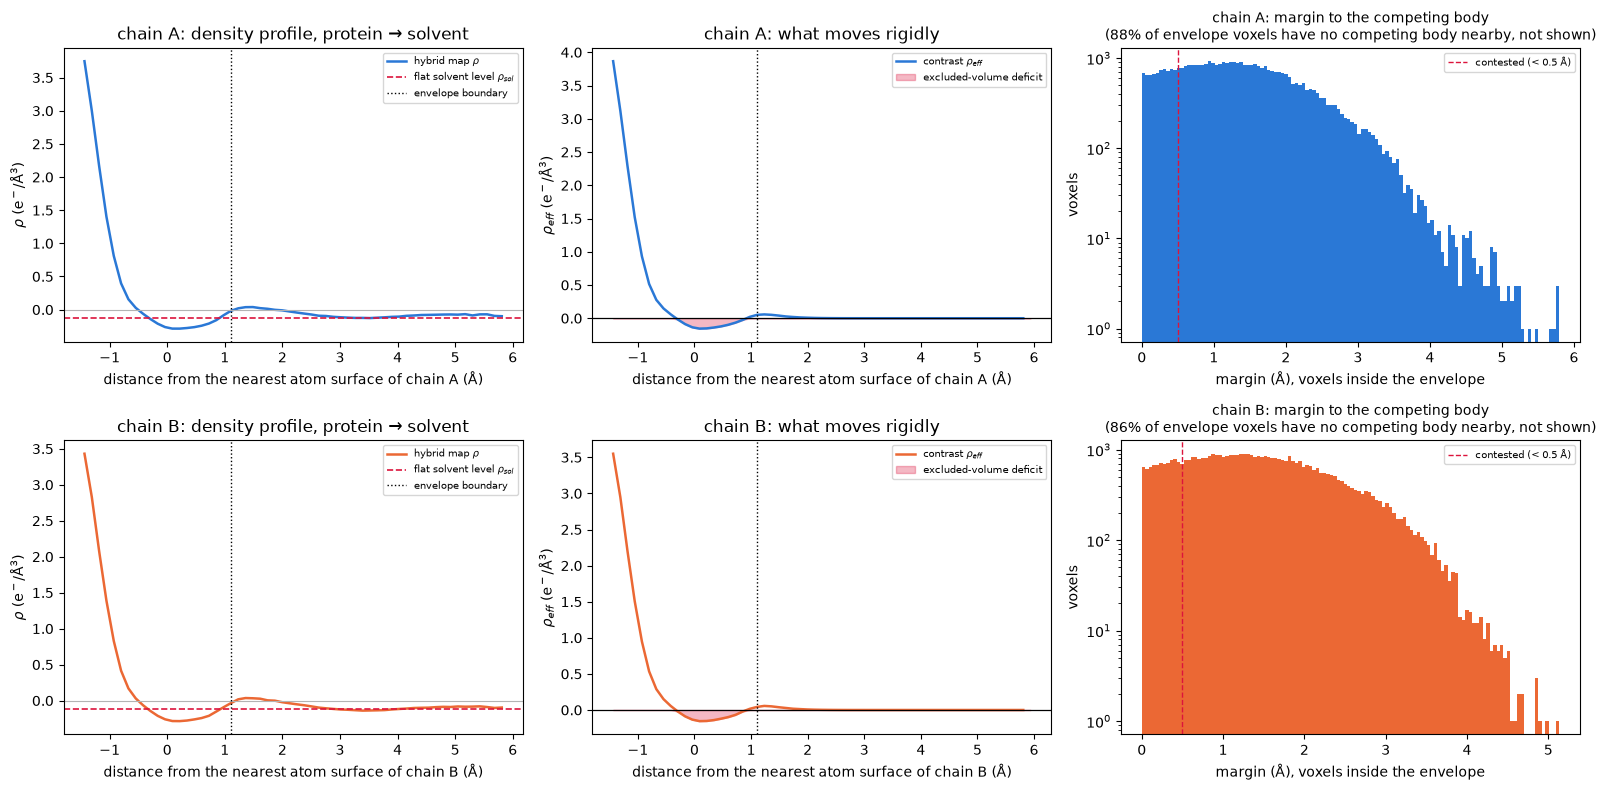

negative-contrast fraction inside the envelope: chain A 61.3%, chain B 61.1% (the excluded-volume shell)


In [7]:
# --- Flat bulk-solvent level, envelope, contrast ---------------------------------------
_deep = D_SURF > (SOLVENT_PROBE + SOLVENT_SHELL)
if _deep.sum() < 0.005*N_VOX:
    print(f"WARNING: only {_deep.sum()} deep-solvent voxels; falling back to the outermost 2%.")
    _deep = D_SURF > np.quantile(D_SURF, 0.98)
rho_flat = rho.ravel()
rho_sol_map = float(np.median(rho_flat[_deep]))
M_soft = (0.5*(1.0 - np.tanh((D_SURF - SOLVENT_PROBE)/SOLVENT_EDGE))).astype(np.float64)
V_mask = float(M_soft.sum()*dV)
rho_eff = (rho_flat - rho_sol_map)*M_soft
V_solv  = cell.volume - V_mask
rho_bar = (Z_model + rho_sol_map*V_solv)/V_mask
rho_sol_abs = rho_sol_map + rho_bar
Q_contrast = float(rho_eff.sum()*dV)
print(f"Deep-solvent voxels: {_deep.sum()} ({100*_deep.mean():.1f}% of the cell); "
      f"flat solvent level rho_sol = {rho_sol_map:+.4f} e⁻/Å³ (map offset)")
print(f"Envelope volume {V_mask:.0f} Å³ ({100*V_mask/cell.volume:.0f}% of the cell); "
      f"implied absolute solvent density {rho_sol_abs:.4f} e⁻/Å³ (water ≈ 0.335, no H in the bodies)")
print(f"Contrast electrons in the cell {Q_contrast:.0f} e⁻ (model {Z_model:.0f} e⁻; "
      f"flat-solvent identity -rho_sol V = {-rho_sol_map*cell.volume:.0f} e⁻)")

# --- per body -------------------------------------------------------------------------------
Q_body = np.bincount(OWNER_BODY, weights=rho_eff*dV, minlength=N_BODY)
print(f"\n{'body':>5s} {'chain':>6s} {'op':>3s} {'contrast e⁻':>12s}")
for b in range(N_BODY):
    print(f"{b:5d} {BODIES[b]['chain']:>6s} {BODIES[b]['op']:3d} {Q_body[b]:12.1f}")
for c in BODY_CHAINS:
    q = Q_body[[b for b in range(N_BODY) if BODIES[b]['chain'] == c]]
    assert np.ptp(q) <= 1e-3*abs(q.mean()) + 1e-6, "symmetry images carry different contrast"

print(f"\ncontested voxels (another body's surface within 0.5 Å of the owner's):")
for c in BODY_CHAINS:
    m = OWNER_BODY == ASU_BODY[c]
    w = np.abs(rho_eff[m]); hard = MARGIN[m] < 0.5
    print(f"   chain {c}: {100*hard.mean():5.2f}% of its voxels, {100*w[hard].sum()/w.sum():5.2f}% of its |contrast|")

# --- Boxes for the transform of each asymmetric-unit chain ----------------------------------
BOX = {}
_FLOOR_M = 1e-6          # envelope weight below which a voxel carries no contrast
for c in BODY_CHAINS:
    sel = np.where((OWNER_BODY == ASU_BODY[c]) & (M_soft > _FLOOR_M))[0]
    ijk = np.array(np.unravel_index(sel, (nu, nv, nw))).T
    I = ijk - _IMGS[OWNER_IMG[sel]]*N_GRID     # unwrapped: a voxel next to the image at +n sits at r - T_n
    w = rho_eff[sel]*dV
    r = (I/N_GRID) @ A_orth.T
    lever = r - CHAINS[c]['com']
    I0 = I.min(0); ext = I.max(0) - I0 + 1
    Nb = ext + (ext % 2)                                   # even box sizes
    Ic = I0 + Nb//2                                        # index of mode 0
    W4 = np.zeros((4,) + tuple(Nb), complex)
    loc = tuple((I - I0).T)
    W4[0][loc] = w
    for k in range(3):
        W4[k + 1][loc] = w*lever[:, k]
    BOX[c] = dict(W4=W4, Ic=Ic, N=Nb, I=I.astype(np.int32), w=w, lever=lever)
    cen = (r*w[:, None]).sum(0)/w.sum()
    # every unwrapped voxel must sit next to the chain itself (in cell 0), not next to an image
    _dmax = float(cKDTree(CHAINS[c]['pos']).query(r)[0].max())
    assert _dmax < SOLVENT_PROBE + 7*SOLVENT_EDGE + 2.5, \
        f"chain {c}: an unwrapped voxel lies {_dmax:.1f} Å from the chain; the unwrapping is wrong"
    print(f"chain {c}: {len(sel)} voxels on a {Nb[0]}x{Nb[1]}x{Nb[2]} box "
          f"({W4.nbytes/2**20:.0f} MB); contrast centroid {np.linalg.norm(cen - CHAINS[c]['com']):.2f} Å "
          f"from the centre of mass; extent {(ext*spacing).round(1)} Å; "
          f"farthest voxel {_dmax:.1f} Å from an atom")
del sel, ijk, I, w, r, lever; gc.collect()

# --- Profiles, one row per asymmetric-unit body (on a random subset of voxels) ---------------
# Each row uses only the voxels the partition gives to that chain, so D_SURF is the distance
# to that chain's own atom surface. The two chains share one solvent level and one envelope
# rule; differences between the rows come from the density itself.
_ps = np.random.default_rng(2).choice(N_VOX, min(N_VOX, 4_000_000), replace=False)
_edges = np.linspace(-1.5, 6.0, 60)
_cen = 0.5*(_edges[:-1] + _edges[1:])
_cols_ch = ['#2a78d6', '#eb6834', '#1baf7a', '#8e5bd0']
fig, axes = plt.subplots(N_CHAIN, 3, figsize=(16, 4.0*N_CHAIN), squeeze=False)
_neg = {}
for r_, c in enumerate(BODY_CHAINS):
    p = _ps[OWNER_BODY[_ps] == ASU_BODY[c]]
    ds = D_SURF[p]
    bi = np.clip(np.digitize(ds, _edges) - 1, 0, len(_cen) - 1)
    ok = (ds >= _edges[0]) & (ds <= _edges[-1])
    cnt = np.bincount(bi[ok], minlength=len(_cen))
    prof_raw = np.where(cnt > 20, np.bincount(bi[ok], weights=rho_flat[p][ok], minlength=len(_cen))/np.maximum(cnt, 1), np.nan)
    prof_eff = np.where(cnt > 20, np.bincount(bi[ok], weights=rho_eff[p][ok], minlength=len(_cen))/np.maximum(cnt, 1), np.nan)
    inside = M_soft[p] > 0.5
    _neg[c] = float((rho_eff[p][inside] < 0).mean())
    col = _cols_ch[r_ % len(_cols_ch)]
    ax = axes[r_]
    ax[0].plot(_cen, prof_raw, lw=1.8, color=col, label=r'hybrid map $\rho$')
    ax[0].axhline(rho_sol_map, color='crimson', ls='--', lw=1.2, label=r'flat solvent level $\rho_{sol}$')
    ax[0].axhline(0, color='0.7', lw=0.8); ax[0].axvline(SOLVENT_PROBE, color='k', ls=':', lw=1, label='envelope boundary')
    ax[0].set_ylabel(r'$\rho$ (e$^-$/Å$^3$)'); ax[0].set_title(f'chain {c}: density profile, protein → solvent')
    ax[0].legend(fontsize=7)
    ax[1].plot(_cen, prof_eff, lw=1.8, color=col, label=r'contrast $\rho_{eff}$')
    ax[1].fill_between(_cen, 0, np.where(prof_eff < 0, prof_eff, 0), color='crimson', alpha=0.3,
                       label='excluded-volume deficit')
    ax[1].axhline(0, color='k', lw=0.9); ax[1].axvline(SOLVENT_PROBE, color='k', ls=':', lw=1)
    ax[1].set_ylabel(r'$\rho_{eff}$ (e$^-$/Å$^3$)'); ax[1].set_title(f'chain {c}: what moves rigidly')
    ax[1].legend(fontsize=7)
    mg = MARGIN[p][inside]
    lone = float((mg >= 6).mean())            # no other body among the nearest atoms
    ax[2].hist(mg[mg < 6], bins=120, color=col)
    ax[2].axvline(0.5, color='crimson', ls='--', lw=1, label='contested (< 0.5 Å)')
    ax[2].set_yscale('log'); ax[2].set_ylabel('voxels')
    ax[2].set_title(f'chain {c}: margin to the competing body\n'
                    f'({100*lone:.0f}% of envelope voxels have no competing body nearby, not shown)', fontsize=10)
    ax[2].legend(fontsize=7)
    for a_ in ax[:2]:
        a_.set_xlabel(f'distance from the nearest atom surface of chain {c} (Å)')
    ax[2].set_xlabel('margin (Å), voxels inside the envelope')
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'solvent_contrast.png', dpi=150); plt.show()
print("negative-contrast fraction inside the envelope: " + ", ".join(f"chain {c} {v:.1%}" for c, v in _neg.items())
      + " (the excluded-volume shell)")

## Coupling Vector $G(\mathbf q)$ for Eight Bodies

For one body, a small rigid displacement $(\boldsymbol\Omega,\mathbf v)$ about its
centre of mass changes its transform by $\delta F=\mathbf g\cdot(\boldsymbol\Omega,\mathbf v)$
with

$$\mathbf g=\begin{pmatrix}i\,\mathbf q\times L(\mathbf q)\\-i\,\mathbf q\,F(\mathbf q)\end{pmatrix},\qquad
F=\int\rho_{\rm eff}e^{-i\mathbf q\cdot\mathbf r}d^3r,\quad
L=\int(\mathbf r-\mathbf r_{\rm cm})\rho_{\rm eff}e^{-i\mathbf q\cdot\mathbf r}d^3r,$$

exactly as in the P1 notebook, with $\mathbf r$ the absolute (unwrapped) position in
cell 0. The coupling vector of the cell is the $6N_{\rm body}$-vector
$G=(G_0,\dots,G_7)$, $G_b=\mathbf g_b^*$, and

$$I(\mathbf q)=G^\dagger D(\mathbf q)^{-1}G,$$

with $D$ the $48\times48$ dynamical matrix of the next sections.

**Symmetry.** Body $b=(s,c)$ has density
$\rho_{{\rm eff},b}(\mathbf r)=\rho_{{\rm eff},c}\bigl(R_b^{\mathsf T}(\mathbf r-\mathbf t_b)\bigr)$, so

$$F_b(\mathbf q)=e^{-i\mathbf q\cdot\mathbf t_b}F_c(R_b^{\mathsf T}\mathbf q),\qquad
L_b(\mathbf q)=e^{-i\mathbf q\cdot\mathbf t_b}R_bL_c(R_b^{\mathsf T}\mathbf q),\qquad
G_b(\mathbf q)=e^{+i\mathbf q\cdot\mathbf t_b}\,S_b\,G_c(R_b^{\mathsf T}\mathbf q),$$

with $S_b=\mathrm{diag}(R_b,R_b)$. In Miller indices $R_b^{\mathsf T}\mathbf q$ is
$\mathbf h\,W_s$ and $\mathbf q\cdot\mathbf t_b=2\pi\,\mathbf h\cdot(\mathbf w_s+\mathbf m_b)$.
Only the two asymmetric-unit chains are ever transformed: `G_at_hkl_batch` evaluates
chain $c$ once at the rotated indices of all of its images.

**Checks.**

1. The NUFFT against direct summation over the chain's voxels at fractional $hkl$.
2. At integer $hkl$, $\sum_bF_b$ (from the two chain transforms and the symmetry
   relation) against the FFT of the whole-cell contrast $(\rho-\rho_{\rm sol})M$.
   This tests the partition, the unwrapping and the symmetry bookkeeping at once.
3. $|F_{\rm contrast}|/|F_{\rm meas}|$ by resolution: near 1 at high resolution,
   below 1 at low resolution where the solvent subtraction removes amplitude.

In [8]:
def F_L_chain(c, hkl, direct=False, chunk=None):
    """F and L of asymmetric-unit chain c at fractional indices hkl (N, 3), in the chain's
    own frame. Type-2 NUFFT of the chain's box (direct summation if direct=True)."""
    hkl = np.atleast_2d(np.asarray(hkl, float))
    B = BOX[c]
    if direct or not HAVE_FINUFFT:
        out = np.zeros((4, len(hkl)), complex)
        frac = B['I']/N_GRID
        chunk = chunk or max(1, int(2e8/(16*len(frac))))
        for s0 in range(0, len(hkl), chunk):
            ph = np.exp(-2j*np.pi*(hkl[s0:s0 + chunk] @ frac.T))          # (n, n_vox)
            out[0, s0:s0 + chunk] = ph @ B['w']
            out[1:, s0:s0 + chunk] = (ph @ (B['w'][:, None]*B['lever'])).T
    else:
        x = 2*np.pi*hkl/N_GRID
        x = (x + np.pi) % (2*np.pi) - np.pi
        out = finufft.nufft3d2(*[np.ascontiguousarray(x[:, k]) for k in range(3)], B["W4"], isign=-1,
                               eps=TRANSFORM_EPS, maxbatchsize=1)
        out = out*np.exp(-2j*np.pi*(hkl @ (B['Ic']/N_GRID)))[None, :]
    return out[0], out[1:].T

def G_at_hkl_batch(h_arr, k_arr, l_arr):
    """G(q) at fractional Miller indices: (N, 6*N_BODY) complex, G_b = conj(g_b)."""
    H = np.column_stack([np.asarray(h_arr, float), np.asarray(k_arr, float), np.asarray(l_arr, float)])
    N = len(H)
    G = np.empty((N, N_DOF), complex)
    for c in BODY_CHAINS:
        bs = [b for b in range(N_BODY) if BODIES[b]['chain'] == c]
        Hc = np.vstack([H @ BODIES[b]['W'] for b in bs])               # R_b^T q, in indices
        F, L = F_L_chain(c, Hc)
        qc = Hc @ B_recip.T
        g = np.concatenate([np.cross(1j*qc, L), -1j*qc*F[:, None]], axis=1)
        for k, b in enumerate(bs):
            ph = np.exp(-2j*np.pi*(H @ BODIES[b]['tau']))                # e^{-i q.t_b}
            G[:, 6*b:6*b + 6] = np.conj(ph[:, None]*(g[k*N:(k + 1)*N] @ S_of(BODIES[b]['R']).T))
    return G

def G_at_hkl(h, k, l):
    return G_at_hkl_batch([h], [k], [l])[0]

def F_total_hkl(H):
    """Contrast transform of the whole cell, sum_b F_b, at indices H (e^{-iq.r} convention)."""
    H = np.atleast_2d(np.asarray(H, float)); out = np.zeros(len(H), complex)
    N = len(H)
    for c in BODY_CHAINS:
        bs = [b for b in range(N_BODY) if BODIES[b]['chain'] == c]
        F, _ = F_L_chain(c, np.vstack([H @ BODIES[b]['W'] for b in bs]))
        for k, b in enumerate(bs):
            out += np.exp(-2j*np.pi*(H @ BODIES[b]['tau']))*F[k*N:(k + 1)*N]
    return out

# --- 1. NUFFT vs direct summation, fractional hkl ----------------------------------------------
_hf = np.array([[1 + 3/11, -2 + 5/11, 0.5], [7.31, 2.77, -1.13], [-15.2, 9.4, 3.71], [0.5, 0.25, 0.125]])
for c in BODY_CHAINS:
    Fn, Ln = F_L_chain(c, _hf); Fd, Ld = F_L_chain(c, _hf, direct=True)
    err = max(np.abs(Fn - Fd).max()/np.abs(Fd).max(), np.abs(Ln - Ld).max()/np.abs(Ld).max())
    print(f"chain {c}: NUFFT vs direct summation at fractional hkl, max rel. error {err:.1e}")
    assert err < 1e-6, "NUFFT transform disagrees with direct summation"

# --- 2. integer hkl: sum over bodies vs the whole-cell contrast ------------------------------
_rng_v = np.random.default_rng(0)
_sel = _rng_v.choice(len(mil_u), size=min(3000, len(mil_u)), replace=False)
_Hs = mil_u[_sel]
_Fcell = np.fft.fftn(rho_eff.reshape(nu, nv, nw))[_Hs[:, 0] % nu, _Hs[:, 1] % nv, _Hs[:, 2] % nw]*dV
_Fsum = F_total_hkl(_Hs)
_err2 = np.abs(_Fsum - _Fcell).max()/np.abs(_Fcell).max()
print(f"\nsum over the {N_BODY} bodies vs. FFT of the whole-cell contrast, {len(_Hs)} reflections: "
      f"max rel. error {_err2:.1e}")
assert _err2 < 1e-6, "the bodies' transforms do not add up to the cell's contrast transform"

# --- 3. contrast vs measured amplitudes by resolution -----------------------------------------
_ratio = np.abs(_Fsum)/Fm_u[_sel]
_dres = d_u[_sel]
_e = np.quantile(_dres, np.linspace(0, 1, 7))
print(f"\n|F_contrast| / |F_meas| at integer hkl by resolution:")
for _b in range(6):
    _m = (_dres >= _e[_b]) & (_dres <= _e[_b + 1])
    print(f"   {_e[_b]:6.2f}-{_e[_b + 1]:6.2f} Å ({_m.sum():5d}):  median {np.median(_ratio[_m]):.3f}")

_Gt = G_at_hkl(1 + 5/11, -2 + 3/11, 4/13)
assert np.abs(_Gt.imag).max() > 1e-6*np.abs(_Gt).max(), "G must be complex"
print(f"\nG at a fractional hkl: {N_DOF} complex components, |G| per body "
      f"{np.linalg.norm(_Gt.reshape(N_BODY, 6), axis=1).round(0)}")
print("OK: transform checks pass.")

chain A: NUFFT vs direct summation at fractional hkl, max rel. error 1.8e-11
chain B: NUFFT vs direct summation at fractional hkl, max rel. error 1.1e-11

sum over the 8 bodies vs. FFT of the whole-cell contrast, 3000 reflections: max rel. error 1.3e-10

|F_contrast| / |F_meas| at integer hkl by resolution:
     0.84-  0.89 Å (  500):  median 0.945
     0.89-  0.97 Å (  500):  median 0.973
     0.97-  1.07 Å (  500):  median 0.996
     1.07-  1.23 Å (  500):  median 0.983
     1.23-  1.56 Å (  500):  median 0.969
     1.56- 16.42 Å (  500):  median 0.937

G at a fractional hkl: 48 complex components, |G| per body [ 671.  574.  897.  453.  403. 1267.  703. 1051.]
OK: transform checks pass.


## Rigid-Body Contacts and Their Symmetry Orbits

**Bonds.** Two bodies are in contact, exactly as in the P1 notebook, if at least
`MIN_CONTACTS` atom pairs lie within `CONTACT_CUTOFF` (hydrogens excluded, every
alternate conformation included). The search covers body $a$ in cell 0 against
every body $b$ in every cell $\mathbf n$ with $|n_i|\le$ `MAX_IMAGE`, and a second
search one shell further out confirms that nothing was missed. A bond is the
unordered pair $\{(a,\mathbf 0),(b,\mathbf n)\}$ up to a common lattice translation,
so each physical contact of the crystal is listed once per cell. A body touching its
own lattice translate, $(a,\mathbf 0)$–$(a,\mathbf n)$, is one bond, not two.

**Orbits.** An operation $g$ maps body $(s,c)$ in cell $\mathbf n$ to body
$(s',c)$ in cell $\mathbf m$, with $W_{s'}=W_gW_s$ and
$\mathbf m=W_g(\boldsymbol\tau_b+\mathbf n)+\mathbf w_g-\boldsymbol\tau_{b'}$, so it maps
bonds onto bonds. Bonds related in this way are one physical spring in different
frames. The bonds therefore fall into orbits, and each orbit gets **one** stiffness
matrix. Its representative is a bond with one end in the asymmetric unit: these are
the springs "from the asymmetric unit to other unit cells and asymmetric units", and
they hold every parameter of the model.

**Members.** Applying the four operations to the representative gives the members
of its orbit, each counted once per cell. Member $g$ joins body $g\cdot a$ to body
$g\cdot b$, has its contact point at $R_g\mathbf p+A\mathbf w_g$ (shifted by a lattice
vector so that its first body is in cell 0), and carries

$$K_g=S_g\,K\,S_g^{\mathsf T},\qquad S_g=\mathrm{diag}(R_g,R_g).$$

For P4₃ the four members of an orbit are distinct (the stabilizer is trivial), so an
orbit has $4$ members. If an operation mapped a bond onto itself, which needs a pure
rotation axis that P4₃ lacks, $K$ would be averaged over that stabilizer. The code
handles that case for other space groups.

**Checks.** Every image of a detected bond must itself be detected. The members of
an orbit must have the same number of atom pairs. For each member, the contact
point and the geometric prior built from its *own* atom pairs must equal the
transformed ones of the representative.

For each representative the code stores the midpoints of its atom pairs (weighted
by the product of occupancies), their centroid (the contact point $\mathbf p$), and
their gyration radius $\rho_g$. These define the contact frame and the geometric
prior, as in the P1 notebook.

In [9]:
BODY_POS  = [body_positions(b) for b in range(N_BODY)]
BODY_OCC  = [CHAINS[BODIES[b]['chain']]['occ'] for b in range(N_BODY)]
BODY_TREE = [cKDTree(P) for P in BODY_POS]
BODY_RAD  = [float(np.linalg.norm(P - BODIES[b]['com'], axis=1).max()) for b, P in enumerate(BODY_POS)]

def canonical(n):
    n = tuple(int(x) for x in n)
    return min(n, tuple(-x for x in n))

def bond_key(a, b, n):
    """Canonical label of the bond (a, cell 0) -- (b, cell n), up to lattice translation."""
    n = tuple(int(x) for x in n)
    if a < b:
        return (a, b, n)
    if a > b:
        return (b, a, tuple(-x for x in n))
    return (a, a, canonical(n))

def _find_bonds(max_image):
    found = {}
    for a in range(N_BODY):
        for b in range(a, N_BODY):
            for n in product(range(-max_image, max_image + 1), repeat=3):
                if a == b and (n == (0, 0, 0) or canonical(n) != n):
                    continue
                Rn = A_orth @ np.array(n, float)
                if (np.linalg.norm(BODIES[b]['com'] + Rn - BODIES[a]['com'])
                        > BODY_RAD[a] + BODY_RAD[b] + CONTACT_CUTOFF):
                    continue
                lists = BODY_TREE[a].query_ball_point(BODY_POS[b] + Rn, CONTACT_CUTOFF)
                pairs = sorted((i, j) for j, l in enumerate(lists) for i in l)
                if len(pairs) >= MIN_CONTACTS:
                    pairs = np.array(pairs)
                    found[(a, b, n)] = dict(i=pairs[:, 0], j=pairs[:, 1])
    return found

BONDS = _find_bonds(MAX_IMAGE)
_outer = {k: v for k, v in _find_bonds(MAX_IMAGE + 1).items() if max(abs(x) for x in k[2]) > MAX_IMAGE}
if _outer:
    print(f"WARNING: {len(_outer)} bond(s) beyond MAX_IMAGE = {MAX_IMAGE}: {sorted(_outer)} -- increase MAX_IMAGE")
else:
    print(f"Checked shell {MAX_IMAGE + 1}: no additional contacts, MAX_IMAGE = {MAX_IMAGE} is sufficient.")

def bond_geometry(a, b, n, i, j):
    """Atom-pair midpoints (lab frame, body a in cell 0) and occupancy weights."""
    Rn = A_orth @ np.array(n, float)
    mid = 0.5*(BODY_POS[a][i] + BODY_POS[b][j] + Rn)
    return mid, BODY_OCC[a][i]*BODY_OCC[b][j]

# --- How an operation acts on bodies and bonds -----------------------------------------
_BODY_OF = {(B['chain'], tuple(np.round(B['W']).astype(int).ravel())): k for k, B in enumerate(BODIES)}

def map_body(g, b, n):
    """Operation g applied to body b in cell n: returns (body b', cell m)."""
    W, w = SYM_OPS[g]; B = BODIES[b]
    b2 = _BODY_OF[(B['chain'], tuple(np.round(W @ B['W']).astype(int).ravel()))]
    m = W @ (B['tau'] + np.asarray(n, float)) + w - BODIES[b2]['tau']
    mr = np.round(m)
    assert np.allclose(m, mr, atol=1e-6), "symmetry operation does not map bodies onto bodies"
    return b2, mr.astype(int)

def map_bond(g, a, b, n):
    """Image of the oriented bond (a, 0) -> (b, n): (a', b', n') with a' in cell 0, and the
    cell m1 into which a was moved."""
    a2, m1 = map_body(g, a, (0, 0, 0)); b2, m2 = map_body(g, b, n)
    return a2, b2, tuple(int(x) for x in (m2 - m1)), m1

# --- Orbits (union-find over the operations) --------------------------------------------
_parent = {k: k for k in BONDS}
def _root(k):
    while _parent[k] != k:
        _parent[k] = _parent[_parent[k]]; k = _parent[k]
    return k
for key in BONDS:
    for g in range(N_OPS):
        a2, b2, n2, _ = map_bond(g, *key)
        k2 = bond_key(a2, b2, n2)
        assert k2 in BONDS, f"image {k2} of bond {key} under operation {g} was not detected"
        assert len(BONDS[k2]['i']) == len(BONDS[key]['i']), "symmetry-related bonds differ in atom pairs"
        _parent[_root(k2)] = _root(key)
_orbits = {}
for key in BONDS:
    _orbits.setdefault(_root(key), []).append(key)

def _representative(keys):
    """Oriented bond (a, b, n) with a in the asymmetric unit; prefer an asymmetric-unit
    partner, then the smallest cell offset."""
    cand = []
    for (a, b, n) in keys:
        for (x, y, m) in ((a, b, n), (b, a, tuple(-v for v in n))):
            if x < N_CHAIN:
                cand.append((x, 0 if y < N_CHAIN else 1, sum(abs(v) for v in m), y, m))
    x, _, _, y, m = min(cand)
    return x, y, m

def _pairs_oriented(a, b, n):
    """Atom pairs of the oriented bond (a, 0) -> (b, n): indices into a's and b's atoms."""
    key = bond_key(a, b, n); P = BONDS[key]
    return (P['i'], P['j']) if key == (a, b, tuple(n)) else (P['j'], P['i'])

def contact_patch_stiffness(mid, wts, p, k_per_pair):
    """n isotropic point springs at the pair midpoints, referenced at p (lab axes)."""
    d = mid - p
    K = np.zeros((6, 6))
    K[3:6, 3:6] = k_per_pair*wts.sum()*np.eye(3)
    K[0:3, 0:3] = k_per_pair*(((d**2).sum(1)*wts).sum()*np.eye(3) - (d*wts[:, None]).T @ d)
    return K

unique, MEMBERS = {}, []
for o, keys in enumerate(sorted(_orbits.values(), key=lambda ks: min(ks))):
    a, b, n = _representative(keys)
    i, j = _pairs_oriented(a, b, n)
    mid, wts = bond_geometry(a, b, n, i, j)
    p = (mid*wts[:, None]).sum(0)/wts.sum()
    Rn = A_orth @ np.array(n, float)
    info = dict(a=a, b=b, n=n, R_n=BODIES[b]['com'] + Rn - BODIES[a]['com'], midpoints=mid, wts=wts,
                contact_pt=p, n_contacts=len(i), n_weighted=float(wts.sum()),
                rho_g=float(np.sqrt(((((mid - p)**2).sum(1))*wts).sum()/wts.sum())))
    info['label'] = (f"{BODIES[a]['chain']}–{BODIES[b]['chain']}"
                     f"{'' if BODIES[b]['op'] == 0 else '[s=' + str(BODIES[b]['op']) + ']'}"
                     f"{'' if n == (0, 0, 0) else str(n)}")
    seen, stab = {}, []
    for g in range(N_OPS):
        a2, b2, n2, m1 = map_bond(g, a, b, n)
        k2 = bond_key(a2, b2, n2)
        p2 = SYM_ROT_CART[g] @ p + A_orth @ (SYM_OPS[g][1] - m1)
        if k2 == bond_key(a, b, n):
            stab.append(g)
            assert np.allclose(p2, p, atol=1e-6) or np.allclose(
                (A_inv @ (p2 - p)) - np.round(A_inv @ (p2 - p)), 0, atol=1e-6), "stabilizer moves the contact point"
        if k2 in seen:
            continue
        seen[k2] = len(MEMBERS)
        MEMBERS.append(dict(orbit=o, op=g, a=a2, b=b2, n=n2, key=k2, p=p2,
                            Rn=A_orth @ np.array(n2, float)))
    info['stabilizer'] = stab
    info['members'] = [m for m in range(len(MEMBERS)) if MEMBERS[m]['orbit'] == o]
    unique[o] = info
shell_order = sorted(unique)
N_SHELL = len(shell_order)
assert len(MEMBERS) == len(BONDS), "every detected bond must be exactly one member of one orbit"

# --- Equivariance check: each member's own atom pairs reproduce the transformed geometry --
_kchk = []
for M in MEMBERS:
    info = unique[M['orbit']]
    i, j = _pairs_oriented(M['a'], M['b'], M['n'])
    mid, wts = bond_geometry(M['a'], M['b'], M['n'], i, j)
    p_own = (mid*wts[:, None]).sum(0)/wts.sum()
    S = S_of(SYM_ROT_CART[M['op']])
    K_own = contact_patch_stiffness(mid, wts, p_own, 1.0)
    K_rot = S @ contact_patch_stiffness(info['midpoints'], info['wts'], info['contact_pt'], 1.0) @ S.T
    _kchk.append(max(np.linalg.norm(p_own - M['p']), np.abs(K_own - K_rot).max()/np.abs(K_rot).max()))
print(f"member geometry vs. transformed representative: max deviation {max(_kchk):.1e}")
assert max(_kchk) < 1e-6, "a member's own contact geometry disagrees with its symmetry image"

print(f"\n{len(BONDS)} bonds per cell in {N_SHELL} symmetry orbits "
      f"(stabilizers: {sorted(set(len(unique[o]['stabilizer']) for o in shell_order))})")
print(f"{'orbit':>5s} {'representative':>18s} {'|R| Å':>7s} {'pairs':>6s} {'occ-wtd':>8s} "
      f"{'members':>8s} {'ρ_g Å':>6s}  type")
for o in shell_order:
    u = unique[o]
    kind = ('within the asymmetric unit' if (u['b'] < N_CHAIN and u['n'] == (0, 0, 0)) else
            'lattice translate of itself' if u['b'] == u['a'] else
            'translate of the other chain' if u['b'] < N_CHAIN else
            'symmetry mate')
    print(f"{o:5d} {u['label']:>18s} {np.linalg.norm(u['R_n']):7.2f} {u['n_contacts']:6d} "
          f"{u['n_weighted']:8.1f} {len(u['members']):8d} {u['rho_g']:6.2f}  {kind}")
_deg = np.bincount(np.concatenate([[M['a'], M['b']] for M in MEMBERS]), minlength=N_BODY)
print(f"\ncontacts per body (each bond counted at both ends): {_deg.tolist()}")

Checked shell 2: no additional contacts, MAX_IMAGE = 1 is sufficient.
member geometry vs. transformed representative: max deviation 3.0e-14

28 bonds per cell in 7 symmetry orbits (stabilizers: [1])
orbit     representative   |R| Å  pairs  occ-wtd  members  ρ_g Å  type
    0      A–A(0, 0, -1)   39.82      9      5.3        4   2.39  lattice translate of itself
    1      A–B(0, 0, -1)   29.17     83     79.2        4   6.68  translate of the other chain
    2           A–A[s=3]   32.34     87     67.1        4   9.66  symmetry mate
    3 A–B[s=2](0, -1, -1)   44.80     18     14.5        4   3.50  symmetry mate
    4 A–B[s=2](0, -1, 0)   37.92     78     41.2        4   8.39  symmetry mate
    5      B–B(0, 0, -1)   39.82     26     11.2        4   3.50  lattice translate of itself
    6 B–B[s=1](-1, 0, 0)   32.59     70     51.7        4   7.42  symmetry mate

contacts per body (each bond counted at both ends): [7, 7, 7, 7, 7, 7, 7, 7]


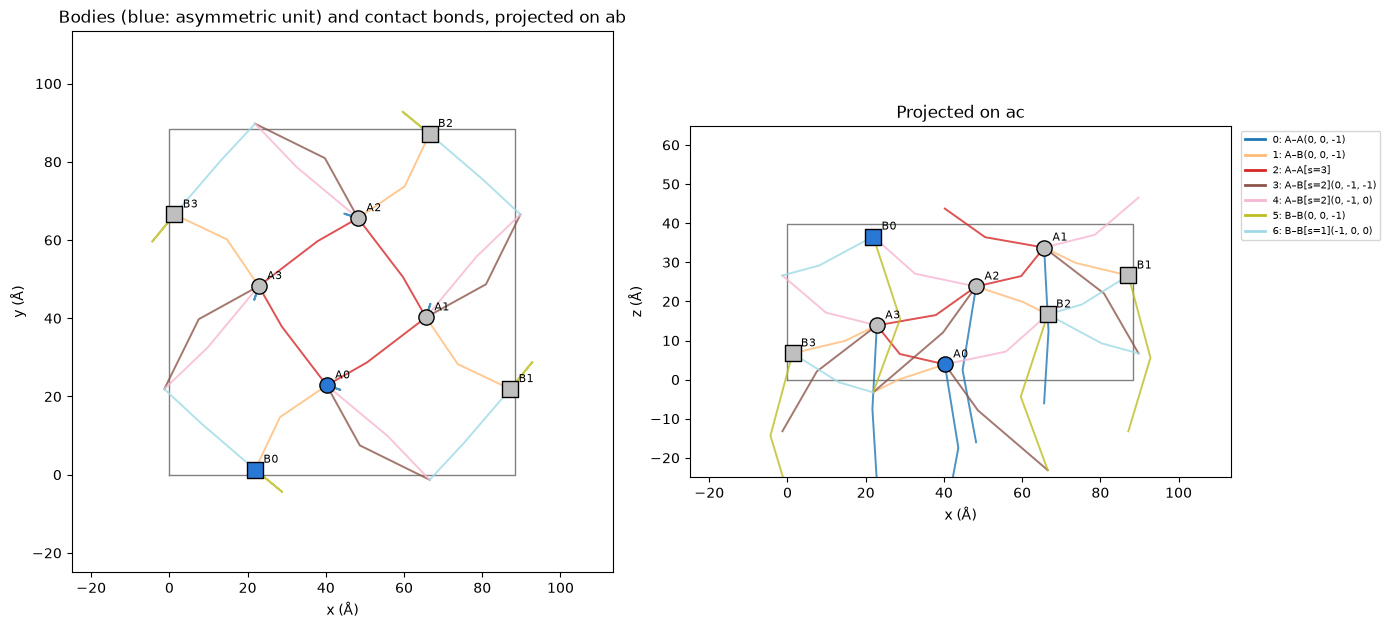

Each bond is drawn from the first body's centre of mass through the contact point to the
partner's; bonds of one colour are one orbit, i.e. one stiffness matrix seen in four frames.


In [10]:
# --- Contact network: the eight bodies and every member bond, coloured by orbit ---------
_cols = plt.cm.tab20(np.linspace(0, 1, max(N_SHELL, 2)))
fig, ax = plt.subplots(1, 2, figsize=(14, 6.5))
for k, (i0, i1, lab) in enumerate([(0, 1, ('a', 'b')), (0, 2, ('a', 'c'))]):
    corners = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]], float)
    sq = np.zeros((5, 3)); sq[:, i0] = corners[:, 0]; sq[:, i1] = corners[:, 1]
    cc = sq @ A_orth.T
    ax[k].plot(cc[:, i0], cc[:, i1], color='0.5', lw=1)
    for M in MEMBERS:
        pa = BODIES[M['a']]['com']; pb = BODIES[M['b']]['com'] + M['Rn']
        ax[k].plot([pa[i0], M['p'][i0], pb[i0]], [pa[i1], M['p'][i1], pb[i1]], '-',
                   color=_cols[M['orbit']], lw=1.4, alpha=0.8)
    for b, B in enumerate(BODIES):
        mk = 'o' if B['chain'] == BODY_CHAINS[0] else 's'
        ax[k].scatter(B['com'][i0], B['com'][i1], s=120, marker=mk,
                      color='#2a78d6' if B['op'] == 0 else '0.75', edgecolor='k', zorder=5)
        ax[k].annotate(f"{B['chain']}{B['op']}", (B['com'][i0], B['com'][i1]), textcoords='offset points',
                       xytext=(6, 5), fontsize=8)
    ax[k].set_aspect('equal'); ax[k].set_xlabel(f'{"xyz"[i0]} (Å)'); ax[k].set_ylabel(f'{"xyz"[i1]} (Å)')
    ax[k].set_xlim(-25, A_orth[i0].sum() + 25); ax[k].set_ylim(-25, A_orth[i1].sum() + 25)
ax[0].set_title('Bodies (blue: asymmetric unit) and contact bonds, projected on ab')
ax[1].set_title('Projected on ac')
ax[1].legend(handles=[Line2D([0], [0], color=_cols[o], lw=2, label=f"{o}: {unique[o]['label']}")
                      for o in shell_order], fontsize=7, loc='upper left', bbox_to_anchor=(1.01, 1.0))
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'contact_network.png', dpi=150); plt.show()
print("Each bond is drawn from the first body's centre of mass through the contact point to the")
print("partner's; bonds of one colour are one orbit, i.e. one stiffness matrix seen in four frames.")

## Reduced Units

Stiffnesses are in units of $k_BT$, with rotational entries in $k_BT/\mathrm{rad}^2$,
translational entries in $k_BT/\mathrm{Å}^2$ and cross entries in
$k_BT/(\mathrm{rad}\cdot\mathrm{Å})$. In the classical limit
$\langle u_{\mathbf q}u_{\mathbf q}^\dagger\rangle=k_BT\,D(\mathbf q)^{-1}$ does not
involve the masses, so $M$ affects only the plotted frequencies.

In [11]:
for c in BODY_CHAINS:
    print(f"chain {c}: mass {CHAINS[c]['m']:.0f} amu, inertia eigenvalues "
          f"{np.linalg.eigvalsh(CHAINS[c]['J']).round(0)} amu·Å²")
hbar_over_kT_THz = const.hbar*2*np.pi*1e12/(const.k*TEMPERATURE)
print(f"Classical-limit check: ħω/k_BT = {hbar_over_kT_THz:.4f} × (ω in THz); "
      f"{0.4*hbar_over_kT_THz:.3f} at 0.4 THz, {2*hbar_over_kT_THz:.3f} at 2 THz")

chain A: mass 16966 amu, inertia eigenvalues [1916760. 2489915. 2894603.] amu·Å²
chain B: mass 16855 amu, inertia eigenvalues [2004989. 2521536. 3022696.] amu·Å²
Classical-limit check: ħω/k_BT = 0.1600 × (ω in THz); 0.064 at 0.4 THz, 0.320 at 2 THz


## Contact Frames, the Geometric Prior, and the Stiffness Parameterization

Each orbit's stiffness is parameterized at its representative bond, exactly as one
contact of the P1 notebook: $K_{\rm local}=LL^{\mathsf T}$ (21 free entries) in a frame
with its origin at the contact point $\mathbf p$ and its $z$ axis along the
centre-of-mass separation $\mathbf R_{ab}=\mathbf r_{{\rm cm},b}+\mathbf R_{\mathbf n}-\mathbf r_{{\rm cm},a}$.
In lab axes, still at $\mathbf p$, $K=\Gamma K_{\rm local}\Gamma^{\mathsf T}$, and member
$g$ of the orbit carries $K_g=S_gKS_g^{\mathsf T}$ at its own contact point. The
parameter vector therefore has $21N_{\rm orbit}$ entries, one block per orbit, and
every $\theta$ gives a crystal with the full P4₃ symmetry.

**The prior** for each orbit is the P1 one: $n$ isotropic point springs of stiffness
$k$ at the atom-pair midpoints $\mathbf m_i$, here weighted by the product of the two
atoms' occupancies $w_i$, with $\mathbf d_i=\mathbf m_i-\mathbf p$:

$$K_{TT}=k\Bigl(\sum_iw_i\Bigr)I_3,\qquad
K_{RR}=k\sum_iw_i\bigl(|\mathbf d_i|^2I-\mathbf d_i\mathbf d_i^{\mathsf T}\bigr),\qquad K_{TR}=0$$

($K_{TR}$ vanishes because $\mathbf p$ is the weighted centroid), plus a ridge of
$10^{-3}$ of the mean diagonal. Because the members' own atom pairs are images of the
representative's, the prior has the crystal symmetry as well (checked above).

**The regularizer** is the affine-invariant geodesic distance to the prior, summed
over orbits:
$\lambda\sum_o\|\log(K_{o,\rm prior}^{-1/2}K_oK_{o,\rm prior}^{-1/2})\|_F^2$. It is
invariant under $K\to TKT^{\mathsf T}$, so it does not matter in which frame or at
which member of the orbit it is evaluated. An orbit appears once in the penalty,
even though it appears four times in $D$.

In [12]:
def skew(v):
    return np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])

def ad_translation(R):
    """Moves a rigid displacement (Omega, v) referenced at x to the reference point x + R."""
    A = np.eye(6); A[3:6, 0:3] = -skew(R); return A

def contact_frame(R_n):
    """Orthonormal frame with z along R_n."""
    ez = R_n/np.linalg.norm(R_n)
    perp = np.array([1., 0., 0.]) if abs(ez[0]) < 0.9 else np.array([0., 1., 0.])
    ex = np.cross(perp, ez); ex /= np.linalg.norm(ex)
    return np.column_stack([ex, np.cross(ez, ex), ez])

for o in shell_order:
    info = unique[o]
    info['R_frame'] = contact_frame(info['R_n'])
    info['Gamma'] = S_of(info['R_frame'])
    # stabilizer average: K_rep(lab) = mean_h S_h Gamma K_local Gamma^T S_h^T
    info['Q_rep'] = [S_of(SYM_ROT_CART[h]) @ info['Gamma'] for h in info['stabilizer']]
for M in MEMBERS:
    info = unique[M['orbit']]
    Sg = S_of(SYM_ROT_CART[M['op']])
    M['Q'] = [Sg @ Q for Q in info['Q_rep']]                 # K_m = mean_Q Q K_local Q^T
    M['Ta'] = ad_translation(M['p'] - BODIES[M['a']]['com'])
    M['Tb'] = ad_translation(M['p'] - (BODIES[M['b']]['com'] + M['Rn']))

TRIL_I, TRIL_J = np.tril_indices(6)
N_TRIL   = len(TRIL_I)
N_PARAMS = N_SHELL*N_TRIL

def theta_to_Lmap(theta):
    Lmap, idx = {}, 0
    for c in shell_order:
        L = np.zeros((6, 6)); L[TRIL_I, TRIL_J] = theta[idx:idx + N_TRIL]
        Lmap[c] = L; idx += N_TRIL
    return Lmap

def Lmap_to_theta(Lmap):
    theta, idx = np.zeros(N_PARAMS), 0
    for c in shell_order:
        theta[idx:idx + N_TRIL] = Lmap[c][TRIL_I, TRIL_J]; idx += N_TRIL
    return theta

def build_K(Lmap):
    """Cholesky factors -> (K in each orbit's local frame, {orbit: K}; K of every MEMBER
    in lab axes at its own contact point, a list in MEMBERS order -- what D(q) uses)."""
    K_local = {c: Lmap[c] @ Lmap[c].T for c in shell_order}
    K_lab = [sum(Q @ K_local[M['orbit']] @ Q.T for Q in M['Q'])/len(M['Q']) for M in MEMBERS]
    return K_local, K_lab

def prior_Lmap(k_per_pair=PRIOR_K_PER_PAIR, ridge_frac=1e-3):
    Lmap, K_prior_local = {}, {}
    for c in shell_order:
        info = unique[c]; Gm = info['Gamma']
        Kl = Gm.T @ contact_patch_stiffness(info['midpoints'], info['wts'], info['contact_pt'], k_per_pair) @ Gm
        Kl = 0.5*(Kl + Kl.T); Kl += ridge_frac*np.trace(Kl)/6*np.eye(6)
        K_prior_local[c] = Kl; Lmap[c] = np.linalg.cholesky(Kl)
    return Lmap, K_prior_local

L_PRIOR, K_PRIOR_LOCAL = prior_Lmap()
_, K_LAB_PRIOR = build_K(L_PRIOR)

# --- Regularizer: geodesic distance to the geometric prior, per orbit -------------------
def _sqrtm_inv_sym(A):
    w, V = np.linalg.eigh(0.5*(A + A.T))
    w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
    return (V*w**-0.5) @ V.T

REG_PISQRT = {c: _sqrtm_inv_sym(K_PRIOR_LOCAL[c]) for c in shell_order}

def _affine_core(K, Minv):
    P = Minv @ K @ Minv; P = 0.5*(P + P.T)
    w, U = np.linalg.eigh(P)
    w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
    return w, U, np.log(w)

# lam is looked up at CALL time (see the P1 notebook: the lambda scan rebinds LAMBDA_PRIOR)
def regularizer_prior(K_local, lam=None):
    lam = LAMBDA_PRIOR if lam is None else lam
    return lam*sum(np.sum(_affine_core(K_local[c], REG_PISQRT[c])[2]**2) for c in K_local)

def regularizer_prior_dK(K_local, lam=None):
    lam = LAMBDA_PRIOR if lam is None else lam
    out = {}
    for c in K_local:
        Minv = REG_PISQRT[c]
        w, U, lg = _affine_core(K_local[c], Minv)
        out[c] = 2*lam*(Minv @ ((U*(lg/w)) @ U.T) @ Minv)
    return out

_c0 = shell_order[0]; _Kp0 = K_PRIOR_LOCAL[_c0]
_pR = _Kp0.copy(); _pR[0:3, 0:3] *= 1.10
_pT = _Kp0.copy(); _pT[3:6, 3:6] *= 1.10
_aR, _aT = regularizer_prior({_c0: _pR}, lam=1.0), regularizer_prior({_c0: _pT}, lam=1.0)
print(f"Geodesic penalty for a 10% change of each block of orbit {_c0}: "
      f"rotational {_aR:.4e}, translational {_aT:.4e}, ratio {_aR/_aT:.3f}")
print(f"Free parameters: {N_SHELL} orbits × {N_TRIL} Cholesky entries = {N_PARAMS}  "
      f"(for {len(MEMBERS)} bonds per cell)\n")
print(f"Geometric prior at k_per_pair = {PRIOR_K_PER_PAIR} k_BT/Å²:")
for c in shell_order:
    Kl = K_PRIOR_LOCAL[c]
    kt, kr = np.trace(Kl[3:6, 3:6])/3, np.trace(Kl[0:3, 0:3])/3
    print(f"  {c:3d} {unique[c]['label']:>18s}  κ_T={kt:8.2f} k_BT/Å²   κ_R={kr:9.1f} k_BT/rad²   "
          f"ratio={kr/kt:6.1f} Å²")

Geodesic penalty for a 10% change of each block of orbit 0: rotational 2.7252e-02, translational 2.7252e-02, ratio 1.000
Free parameters: 7 orbits × 21 Cholesky entries = 147  (for 28 bonds per cell)

Geometric prior at k_per_pair = 1.0 k_BT/Å²:
    0      A–A(0, 0, -1)  κ_T=    5.32 k_BT/Å²   κ_R=     20.2 k_BT/rad²   ratio=   3.8 Å²
    1      A–B(0, 0, -1)  κ_T=   80.41 k_BT/Å²   κ_R=   2360.1 k_BT/rad²   ratio=  29.4 Å²
    2           A–A[s=3]  κ_T=   69.24 k_BT/Å²   κ_R=   4178.5 k_BT/rad²   ratio=  60.4 Å²
    3 A–B[s=2](0, -1, -1)  κ_T=   14.60 k_BT/Å²   κ_R=    118.9 k_BT/rad²   ratio=   8.1 Å²
    4 A–B[s=2](0, -1, 0)  κ_T=   42.17 k_BT/Å²   κ_R=   1935.5 k_BT/rad²   ratio=  45.9 Å²
    5      B–B(0, 0, -1)  κ_T=   11.23 k_BT/Å²   κ_R=     91.1 k_BT/rad²   ratio=   8.1 Å²
    6 B–B[s=1](-1, 0, 0)  κ_T=   52.69 k_BT/Å²   κ_R=   1899.8 k_BT/rad²   ratio=  36.1 Å²


## Dynamical Matrix

Member $m$ joins body $a$ (cell 0) to body $b$ (cell $\mathbf n$) at contact point
$\mathbf p_m$. Both bodies' displacements are referred to $\mathbf p_m$ with
$T_a=A(\mathbf p_m-\mathbf r_{{\rm cm},a})$ and
$T_b=A(\mathbf p_m-\mathbf r_{{\rm cm},b}-\mathbf R_{\mathbf n})$, where
$A(\mathbf R)=\begin{pmatrix}I&0\\-[\mathbf R]_\times&I\end{pmatrix}$. A Bloch wave
$u_{b,\mathbf n}=e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}u_b$ stretches the spring by

$$\Delta_m=T_au_a-e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}T_bu_b,$$

so member $m$ adds $T_a^{\mathsf T}K_mT_a$ to block $(a,a)$, $T_b^{\mathsf T}K_mT_b$ to
$(b,b)$, $-e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}T_a^{\mathsf T}K_mT_b$ to $(a,b)$ and its
Hermitian conjugate to $(b,a)$. With one body and $\mathbf p$ at the partner's centre
of mass this is the P1 form $M_{\mathbf n}^\dagger K_{\mathbf n}M_{\mathbf n}$. The sum runs
over all members of all orbits, i.e. over every bond of the cell once.

**Checks.**

* Exactly 3 zero modes at Γ (uniform translation of every body), Hermiticity and
  positive semidefiniteness at a generic $\mathbf q$.
* **Supercell.** On a $3\times3\times3$ periodic supercell the real-space Hessian is
  built bond by bond, and its pseudo-inverse is the exact displacement covariance of
  that finite crystal. The diffuse intensity computed from it at the commensurate
  $\mathbf q$ must equal $G^\dagger D^{-1}G$. The thirds of a reciprocal-lattice
  vector give complex phases, so this tests the phase conventions of $D$ and of $G$
  together, which a real-valued check at the zone boundary would not.

In [13]:
def dynamical_matrix_batch(q_batch, unique_unused, K_lab):
    """D(q) (N, 6 N_BODY, 6 N_BODY) complex Hermitian, summed over every member bond.
    (The second argument is kept for the P1 call signature.)"""
    q_batch = np.atleast_2d(np.asarray(q_batch, float))
    N = len(q_batch)
    C0 = np.zeros((N_DOF, N_DOF))
    D = np.zeros((N, N_DOF, N_DOF), complex)
    for M, K in zip(MEMBERS, K_lab):
        a, b, Ta, Tb = M['a'], M['b'], M['Ta'], M['Tb']
        sa, sb = slice(6*a, 6*a + 6), slice(6*b, 6*b + 6)
        C0[sa, sa] += Ta.T @ K @ Ta
        C0[sb, sb] += Tb.T @ K @ Tb
        Bab = Ta.T @ K @ Tb
        ph = np.exp(1j*(q_batch @ M['Rn']))
        D[:, sa, sb] -= ph[:, None, None]*Bab
        D[:, sb, sa] -= np.conj(ph)[:, None, None]*Bab.T
    D += 0.5*(C0 + C0.T)[None]
    return D

def dynamical_matrix(q_cart, unique_unused, K_lab):
    return dynamical_matrix_batch(np.asarray(q_cart, float)[None, :], None, K_lab)[0]

def mass_weighted_eigs(D_batch):
    """Eigenvalues of the pencil (D, M), via the Cholesky congruence (complex Hermitian)."""
    Dw = Msq_inv[None] @ D_batch @ Msq_inv.T[None]
    return np.linalg.eigvalsh(Dw)

D0  = dynamical_matrix(np.zeros(3), unique, K_LAB_PRIOR)
ev0 = mass_weighted_eigs(D0[None])[0]
print(f"D(q=0): {np.sum(np.abs(ev0) < 1e-8*abs(ev0).max())} zero eigenvalues of {N_DOF}; "
      f"smallest non-zero {np.sort(np.abs(ev0))[3]:.3e}, largest {ev0.max():.3e}")
assert np.sum(np.abs(ev0) < 1e-8*abs(ev0).max()) == 3, "expected exactly 3 zero modes at Gamma"
_qc = B_recip @ np.array([0.31, -0.17, 0.43])
_Dc = dynamical_matrix(_qc, unique, K_LAB_PRIOR)
print(f"generic q: Hermitian {np.allclose(_Dc, _Dc.conj().T)}, min eigenvalue {np.linalg.eigvalsh(_Dc).min():.3e} "
      f"(must be >= 0), ||Im D||/||Re D|| = {np.linalg.norm(_Dc.imag)/np.linalg.norm(_Dc.real):.3f}")
assert np.linalg.eigvalsh(_Dc).min() > -1e-9*np.abs(_Dc).max()

def supercell_hessian(K_lab, L=3):
    """Real-space Hessian of an L x L x L periodic supercell (cells x bodies x 6)."""
    cells = list(product(range(L), repeat=3)); idx = {c: k for k, c in enumerate(cells)}
    H = np.zeros((len(cells)*N_DOF, len(cells)*N_DOF))
    for M, K in zip(MEMBERS, K_lab):
        Ta, Tb = M['Ta'], M['Tb']
        Kaa, Kbb, Kab = Ta.T @ K @ Ta, Tb.T @ K @ Tb, Ta.T @ K @ Tb
        for c in cells:
            c2 = tuple((np.array(c) + np.array(M['n'])) % L)
            ia = idx[c]*N_DOF + 6*M['a']; ib = idx[c2]*N_DOF + 6*M['b']
            H[ia:ia + 6, ia:ia + 6] += Kaa; H[ib:ib + 6, ib:ib + 6] += Kbb
            H[ia:ia + 6, ib:ib + 6] -= Kab; H[ib:ib + 6, ia:ia + 6] -= Kab.T
    return H, cells

D(q=0): 3 zero eigenvalues of 48; smallest non-zero 3.924e-03, largest 5.417e-02
generic q: Hermitian True, min eigenvalue 7.973e+01 (must be >= 0), ||Im D||/||Re D|| = 0.193


## Phonon Band Structure

The 48 branches along Γ–X–M–Γ–Z–R–A–Z of the tetragonal zone
(X $=(\tfrac12,0,0)$, M $=(\tfrac12,\tfrac12,0)$, Z $=(0,0,\tfrac12)$,
R $=(\tfrac12,0,\tfrac12)$, A $=(\tfrac12,\tfrac12,\tfrac12)$), from the mass-weighted
dynamical matrix at the geometric prior. Three acoustic branches start at zero;
the other 45 are optic: librations, and the relative translations of the eight
bodies.

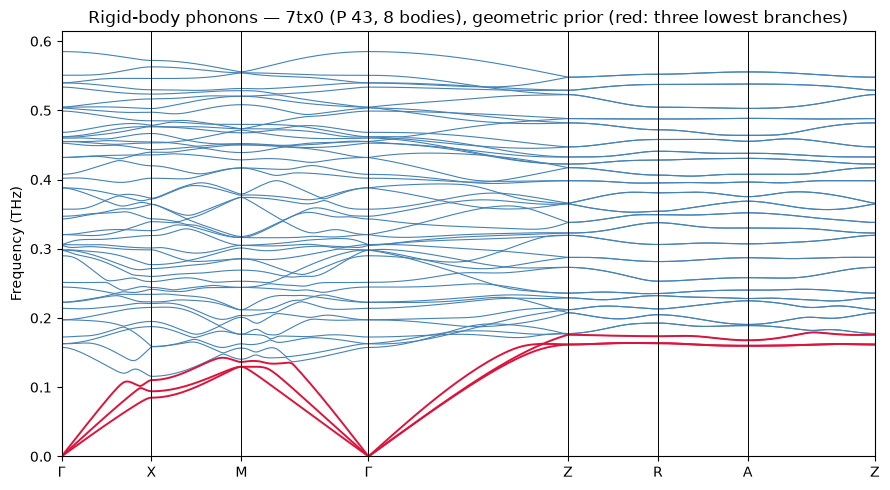

Γ: 3 acoustic zeros; lowest optic frequencies [0.1575 0.1628 0.1628 0.1725 0.1974 0.1974] THz; highest 0.585 THz


In [14]:
HSP = {'Γ': np.array([0., 0., 0.]), 'X': np.array([.5, 0., 0.]), 'M': np.array([.5, .5, 0.]),
       'Z': np.array([0., 0., .5]), 'R': np.array([.5, 0., .5]), 'A': np.array([.5, .5, .5])}
path_labels = ['Γ', 'X', 'M', 'Γ', 'Z', 'R', 'A', 'Z']
N_seg = 40
q_frac, tick_idx = [], [0]
for seg in range(len(path_labels) - 1):
    p0, p1 = HSP[path_labels[seg]], HSP[path_labels[seg + 1]]
    last = (seg == len(path_labels) - 2)
    for t in np.linspace(0, 1, N_seg, endpoint=last):
        q_frac.append(p0*(1 - t) + p1*t)
    if not last: tick_idx.append(len(q_frac))
tick_idx.append(len(q_frac) - 1)
q_frac = np.array(q_frac)
q_cart = (B_recip @ q_frac.T).T
x = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(q_cart, axis=0), axis=1))])

def bandstructure_freqs(K_lab, qs=None):
    qs = q_cart if qs is None else qs
    ev = mass_weighted_eigs(dynamical_matrix_batch(qs, unique, K_lab))
    return np.sqrt(np.maximum(ev, 0))*freq_unit

freqs_bs = bandstructure_freqs(K_LAB_PRIOR)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, freqs_bs[:, 3:], color='steelblue', lw=0.8)
ax.plot(x, freqs_bs[:, :3], color='crimson', lw=1.4)
for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0], x[-1]); ax.set_ylim(0)
ax.set_title(f'Rigid-body phonons — {PDB_ID} ({SG.hm}, {N_BODY} bodies), geometric prior '
             f'(red: three lowest branches)')
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'band_structure.png', dpi=150); plt.show()
print(f"Γ: 3 acoustic zeros; lowest optic frequencies {freqs_bs[0][3:9].round(4)} THz; "
      f"highest {freqs_bs.max():.3f} THz")

## Diffuse Scattering Maps

$I(\mathbf q)=G^\dagger D^{-1}G$ on the $(h,k)$ planes at $l=0$ and $l=0.5$, sampled
every $1/$`NPLOT_HK` in $h$ and $k$ and cut off at $|\mathbf q|<2\pi/$`D_MIN_DIFFUSE`.
$D$ is periodic in the reciprocal lattice, so at every Bragg position it has 3 zero
eigenvalues and `diffuse_intensity_batch` uses a pseudo-inverse there. Just off a
Bragg position the acoustic eigenvalues grow as $|\delta\mathbf q|^2$, giving the halos.
Their brightness follows $|\mathbf q\,F_{\rm cell}(\mathbf G)|^2$ with
$F_{\rm cell}=\sum_bF_b$, so the systematically absent $00l$ ($l\neq4n$) have no halo.

Before the maps, the cell checks:

* the eigendecomposition path against the plain linear solve used by the objective;
* **Laue symmetry**: $I(\mathbf hW_s)=I(\mathbf h)$ for every operation and
  $I(-\mathbf h)=I(\mathbf h)$, at random fractional $\mathbf h$, which tests the
  symmetry of $K$ (the members) and of $G$ together;
* the **supercell** check described above.

In [15]:
BRAGG_EIGH_RADIUS = 1e-4   # Å⁻¹: closer than this to a Bragg point, use the pseudo-inverse

def diffuse_intensity_batch(K_lab, h_arr, k_arr, l_arr, chunk=None, min_eig_frac=1e-6, G_arr=None):
    """I(q) = G^dag D(q)^+ G, vectorized, full complex G and D.

    D is singular exactly at reciprocal-lattice points, so points within
    BRAGG_EIGH_RADIUS of one use an eigendecomposition with a pseudo-inverse; every other
    point uses a plain linear solve, which is about ten times faster for a 48 x 48 D."""
    chunk = chunk or CHUNK_EVAL
    h_arr = np.asarray(h_arr, float); k_arr = np.asarray(k_arr, float); l_arr = np.asarray(l_arr, float)
    N = len(h_arr); I_out = np.zeros(N)
    for s in range(0, N, chunk):
        sl = slice(s, min(s + chunk, N))
        hb = np.column_stack([h_arr[sl], k_arr[sl], l_arr[sl]])
        qb = hb @ B_recip.T
        Db = dynamical_matrix_batch(qb, unique, K_lab)
        Gb = G_arr[sl] if G_arr is not None else G_at_hkl_batch(*hb.T)
        near = np.linalg.norm((hb - np.round(hb)) @ B_recip.T, axis=1) < BRAGG_EIGH_RADIUS
        out = np.zeros(len(hb))
        if (~near).any():
            X = np.linalg.solve(Db[~near], Gb[~near][:, :, None])[:, :, 0]
            out[~near] = np.real(np.sum(np.conj(Gb[~near])*X, axis=1))
        if near.any():
            ev, evec = np.linalg.eigh(Db[near])
            emax = np.clip(ev.max(axis=1, keepdims=True), 1e-15, None)
            pos = ev > (min_eig_frac*emax)
            ev_inv = np.where(pos, 1.0/np.where(pos, ev, 1.0), 0.0)
            proj = np.einsum('nji,nj->ni', evec.conj(), Gb[near])
            out[near] = np.einsum('ni,ni->n', np.abs(proj)**2, ev_inv)
        I_out[sl] = out
    return I_out

def forward_I(K_lab, h, k, l, G=None):
    """Single-point I(q) by a plain solve (away from Bragg points)."""
    q = B_recip @ np.array([h, k, l], float)
    G = G_at_hkl(h, k, l) if G is None else G
    return float(np.real(np.conj(G) @ np.linalg.solve(dynamical_matrix(q, unique, K_lab), G)))

_hq = np.array([1.37, -2.13, 0.61, 3.05, -1.44, 7.21])
_kq = np.array([0.22, 1.81, -2.4, 0.13, 2.77, -4.6])
_lq = np.array([0.45, -0.33, 1.12, -2.06, 0.88, 0.3])
# (G is evaluated once per batch of points here: each transform call has a fixed cost)
_Gq = G_at_hkl_batch(_hq, _kq, _lq)
_Ia = diffuse_intensity_batch(K_LAB_PRIOR, _hq, _kq, _lq, G_arr=_Gq)
_saved_r, BRAGG_EIGH_RADIUS = BRAGG_EIGH_RADIUS, np.inf          # force the eigendecomposition path
_Ie = diffuse_intensity_batch(K_LAB_PRIOR, _hq, _kq, _lq, G_arr=_Gq)
BRAGG_EIGH_RADIUS = _saved_r
_Ib = np.array([forward_I(K_LAB_PRIOR, h, k, l, G=g) for h, k, l, g in zip(_hq, _kq, _lq, _Gq)])
_rel_e = max(np.max(np.abs(_Ia - _Ib)/np.abs(_Ib)), np.max(np.abs(_Ie - _Ib)/np.abs(_Ib)))
print(f"batched solve, batched eigendecomposition and single-point solve: max rel. difference {_rel_e:.2e}")
assert _rel_e < 1e-8

# --- Laue symmetry of the predicted intensity -------------------------------------------
_hr = np.random.default_rng(4).uniform(-12, 12, (12, 3)); _hr[:, 2] /= 3
_Himg = np.vstack([sg*(_hr @ W) for W, _ in SYM_OPS for sg in (1, -1)])     # first block: _hr itself
_Iimg = diffuse_intensity_batch(K_LAB_PRIOR, *_Himg.T).reshape(2*N_OPS, len(_hr))
_I0 = _Iimg[0]
_lerr = float(np.max(np.abs(_Iimg - _I0[None])/_I0[None]))
print(f"Laue symmetry: max |I(±h W_s) - I(h)|/I over {N_OPS} operations and Friedel mates: {_lerr:.1e}")
assert _lerr < 1e-7, "the predicted diffuse intensity does not have the Laue symmetry"

# --- Supercell check ------------------------------------------------------------------------
_L = 3
_Hsc, _cells = supercell_hessian(K_LAB_PRIOR, _L)
_w, _V = np.linalg.eigh(_Hsc)
_nz = int(np.sum(_w < 1e-9*_w.max()))
_Csc = (_V*np.where(_w > 1e-9*_w.max(), 1.0/np.where(_w > 1e-9*_w.max(), _w, 1.0), 0.0)) @ _V.T
_Rc = np.array(_cells, float) @ A_orth.T
_hsc = np.array([np.array(_G0, float) + np.array(_k)/_L for _G0 in ([2, -1, 1], [5, 3, -2], [-7, 4, 0])
                 for _k in [(1, 0, 0), (1, 2, 0), (2, 1, 1), (0, 1, 2), (1, 1, 1)]])
_Gsc = G_at_hkl_batch(*_hsc.T)
_Ibl = diffuse_intensity_batch(K_LAB_PRIOR, *_hsc.T, G_arr=_Gsc)
_errs_sc = []
for _h, _Gv, _I_bl in zip(_hsc, _Gsc, _Ibl):
    _qv = B_recip @ _h
    _v = np.concatenate([np.exp(-1j*(_qv @ R))*np.conj(_Gv) for R in _Rc])
    _I_sc = np.real(_v @ _Csc @ np.conj(_v))/len(_cells)
    _errs_sc.append(abs(_I_sc - _I_bl)/_I_bl)
print(f"{_L}x{_L}x{_L} periodic supercell ({len(_cells)*N_DOF} degrees of freedom, {_nz} zero modes): "
      f"real-space covariance vs. Bloch G^†D^-1G at {len(_errs_sc)} commensurate q, max rel. error "
      f"{max(_errs_sc):.1e}")
assert _nz == 3 and max(_errs_sc) < 1e-7, "supercell and Bloch-wave intensities disagree"
del _Hsc, _V, _Csc; gc.collect()
print("OK: both intensity paths agree, the intensity has the Laue symmetry, and the Bloch")
print("formula reproduces the exact covariance of a finite periodic crystal.")

batched solve, batched eigendecomposition and single-point solve: max rel. difference 8.99e-14
Laue symmetry: max |I(±h W_s) - I(h)|/I over 4 operations and Friedel mates: 1.4e-14
3x3x3 periodic supercell (1296 degrees of freedom, 3 zero modes): real-space covariance vs. Bloch G^†D^-1G at 15 commensurate q, max rel. error 1.5e-13
OK: both intensity paths agree, the intensity has the Laue symmetry, and the Bloch
formula reproduces the exact covariance of a finite periodic crystal.


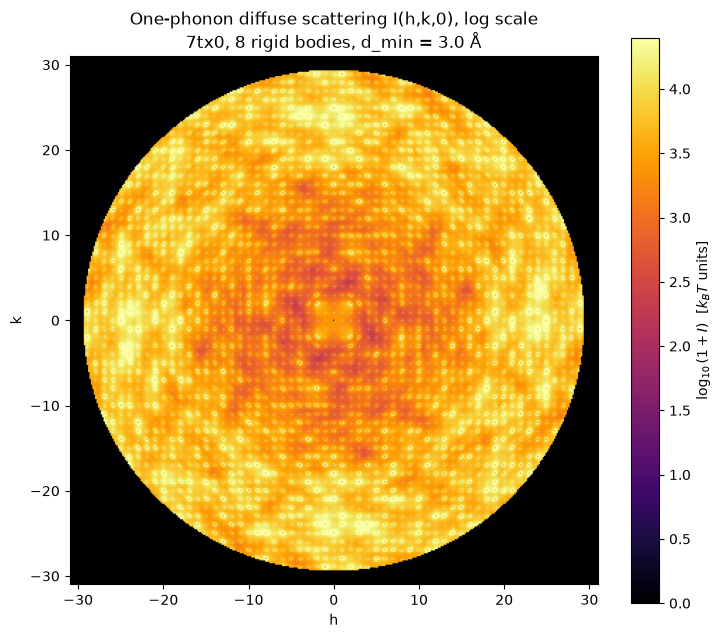

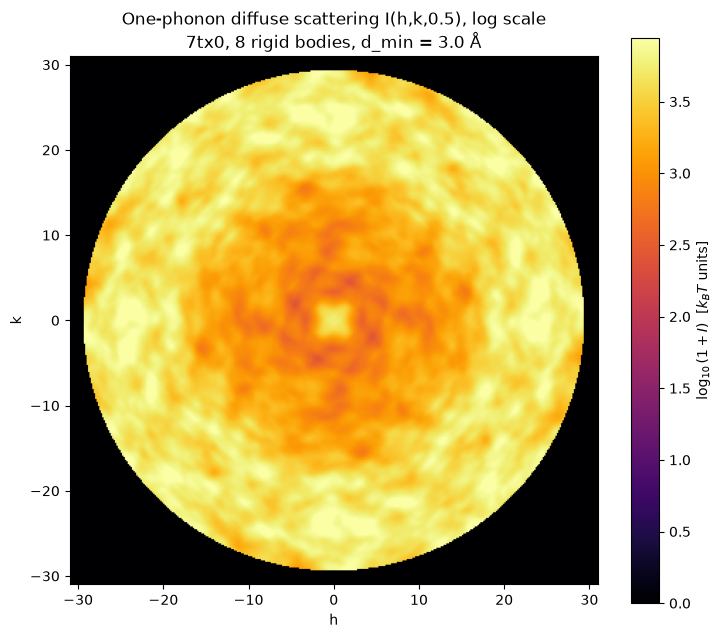

4-fold symmetry of the hk0 map: max |I(h,k) - I(-k,h)| / max I = 1.3e-14


In [16]:
P = NPLOT_HK

def compute_diffuse_map(K_lab, L_layer=0, G_all=None):
    """I(h, k, L_layer) on the 1/NPLOT_HK grid inside the resolution sphere. Returns the
    grid, the map and the G of the in-sphere points (reusable for other K)."""
    h_max = int(np.ceil(cell.a/D_MIN_DIFFUSE)) + 1
    k_max = int(np.ceil(cell.b/D_MIN_DIFFUSE)) + 1
    q_cut = 2*np.pi/D_MIN_DIFFUSE
    h_pts = np.arange(-h_max*P, h_max*P + 1)/P
    k_pts = np.arange(-k_max*P, k_max*P + 1)/P
    HH, KK = np.meshgrid(h_pts, k_pts, indexing='ij')
    hf, kf = HH.ravel(), KK.ravel(); lf = np.full_like(hf, float(L_layer))
    qn = np.linalg.norm(np.column_stack([hf, kf, lf]) @ B_recip.T, axis=1)
    keep = (qn > 1e-3) & (qn < q_cut)
    if G_all is None:
        G_all = G_at_hkl_batch(hf[keep], kf[keep], lf[keep])
    I_flat = np.zeros(len(hf))
    I_flat[keep] = diffuse_intensity_batch(K_lab, hf[keep], kf[keep], lf[keep], G_arr=G_all)
    return h_pts, k_pts, I_flat.reshape(HH.shape), h_max, k_max, G_all

def plot_diffuse(h_pts, k_pts, I_map, h_max, k_max, L_layer, fname):
    pos_vals = I_map[I_map > 0]
    vmax = np.percentile(pos_vals, 97)
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    im = ax.imshow((np.log1p(np.clip(I_map, 0, vmax))/np.log(10)).T, origin='lower', cmap='inferno',
                   extent=[h_pts[0], h_pts[-1], k_pts[0], k_pts[-1]], aspect='equal')
    plt.colorbar(im, ax=ax, label=r'$\log_{10}(1+I)$  [$k_BT$ units]')
    if float(L_layer).is_integer():
        _g = np.array([(hi, ki) for hi in range(-h_max, h_max + 1) for ki in range(-k_max, k_max + 1)])
        _g = _g[np.linalg.norm(np.column_stack([_g, np.full(len(_g), float(L_layer))]) @ B_recip.T, axis=1)
                < 2*np.pi/D_MIN_DIFFUSE]
        ax.scatter(_g[:, 0], _g[:, 1], marker='+', s=5, color='white', alpha=0.25, linewidths=0.4)
    ax.set_xlabel('h'); ax.set_ylabel('k')
    ax.set_title(f'One-phonon diffuse scattering I(h,k,{L_layer}), log scale\n'
                 f'{PDB_ID}, {N_BODY} rigid bodies, d_min = {D_MIN_DIFFUSE} Å')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

h_pts0, k_pts0, I_map0, h_max0, k_max0, G_PLANE0 = compute_diffuse_map(K_LAB_PRIOR, L_layer=0)
plot_diffuse(h_pts0, k_pts0, I_map0, h_max0, k_max0, 0, OUT_PREFIX + 'diffuse_map_hk0.png')
h_pts5, k_pts5, I_map5, h_max5, k_max5, G_PLANE5 = compute_diffuse_map(K_LAB_PRIOR, L_layer=0.5)
plot_diffuse(h_pts5, k_pts5, I_map5, h_max5, k_max5, 0.5, OUT_PREFIX + 'diffuse_map_hk05.png')
# the hk0 plane of P4_3 has 4-fold symmetry: I(h, k, 0) = I(-k, h, 0)
_c4 = np.max(np.abs(I_map0 - np.rot90(I_map0)))/I_map0.max()
print(f"4-fold symmetry of the hk0 map: max |I(h,k) - I(-k,h)| / max I = {_c4:.1e}")

## Synthetic Data

**Ground truth.** For each orbit, $L_{\rm true}=L_{\rm prior}P$ with $P$ lower-triangular,
diagonal $1+0.35\,\mathcal N(0,1)$ and sub-diagonal $0.35\,\mathcal N(0,1)$: a random
distortion of the prior, which is also the refinement's starting point. The truth
has the crystal symmetry, because it is parameterized like any other $\theta$.

**Sampling** (`sample_q_points`), sized to the number of parameters:

* **Near-Bragg.** Around random reciprocal-lattice points, points at
  $|\mathbf q-\mathbf G|=0.008$, 0.016 and 0.028 Å⁻¹ in random directions. These radii
  are smaller than for 6o2h because the cell is three times longer along $a$ and $b$
  (half a reciprocal cell is 0.035 Å⁻¹ there).
* **Mid-zone.** Points uniform in the resolution sphere, at least 0.004 Å⁻¹ from any
  reciprocal-lattice point.

Unlike the P1 notebook, points are not snapped to the map grid. On a $1/6$ grid an
offset of 0.008 Å⁻¹ would round back onto the Bragg point. Points where $D$ is
ill-conditioned at the true $K$ are removed.

**Noise.** Gaussian with $\sigma=0.02\,\mathrm{median}(I)+0.06\sqrt I$; 15% of the
points are held out.

In [17]:
def true_Lmap(seed=0, distortion=0.35):
    rng = np.random.default_rng(seed)
    Lmap = {}
    for c in shell_order:
        D_pert = np.tril(distortion*rng.standard_normal((6, 6)))
        np.fill_diagonal(D_pert, 1.0 + distortion*rng.standard_normal(6))
        Lmap[c] = L_PRIOR[c] @ D_pert
    return Lmap

L_TRUE = true_Lmap(seed=0)
K_LOCAL_TRUE, K_LAB_TRUE = build_K(L_TRUE)
assert all(np.linalg.eigvalsh(K_LOCAL_TRUE[c]).min() > 0 for c in shell_order)
print("true / prior stiffness eigenvalues per orbit (local frame):")
for c in shell_order:
    print(f"  {c:3d} true  {np.linalg.eigvalsh(K_LOCAL_TRUE[c]).round(2)}")
    print(f"      prior {np.linalg.eigvalsh(K_PRIOR_LOCAL[c]).round(2)}")

N_MID_FIT  = max(1500, 10*N_PARAMS)
N_NEAR_FIT = N_MID_FIT//5
NEAR_RADII = (0.008, 0.016, 0.028)     # Å⁻¹
_Binv_r = np.linalg.inv(B_recip)

def _bragg_distance(hkl):
    return np.linalg.norm((hkl - np.round(hkl)) @ B_recip.T, axis=1)

def sample_q_points(n_near=N_NEAR_FIT, n_mid=N_MID_FIT, seed=1):
    rng = np.random.default_rng(seed)
    q_cut = 2*np.pi/D_MIN_DIFFUSE
    hm = [int(np.ceil(L/D_MIN_DIFFUSE)) + 1 for L in (cell.a, cell.b, cell.c)]
    pts = []
    while len(pts) < n_near:                       # near-Bragg: the acoustic limit
        G = np.array([rng.integers(-m, m + 1) for m in hm], float)
        if not G.any() or np.linalg.norm(B_recip @ G) > q_cut: continue
        for r in NEAR_RADII:
            u = rng.standard_normal(3); u /= np.linalg.norm(u)
            h = _Binv_r @ (B_recip @ G + r*u)
            if np.linalg.norm(B_recip @ h) < q_cut:
                pts.append(h)
    pts = pts[:n_near]
    while len(pts) < n_near + n_mid:               # mid-zone
        h = np.array([rng.uniform(-m, m) for m in hm])
        if np.linalg.norm(B_recip @ h) < q_cut and _bragg_distance(h[None])[0] >= 0.004:
            pts.append(h)
    return np.array(pts)

def well_conditioned_batch(K_lab, hkl, min_eig_frac=1e-9):
    ev = np.concatenate([np.linalg.eigvalsh(dynamical_matrix_batch(hkl[s:s + CHUNK_EVAL] @ B_recip.T, unique, K_lab))
                         for s in range(0, len(hkl), CHUNK_EVAL)])
    emax, emin = ev[:, -1], ev[:, 0]
    return (emax > 0) & (emin/np.where(emax > 0, emax, 1.0) > min_eig_frac)

q_all_raw = sample_q_points()
keep_mask = well_conditioned_batch(K_LAB_TRUE, q_all_raw)
q_all = q_all_raw[keep_mask]
print(f"\n{len(q_all)}/{len(q_all_raw)} sampled points kept after the conditioning screen")
G_all = G_at_hkl_batch(q_all[:, 0], q_all[:, 1], q_all[:, 2])
I_true_all = diffuse_intensity_batch(K_LAB_TRUE, q_all[:, 0], q_all[:, 1], q_all[:, 2], G_arr=G_all)

rng = np.random.default_rng(7)
NOISE_FLOOR = 0.02*np.median(I_true_all)
NOISE_SCALE = 0.06
sigma_all = NOISE_FLOOR + NOISE_SCALE*np.sqrt(np.clip(I_true_all, 0, None))
I_obs_all = I_true_all + rng.normal(0, sigma_all)
train_mask = rng.random(len(q_all)) > 0.15
q_train, G_train, I_train, sigma_train = (q_all[train_mask], G_all[train_mask],
                                          I_obs_all[train_mask], sigma_all[train_mask])
q_test, G_test, I_test, sigma_test = (q_all[~train_mask], G_all[~train_mask],
                                      I_obs_all[~train_mask], sigma_all[~train_mask])
w_train = 1.0/sigma_train**2

def effective_sample_size(w):
    w = np.asarray(w, float)
    return w.sum()**2/np.sum(w**2)

print(f"{len(q_all)} q-points: {train_mask.sum()} training (effective {effective_sample_size(w_train):.0f}), "
      f"{(~train_mask).sum()} held out; {N_PARAMS} parameters")
print(f"{(I_obs_all < 0).mean():.1%} of synthetic observations are negative")

true / prior stiffness eigenvalues per orbit (local frame):
    0 true  [ 1.51  3.35 10.74 14.73 25.09 66.22]
      prior [ 5.32  5.32  5.32  9.41 20.93 30.13]
    1 true  [  11.03   54.99  140.41 1275.32 4773.2  6932.36]
      prior [  80.41   80.41   80.41 1681.95 2103.78 3294.43]
    2 true  [  14.51   35.48   77.04 3962.64 5528.98 8020.67]
      prior [  69.24   69.24   69.24 2507.84 3930.71 6096.83]
    3 true  [  1.66   9.15  17.67  28.4  132.58 663.63]
      prior [ 14.6   14.6   14.6   21.92 158.2  176.66]
    4 true  [   7.2    39.1   116.64  314.41 3542.82 3989.29]
      prior [  42.17   42.17   42.17  467.8  2498.68 2839.99]
    5 true  [  3.05   6.34  22.78  67.46  89.85 237.84]
      prior [ 11.23  11.23  11.23  46.72  92.87 133.67]
    6 true  [   9.78   64.16  114.56  544.88 1160.73 3404.14]
      prior [  52.69   52.69   52.69  962.3  2247.87 2489.31]

1800/1800 sampled points kept after the conditioning screen
1800 q-points: 1554 training (effective 1551), 246 held out

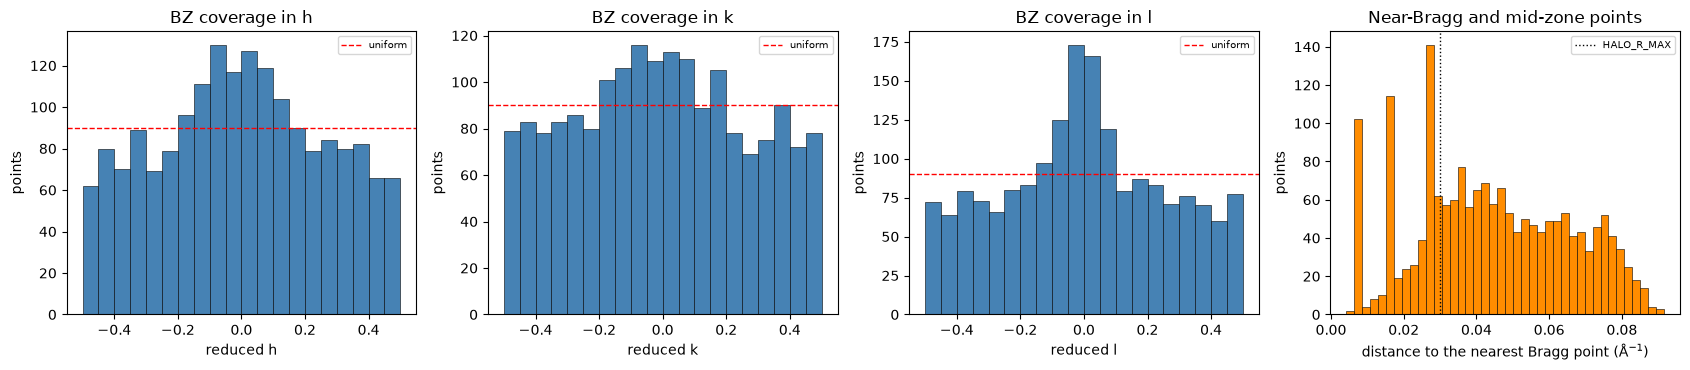

mid-zone points: uniformity χ² over 10 bins per axis (≈9 if uniform): [ 5.6 28.1 54.7]
(the near-Bragg points sit at small reduced offsets by construction, so they are left out)


In [18]:
# --- Brillouin-zone coverage of the sampling -------------------------------
_red = q_all - np.round(q_all)
_qc_all = q_all @ B_recip.T
fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
for a_, idx, lab in zip(ax[:3], range(3), ['h', 'k', 'l']):
    a_.hist(_red[:, idx], bins=np.linspace(-0.5, 0.5, 21), color='steelblue', edgecolor='k', linewidth=0.4)
    a_.axhline(len(q_all)/20, color='r', ls='--', lw=1, label='uniform')
    a_.set_xlabel(f'reduced {lab}'); a_.set_ylabel('points'); a_.set_title(f'BZ coverage in {lab}')
    a_.legend(fontsize=7)
ax[3].hist(_bragg_distance(q_all), bins=40, color='darkorange', edgecolor='k', linewidth=0.4)
ax[3].axvline(HALO_R_MAX, color='k', ls=':', lw=1, label='HALO_R_MAX')
ax[3].set_xlabel(r'distance to the nearest Bragg point (Å$^{-1}$)'); ax[3].set_ylabel('points')
ax[3].set_title('Near-Bragg and mid-zone points'); ax[3].legend(fontsize=7)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'bz_coverage.png', dpi=150); plt.show()
_midz = _bragg_distance(q_all) > HALO_R_MAX
_chi = [float(np.sum((np.histogram(_red[_midz, i], bins=10, range=(-0.5, 0.5))[0] - _midz.sum()/10)**2)/(_midz.sum()/10))
        for i in range(3)]
print(f"mid-zone points: uniformity χ² over 10 bins per axis (≈9 if uniform): {np.round(_chi, 1)}")
print("(the near-Bragg points sit at small reduced offsets by construction, so they are left out)")

## Where the Fitted q-Points Sit

Left: all sampled points in Cartesian $\mathbf q$. Right: the true diffuse maps at $l=0$
and $l=0.5$, with the sampled points within $\pm0.05$ of those layers overlaid.

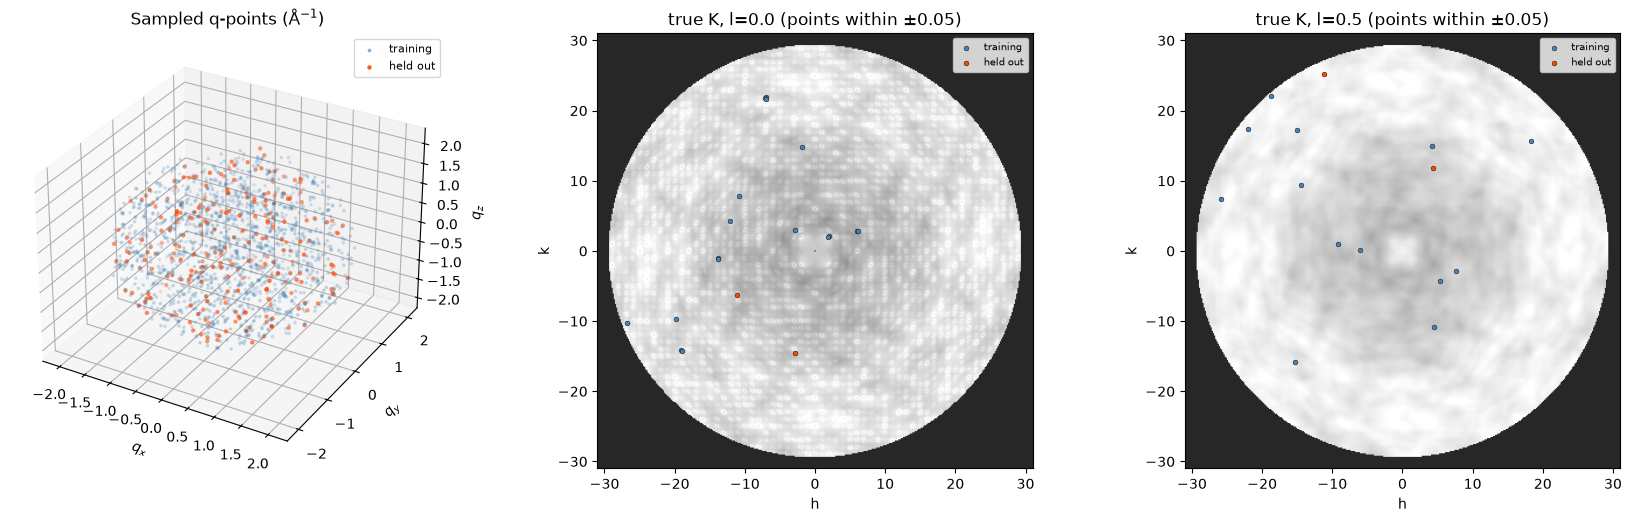

In [19]:
h_pts_bg0, k_pts_bg0, I_bg0, h_max_bg0, k_max_bg0, _ = compute_diffuse_map(K_LAB_TRUE, 0.0, G_all=G_PLANE0)
h_pts_bg05, k_pts_bg05, I_bg05, h_max_bg05, k_max_bg05, _ = compute_diffuse_map(K_LAB_TRUE, 0.5, G_all=G_PLANE5)
qc_train, qc_test = q_train @ B_recip.T, q_test @ B_recip.T
fig = plt.figure(figsize=(17, 5.2))
ax3d = fig.add_subplot(1, 3, 1, projection='3d')
ax3d.scatter(*qc_train.T, s=3, alpha=0.5, color='steelblue', label='training')
ax3d.scatter(*qc_test.T, s=5, alpha=0.8, color='orangered', label='held out')
ax3d.set_xlabel('$q_x$'); ax3d.set_ylabel('$q_y$'); ax3d.set_zlabel('$q_z$')
ax3d.set_title('Sampled q-points (Å$^{-1}$)'); ax3d.legend(fontsize=8)

def overlay_panel(ax, h_pts, k_pts, I_bg, l_layer):
    pos = I_bg[I_bg > 0]; vmax = np.percentile(pos, 97) if len(pos) else 1.0
    ax.imshow((np.log1p(np.clip(I_bg, 0, vmax))/np.log(10)).T, origin='lower', cmap='gray',
              extent=[h_pts[0], h_pts[-1], k_pts[0], k_pts[-1]], aspect='equal', alpha=0.85)
    for pts, color, label in [(q_train, 'steelblue', 'training'), (q_test, 'orangered', 'held out')]:
        sel = np.abs(pts[:, 2] - l_layer) < 0.05
        ax.scatter(pts[sel, 0], pts[sel, 1], s=12, color=color, edgecolor='k', linewidth=0.3, label=label)
    ax.set_xlabel('h'); ax.set_ylabel('k'); ax.set_title(f'true K, l={l_layer} (points within ±0.05)')
    ax.legend(fontsize=7, loc='upper right')

overlay_panel(fig.add_subplot(1, 3, 2), h_pts_bg0, k_pts_bg0, I_bg0, 0.0)
overlay_panel(fig.add_subplot(1, 3, 3), h_pts_bg05, k_pts_bg05, I_bg05, 0.5)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'sampled_q_points.png', dpi=150); plt.show()

## Refining $K$ to the Synthetic Data

$$\mathcal L(\theta)=\sum_{\mathbf q\in\rm train}w(\mathbf q)\bigl[I_{\rm obs}(\mathbf q)-I_{\rm model}(\mathbf q;\theta)\bigr]^2
+\lambda\sum_o\bigl\|\log\bigl(K_{o,\rm prior}^{-1/2}K_oK_{o,\rm prior}^{-1/2}\bigr)\bigr\|_F^2$$

with $w=1/\sigma^2$ and the sum over orbits. Distances between two stiffness sets are
the product-manifold geodesic distance $d=(\sum_od_o^2)^{1/2}$ of the P1 notebook,
now over orbits.

**Gradient.** With $x=D^{-1}G$, $dI=-x^\dagger\,dD\,x$. Member $m$ of orbit $o$
contributes $\Delta x_m^\dagger\,dK_m\,\Delta x_m$ with
$\Delta x_m=T_ax_a-e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}T_bx_b$, so
$\partial I/\partial K_m=-\mathrm{Re}(\Delta x_m\Delta x_m^\dagger)$. Because
$K_m=Q_mK_{o,\rm local}Q_m^{\mathsf T}$ with $Q_m=S_{g_m}\Gamma_o$,

$$\frac{\partial I}{\partial K_{o,\rm local}}=\sum_{m\in o}Q_m^{\mathsf T}\frac{\partial I}{\partial K_m}Q_m,$$

the sum over the four members of the orbit, and then
$\partial I/\partial L=2(\partial I/\partial K)L$. The same per-point derivatives give
the exact Jacobian, which is used both by the trust-region solver and, unlike the
finite differences of the P1 notebook, by the sloppiness and posterior analyses.

In [20]:
def _forward(theta, q_list, G_arr):
    Lmap = theta_to_Lmap(theta)
    K_local, K_lab = build_K(Lmap)
    qb = np.asarray(q_list, float) @ B_recip.T
    V = np.empty_like(G_arr)
    for s in range(0, len(qb), CHUNK_EVAL):
        sl = slice(s, s + CHUNK_EVAL)
        V[sl] = np.linalg.solve(dynamical_matrix_batch(qb[sl], unique, K_lab), G_arr[sl][:, :, None])[:, :, 0]
    I = np.real(np.sum(np.conj(G_arr)*V, axis=1))
    return Lmap, K_local, K_lab, qb, V, I

def _member_dx(V, qb, M):
    a, b = M['a'], M['b']
    ph = np.exp(1j*(qb @ M['Rn']))
    return V[:, 6*a:6*a + 6] @ M['Ta'].T - ph[:, None]*(V[:, 6*b:6*b + 6] @ M['Tb'].T)

def dI_dKlocal(V, qb, coeff=None):
    """dI/dK_local per orbit: per point (N, N_SHELL, 6, 6) if coeff is None, else summed
    with weights coeff (N_SHELL, 6, 6)."""
    S = np.zeros((N_SHELL, 6, 6)) if coeff is not None else np.zeros((len(qb), N_SHELL, 6, 6))
    for M in MEMBERS:
        W = _member_dx(V, qb, M)
        o = M['orbit']; nQ = len(M['Q'])
        if coeff is not None:
            S_lab = -np.real((W*coeff[:, None]).T @ W.conj())
            for Q in M['Q']:
                S[o] += Q.T @ S_lab @ Q/nQ
        else:
            S_lab = -np.real(W[:, :, None]*W.conj()[:, None, :])
            for Q in M['Q']:
                S[:, o] += (Q.T[None] @ S_lab @ Q[None])/nQ
    return S

def loss_and_grad(theta, q_list, G_list, I_obs, weights):
    G_arr = np.asarray(G_list)
    Lmap, K_local, K_lab, qb, V, Imodel = _forward(theta, q_list, G_arr)
    resid = Imodel - np.asarray(I_obs); weights = np.asarray(weights)
    data_loss = float(np.sum(weights*resid**2))
    S = dI_dKlocal(V, qb, coeff=2.0*weights*resid)
    dRdK = regularizer_prior_dK(K_local)
    grad_L = {}
    for ci, c in enumerate(shell_order):
        grad_L[c] = np.tril((S[ci] + S[ci].T) @ Lmap[c] + (dRdK[c] + dRdK[c].T) @ Lmap[c])
    return data_loss + regularizer_prior(K_local), Lmap_to_theta(grad_L)

def dI_dtheta(theta, q_list, G_list):
    """Exact Jacobian of the model intensities, (N, N_PARAMS), and the intensities."""
    G_arr = np.asarray(G_list)
    Lmap, _, _, qb, V, I = _forward(theta, q_list, G_arr)
    J = np.zeros((len(qb), N_PARAMS))
    for s in range(0, len(qb), CHUNK_EVAL):
        sl = slice(s, s + CHUNK_EVAL)
        S = dI_dKlocal(V[sl], qb[sl])
        for ci, c in enumerate(shell_order):
            dL = 2.0*(S[:, ci] @ Lmap[c][None])
            J[sl, ci*N_TRIL:(ci + 1)*N_TRIL] = dL[:, TRIL_I, TRIL_J]
    return J, I

_TRIU_I, _TRIU_J = np.triu_indices(6, 1)

def _reg_residuals(K_local, Lmap, lam):
    """Regularizer residuals and their Jacobian w.r.t. theta (Daleckii-Krein)."""
    r = np.zeros(N_SHELL*N_TRIL); Jr = np.zeros((N_SHELL*N_TRIL, N_PARAMS))
    s = np.sqrt(lam)
    for ci, c in enumerate(shell_order):
        Minv = REG_PISQRT[c]
        P = Minv @ K_local[c] @ Minv; P = 0.5*(P + P.T)
        w, U = np.linalg.eigh(P)
        w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
        lw = np.log(w); logP = (U*lw) @ U.T
        rows = slice(ci*N_TRIL, (ci + 1)*N_TRIL)
        r[rows] = s*np.r_[np.diag(logP), np.sqrt(2)*logP[_TRIU_I, _TRIU_J]]
        dw = w[:, None] - w[None, :]
        same = np.abs(dw) <= 1e-12*np.maximum(w[:, None], w[None, :])
        Phi = np.where(same, 1.0/w[:, None], (lw[:, None] - lw[None, :])/np.where(same, 1.0, dw))
        L = Lmap[c]
        for a in range(N_TRIL):
            E = np.zeros((6, 6)); E[TRIL_I[a], TRIL_J[a]] = 1.0
            dP = Minv @ (E @ L.T + L @ E.T) @ Minv
            dlog = U @ (Phi*(U.T @ dP @ U)) @ U.T
            Jr[rows, ci*N_TRIL + a] = s*np.r_[np.diag(dlog), np.sqrt(2)*dlog[_TRIU_I, _TRIU_J]]
    return r, Jr

def residuals_and_jac(theta, q_list, G_list, I_obs, weights, lam=None, need_jac=True):
    lam = LAMBDA_PRIOR if lam is None else lam
    sw = np.sqrt(np.asarray(weights, float))
    if need_jac:
        J, Imodel = dI_dtheta(theta, q_list, G_list)
    else:
        Imodel = _forward(theta, q_list, np.asarray(G_list))[5]
    Lmap = theta_to_Lmap(theta); K_local, _ = build_K(Lmap)
    r_reg, J_reg = _reg_residuals(K_local, Lmap, lam)
    r = np.r_[sw*(Imodel - np.asarray(I_obs)), r_reg]
    return (r, None) if not need_jac else (r, np.vstack([sw[:, None]*J, J_reg]))

def weighted_jacobian(theta, q_list, G_list, weights, scale=1.0, eps=None):
    """J = d r / d theta for the standardized residual (I - y)/sigma (exact)."""
    return scale*np.sqrt(np.asarray(weights, float))[:, None]*dI_dtheta(theta, q_list, G_list)[0]

In [21]:
# Gradient and Jacobian checks: analytic vs. central finite differences.
rng_chk = np.random.default_rng(42)
theta_chk = Lmap_to_theta(L_PRIOR)
theta_chk = theta_chk + 0.05*np.abs(theta_chk).mean()*rng_chk.standard_normal(N_PARAMS)   # also fills the zero blocks
n_chk = min(30, len(q_train))
q_chk, G_chk, I_chk, w_chk = q_train[:n_chk], G_train[:n_chk], I_train[:n_chk], w_train[:n_chk]
loss0, grad0 = loss_and_grad(theta_chk, q_chk, G_chk, I_chk, w_chk)
_gscale = float(np.abs(grad0).max())
_tscale = float(np.abs(theta_chk).mean())
# Steps are relative to the size of each parameter. Near-Bragg points have I/sigma in the
# hundreds, so the roundoff of a loss difference grows quickly as the step shrinks; the
# better of two step sizes is taken, and a real error would show up at O(1).
def _grad_err(idx, rel):
    h = rel*max(abs(theta_chk[idx]), _tscale)
    tp = theta_chk.copy(); tp[idx] += h
    tm = theta_chk.copy(); tm[idx] -= h
    fd = (loss_and_grad(tp, q_chk, G_chk, I_chk, w_chk)[0] - loss_and_grad(tm, q_chk, G_chk, I_chk, w_chk)[0])/(2*h)
    return abs(fd - grad0[idx])/max(abs(fd), 1e-3*_gscale, 1e-300)
errs = [min(_grad_err(idx, r) for r in (1e-4, 1e-5, 1e-6, 1e-7)) for idx in rng_chk.choice(N_PARAMS, size=8, replace=False)]
print(f"Gradient check, max relative error over 8 random directions: {max(errs):.2e}")
assert max(errs) < 1e-4
_Jc, _ = dI_dtheta(theta_chk, q_chk, G_chk)
def _jac_err(idx, rel):
    h = rel*max(abs(theta_chk[idx]), _tscale)
    tp = theta_chk.copy(); tp[idx] += h; tm = theta_chk.copy(); tm[idx] -= h
    fd = (_forward(tp, q_chk, G_chk)[5] - _forward(tm, q_chk, G_chk)[5])/(2*h)
    return np.abs(fd - _Jc[:, idx]).max()/max(np.abs(fd).max(), 1e-300)
_jerr = [min(_jac_err(idx, r) for r in (1e-4, 1e-5, 1e-6, 1e-7)) for idx in rng_chk.choice(N_PARAMS, size=6, replace=False)]
print(f"Jacobian check, max relative error over 6 random columns: {max(_jerr):.2e}")
assert max(_jerr) < 1e-4

Gradient check, max relative error over 8 random directions: 7.91e-07
Jacobian check, max relative error over 6 random columns: 2.76e-05


In [22]:
# --- Convergence criteria --------------------------------------------------
# Two different questions, and they need two different tests.
#
#   Is the FIT converged?  Statistically, once the loss stops improving by more
#   than about one chi-squared unit there is nothing left to learn: the noise on
#   chi-squared itself is sqrt(2*dof), so smaller changes cannot alter any
#   statement about the model. This is the stopping rule.
#
#   Is K converged?  Not the same thing. Along a flat direction the loss barely
#   moves while K travels a long way, so the projected gradient -- and the loss
#   itself -- can look settled while the stiffnesses are still in motion. The
#   geodesic step measures that directly, in the same metric the regularizer
#   and the g spectrum use (see geodesic_total): after a step of 0.01 no
#   stiffness eigenvalue of any contact has changed by more than 1%. It is
#   reported every segment and is the diagnostic that says whether the reported
#   K is a point estimate or one point in a flat region.

def geodesic_step(theta_a, theta_b):
    """Geodesic distance between two iterates on the product manifold of the
    orbits, sqrt(sum_o d_o^2) -- the distance whose square the regularizer
    penalizes. exp(d) bounds the change factor of every stiffness eigenvalue."""
    Ka, _ = build_K(theta_to_Lmap(theta_a))
    Kb, _ = build_K(theta_to_Lmap(theta_b))
    tot = 0.0
    for c in shell_order:
        Minv = _sqrtm_inv_sym(Ka[c])
        P = Minv @ Kb[c] @ Minv
        w = np.linalg.eigvalsh(0.5*(P + P.T))
        w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
        tot += float(np.sum(np.log(w)**2))
    return float(np.sqrt(tot))

BLOCK     = 500     # iterations per segment
MAX_BLOCK = 80      # segments
LOSS_TOL  = 1.0     # stop when the loss improves by less than this (chi-squared
LOSS_WIN  = 5       # units) over LOSS_WIN consecutive segments
GEO_TOL   = 1e-2    # also stop if K itself stops moving this much per segment

def refine(theta_start, args, block=BLOCK, max_block=MAX_BLOCK,
           loss_tol=LOSS_TOL, loss_win=LOSS_WIN, geo_tol=GEO_TOL, verbose=True):
    """L-BFGS-B in warm-started segments, stopping on the trailing-window loss
    improvement, with the geodesic step reported alongside as a diagnostic.

    Segments rather than one call so both quantities can be measured between
    them; ftol and gtol are zero within a segment so it always runs its full
    block. L-BFGS-B rebuilds its curvature estimate each segment, which costs a
    few percent of the iterations.
    """
    if OPTIMIZER == 'lsq':
        return refine_lsq(theta_start, args, verbose=verbose)
    theta = np.asarray(theta_start, float).copy()
    hist  = [theta.copy()]
    nit = nfev = 0
    rows, why = [], "max_block"
    if verbose:
        print(f"   {'seg':>3s} {'iters':>7s} {'data loss':>12s} {'penalty':>9s} "
              f"{'K moved':>10s}")
    for b in range(max_block):
        res = minimize(loss_and_grad, theta, args=args, jac=True, method='L-BFGS-B',
                       options={'maxiter': block, 'maxfun': 4*block,
                                'ftol': 0.0, 'gtol': 0.0},
                       callback=lambda xk: hist.append(xk.copy()))
        step = geodesic_step(theta, res.x)
        theta = res.x; nit += res.nit; nfev += res.nfev
        K_local, _ = build_K(theta_to_Lmap(theta))
        pen = regularizer_prior(K_local)
        rows.append((nit, res.fun, res.fun - pen, pen, step))
        if verbose:
            print(f"   {b+1:3d} {nit:7d} {res.fun-pen:12.6g} {pen:9.4f} {step:10.3e}")
        if step < geo_tol:
            why = "geodesic"; break
        if len(rows) > loss_win and (rows[-1-loss_win][1] - rows[-1][1]) < loss_tol:
            why = "loss"; break
    return theta, hist, nit, nfev, rows, why

# --- Trust-region least squares (default) --------------------------------------
# The objective is a sum of squares, so a Gauss-Newton-type solver with the
# analytic Jacobian converges in tens of iterations where L-BFGS-B needs
# thousands on this sloppy problem. OPTIMIZER = 'lbfgs' restores the segmented
# L-BFGS-B refinement above.
from scipy.optimize import least_squares
OPTIMIZER    = 'lsq'
LSQ_MAX_NFEV = 300      # residual evaluations per fit
LSQ_FTOL     = 1e-8     # stop when ||r||^2 changes by less than this fraction

def refine_lsq(theta_start, args, max_nfev=None, verbose=True):
    """Minimize ||r||^2 = chi^2 + lambda sum d^2 with scipy's 'trf' solver.
    Returns the same tuple as refine(): theta, history (one entry per Jacobian
    evaluation), iterations, evaluations, rows, stop reason."""
    q_list, G_list, I_obs, weights = args
    hist, cache = [], {}
    def fun(th):
        key = th.tobytes()
        if key not in cache:
            cache.clear()
            cache[key] = residuals_and_jac(th, q_list, G_list, I_obs, weights, need_jac=False)[0]
        return cache[key]
    losses = []
    def jac(th):
        hist.append(th.copy())
        r = fun(th)                      # cached: trf evaluates fun at th just before jac
        losses.append(float(r @ r))
        return residuals_and_jac(th, q_list, G_list, I_obs, weights)[1]
    res = least_squares(fun, np.asarray(theta_start, float), jac=jac, method='trf',
                        x_scale='jac', ftol=LSQ_FTOL, xtol=1e-12, gtol=1e-12,
                        max_nfev=max_nfev or LSQ_MAX_NFEV)
    theta = res.x
    hist = [np.asarray(theta_start, float).copy()] + hist[1:]   # hist[0] of the solver is theta_start
    if not np.array_equal(hist[-1], theta):
        hist.append(theta.copy())
    K_local, _ = build_K(theta_to_Lmap(theta))
    pen = regularizer_prior(K_local)
    loss = 2.0*res.cost
    step = geodesic_step(hist[-2], theta) if len(hist) > 1 else 0.0
    # One row per iteration (loss and step; the data/penalty split only for the
    # final point), so the caller's loss-window and step diagnostics work per iteration.
    nan = float('nan')
    rows = [(i, losses[i], nan, nan, geodesic_step(hist[i-1], hist[i]) if i else 0.0)
            for i in range(min(len(losses), len(hist)))]
    rows.append((res.njev, loss, loss - pen, pen, step))
    why = f"lsq: {res.message}"
    if verbose:
        print(f"   trust-region least squares: {res.njev} iterations, {res.nfev} evaluations")
        print(f"   data loss {loss - pen:.6g}   penalty {pen:.4f}   last step {step:.3e}")
    return theta, hist, res.njev, res.nfev, rows, why

In [23]:
# --- Helpers used by the selection scan and by the analysis below ----------

def fit_stats(K_lab, q_list, G_list, I_list):
    """R-factor and linear correlation coefficient.

    R alone is a poor summary once observations can be negative: the denominator
    is inflated by the magnitude of negatives, and R -> 1 is also what a model
    predicting ~0 produces. CC separates those cases, so both are reported.
    """
    Imodel = diffuse_intensity_batch(K_lab, q_list[:,0], q_list[:,1], q_list[:,2],
                                     G_arr=np.asarray(G_list))
    R  = np.sum(np.abs(Imodel - I_list))/np.sum(np.abs(I_list))
    CC = np.corrcoef(Imodel, I_list)[0,1]
    return R, CC, Imodel

def geodesic_per_contact(theta_a, theta_b):
    """Geodesic distance between two parameter vectors, per contact."""
    Ka, _ = build_K(theta_to_Lmap(theta_a))
    Kb, _ = build_K(theta_to_Lmap(theta_b))
    out = {}
    for c in shell_order:
        Minv = _sqrtm_inv_sym(Ka[c])
        P = Minv @ Kb[c] @ Minv
        w = np.linalg.eigvalsh(0.5*(P + P.T))
        w = np.maximum(w, REG_EIG_FLOOR*max(w.max(), 1e-300))
        out[c] = float(np.sqrt(np.sum(np.log(w)**2)))
    return out

def geodesic_total(theta_a, theta_b):
    """Geodesic distance on the product manifold of the orbits' stiffness
    matrices: d = sqrt(sum_o d_o^2). This is the distance induced by the metric
    M = metric_at(theta) used for the g spectrum, and lambda * d^2 (to the prior)
    is exactly the regularizer. Every per-contact distance satisfies d_n <= d."""
    return float(np.sqrt(sum(v**2 for v in geodesic_per_contact(theta_a, theta_b).values())))

THETA_PRIOR = Lmap_to_theta(L_PRIOR)
theta_true  = Lmap_to_theta(L_TRUE)
D_PRIOR_TRUTH = geodesic_per_contact(THETA_PRIOR, theta_true)
REF_PT = geodesic_total(THETA_PRIOR, theta_true)          # prior -> truth, product manifold

print("Geodesic distance from the prior to the ground truth, per orbit:")
for c in shell_order:
    print(f"   {unique[c]['label']:>20s} {D_PRIOR_TRUTH[c]:6.3f}")
print(f"   {'worst orbit':>20s} {max(D_PRIOR_TRUTH.values()):6.3f}")
print(f"   {'total':>20s} {REF_PT:6.3f}   (sqrt of the sum of squares; the distance used throughout)")
print()
print("This is the reference every truth→fit number has to be read against. A fit")
print("that does not get below it has not improved on the starting guess, however")
print("well it reproduces the intensities.")

Geodesic distance from the prior to the ground truth, per orbit:
          A–A(0, 0, -1)  2.441
          A–B(0, 0, -1)  3.364
               A–A[s=3]  2.445
    A–B[s=2](0, -1, -1)  2.959
     A–B[s=2](0, -1, 0)  2.592
          B–B(0, 0, -1)  2.766
     B–B[s=1](-1, 0, 0)  3.673
            worst orbit  3.673
                  total  7.737   (sqrt of the sum of squares; the distance used throughout)

This is the reference every truth→fit number has to be read against. A fit
that does not get below it has not improved on the starting guess, however
well it reproduces the intensities.


### Selecting `LAMBDA_PRIOR`

For each $\lambda$ in `LAMBDA_SCAN`, from largest to smallest (each fold, and
the full fit, starts from its own solution at the previous $\lambda$):

1. **Cross-validation.** `N_FOLDS`-fold cross-validation on $R$ over all sampled
   points. The folds are drawn from the full sample, so they include the points
   later reported as held out.
2. **Full fit.** A fit to the training set. This gives $\chi^2/\mathrm{dof}$
   (with dof = $N_{\rm train}-N_{\rm params}$), the distances $d$ prior→fit and
   truth→fit, the iteration count, and the final geodesic step.

Truth→fit is shown for reference but is not used in the selection. The selected
value is the largest $\lambda$ whose mean cross-validated $R$ is within one
standard error (fold-to-fold s.d.$/\sqrt{N_{\rm folds}}$) of the best.

The scan is the slowest cell, so it is cached in `synthetic_7tx0_lambda_scan_cache.npz`. The
cache key hashes the training points, weights, prior, $\lambda$ grid and
refinement and optimizer settings, each quantized to `CACHE_SIG` significant digits so that
last-bit floating-point differences between machines do not invalidate it. The
observed intensities are not part of the key, so set `FORCE_RESCAN = True` after
changing anything that alters the data but not the weights.

3-fold cross-validation over 1800 points  (prior→truth = 7.737)

  lambda  chi2/dof     R_cv       ±     CC_cv  prior→fit  truth→fit   iters  last step
     100    1.2252   0.0125  0.0010   0.99996      4.215      5.552      16   6.63e-04
      30    1.0649   0.0115  0.0009   0.99997      4.655      5.140      15   3.69e-04
      10    1.0074   0.0112  0.0008   0.99997      5.125      4.719      17   1.13e-03
       3    0.9799   0.0111  0.0007   0.99997      5.752      4.637      23   7.17e-04
       1    0.9668   0.0111  0.0007   0.99997      6.607      5.338      33   9.16e-04
     0.3    0.9585   0.0112  0.0007   0.99997      8.121      6.863     116   3.01e-03
     0.1    0.9564   0.0112  0.0007   0.99997      9.056      7.512      35   6.28e-03
    0.03    0.9555   0.0112  0.0007   0.99997     10.234      8.358      44   1.05e-02
    0.01    0.9551   0.0112  0.0007   0.99997     11.481      9.413     118   3.33e-02
scan cached to synthetic_7tx0_lambda_scan_cache.npz (key 432a1945

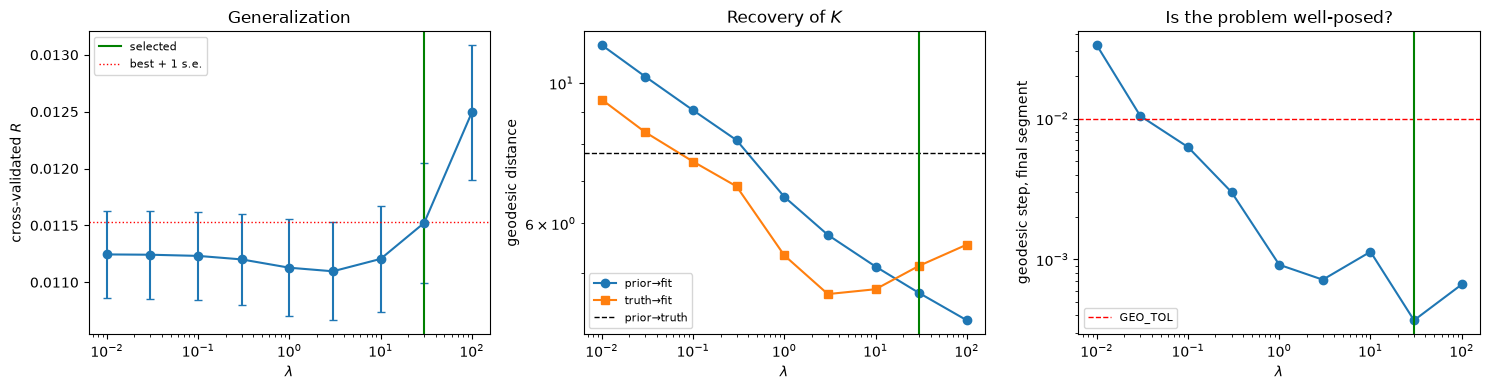

In [24]:
# --- Cross-validated selection of LAMBDA_PRIOR -----------------------------
# --- Cache -----------------------------------------------------------------
# The scan is by far the slowest cell, so its result is cached and the cache is
# designed to survive being carried between machines.
#
# The key must NOT be a hash of raw float64 bytes. Nothing here is unseeded --
# every RNG takes an explicit integer -- but bit-exact reproducibility across
# machines is a different matter: a different BLAS, numpy/scipy version, CPU
# instruction set or thread count changes summation order, and floating-point
# addition is not associative. cKDTree.query_ball_point also returns neighbours
# in unspecified order, which propagates through the contact centroids into the
# prior. Any of these perturbs the last bits and so the hash.
#
# Each component is therefore quantized to CACHE_SIG significant digits relative
# to its own magnitude before hashing -- tight enough to catch a real change,
# loose enough to ignore last-bit noise -- and the per-component digests are
# stored so a mismatch says WHICH input moved.
import hashlib, os
CV_CACHE_FILE = OUT_PREFIX + 'lambda_scan_cache.npz'
FORCE_RESCAN  = False    # True ignores the cache
CACHE_SIG     = 8        # significant digits retained in the key

def _quant(a):
    a = np.asarray(a, float)
    if a.size == 0:
        return a
    m = float(np.max(np.abs(a)))
    return np.round(a/(m if m > 0 else 1.0), CACHE_SIG)

def _digest(a):
    q = _quant(a)
    h = hashlib.sha1(np.ascontiguousarray(q).tobytes())
    h.update(repr(np.asarray(a).shape).encode())
    return h.hexdigest()[:16]

def _scan_key(**components):
    """Per-component digests plus a combined key. Arrays are quantized; anything
    else is hashed from its repr."""
    def _numeric(v):
        if not isinstance(v, (np.ndarray, list, tuple)):
            return False
        try:
            return np.asarray(v).dtype.kind in 'fiu'
        except ValueError:                 # ragged / mixed nesting: hash its repr instead
            return False
    d = {}
    for k, v in sorted(components.items()):
        d[k] = (_digest(v) if _numeric(v) else
                hashlib.sha1(repr(v).encode()).hexdigest()[:16])
    d['__all__'] = hashlib.sha1(repr(sorted(d.items())).encode()).hexdigest()[:16]
    return d

def _load_scan(key):
    if FORCE_RESCAN or not os.path.exists(CV_CACHE_FILE):
        return None
    try:
        z = np.load(CV_CACHE_FILE, allow_pickle=False)
        old = {k: str(v) for k, v in zip(z['key_names'], z['key_values'])}
    except Exception as e:
        print(f"cache unreadable ({e}) -- rescanning"); return None
    if old.get('__all__') == key['__all__']:
        return [tuple(r) for r in z['scan']]
    diff = [k for k in key if k != '__all__' and old.get(k) != key[k]]
    print("cache found but these inputs differ, so it cannot be reused:")
    for k in diff:
        print(f"   {k}: cached {old.get(k, '(absent)')}  now {key[k]}")
    if not diff:
        print("   (no component differs -- the cache was written by an older key format)")
    return None

def _save_scan(key, scan):
    np.savez(CV_CACHE_FILE,
             key_names=np.array(list(key.keys())),
             key_values=np.array(list(key.values())),
             scan=np.array(scan, float))
    print(f"scan cached to {CV_CACHE_FILE} (key {key['__all__']})")

LAMBDA_SCAN = [1e-2, 3e-2, 1e-1, 3e-1, 1.0, 3.0, 10.0, 30.0, 100.0]
N_FOLDS     = 3        # 1 reproduces a single held-out split; raise for a
                       # tighter estimate at proportionally more compute
SCAN_BLOCKS = 30       # segment cap per fit during the scan

# The scan rebinds the module-level LAMBDA_PRIOR, which only works because
# regularizer_prior looks it up at call time rather than binding it as a default
# argument. Verify that here rather than discovering it from identical rows.
_saved_lambda = LAMBDA_PRIOR
_probe = {shell_order[0]: 1.05*K_PRIOR_LOCAL[shell_order[0]]}
LAMBDA_PRIOR = 1.0;  _p1 = regularizer_prior(_probe)
LAMBDA_PRIOR = 10.0; _p2 = regularizer_prior(_probe)
LAMBDA_PRIOR = _saved_lambda
assert abs(_p2/_p1 - 10.0) < 1e-9, \
    "regularizer_prior is not picking up LAMBDA_PRIOR at call time"

_rng_cv = np.random.default_rng(11)
_perm   = _rng_cv.permutation(len(q_all))
_fold   = np.array_split(_perm, max(N_FOLDS, 1))

# Warm-started along the lambda path, walked from LARGE to SMALL. Heavily
# regularized fits sit near the prior; relaxing lambda lets the fit move outward
# in steps, so each start is close to its target.
# Each fold keeps its own warm start, and the full fit its own, so a fold's
# starting point never comes from a fit that saw that fold's held-out points.
_WARM = {}

def cv_score(lam):
    """Cross-validated R and CC, plus the fit on all data at this lambda."""
    global LAMBDA_PRIOR
    LAMBDA_PRIOR = lam
    Rs, CCs = [], []
    if N_FOLDS > 1:
        for _k, f in enumerate(_fold):
            te = np.zeros(len(q_all), bool); te[f] = True
            th, _, _, _, _, _ = refine(_WARM.get(_k, THETA_PRIOR),
                                       (q_all[~te], G_all[~te], I_obs_all[~te],
                                        1.0/sigma_all[~te]**2),
                                       max_block=SCAN_BLOCKS, verbose=False)
            _WARM[_k] = th
            _, Kl = build_K(theta_to_Lmap(th))
            R, CC, _ = fit_stats(Kl, q_all[te], G_all[te], I_obs_all[te])
            Rs.append(R); CCs.append(CC)
    th, _, nit, _, rw, _ = refine(_WARM.get('full', THETA_PRIOR), (q_train, G_train, I_train, w_train),
                                  max_block=SCAN_BLOCKS, verbose=False)
    _WARM['full'] = th
    _, Kl = build_K(theta_to_Lmap(th))
    if N_FOLDS <= 1:
        R, CC, _ = fit_stats(Kl, q_test, G_test, I_test)
        Rs, CCs = [R], [CC]
    Im   = diffuse_intensity_batch(Kl, *q_train.T, G_arr=G_train)
    chi2 = float(np.sum(w_train*(Im - I_train)**2)/max(len(q_train)-N_PARAMS, 1))
    return (np.mean(Rs), np.std(Rs), np.mean(CCs), chi2,
            geodesic_total(THETA_PRIOR, th),
            geodesic_total(theta_true, th),
            nit, rw[-1][4])

print(f"{N_FOLDS}-fold cross-validation over {len(q_all)} points  "
      f"(prior→truth = {REF_PT:.3f})\n")
print(f"{'lambda':>8s} {'chi2/dof':>9s} {'R_cv':>8s} {'±':>7s} {'CC_cv':>9s} "
      f"{'prior→fit':>10s} {'truth→fit':>10s} {'iters':>7s} {'last step':>10s}")
_KEY = _scan_key(q_points=q_train, weights=w_train, prior=THETA_PRIOR, lambdas=list(LAMBDA_SCAN),
                 settings=(N_FOLDS, SCAN_BLOCKS, BLOCK, LOSS_TOL,
                           LOSS_WIN, GEO_TOL, OPTIMIZER, LSQ_MAX_NFEV, LSQ_FTOL, 'dist=l2',
                           'orbits', N_SHELL, PDB_ID))
_scan = _load_scan(_KEY)
if _scan is not None:
    print(f'loaded cached scan for {len(_scan)} lambda values '
          f'(set FORCE_RESCAN = True to redo it)')
    for _r in _scan:
        print('   ' + '  '.join(f'{v:.4g}' for v in _r))
else:
    _scan = []
    for _lam in sorted(LAMBDA_SCAN, reverse=True):
        r = cv_score(_lam)
        _scan.append((_lam,) + r)
        print(f"{_lam:8.3g} {r[3]:9.4f} {r[0]:8.4f} {r[1]:7.4f} {r[2]:9.5f} "
              f"{r[4]:10.3f} {r[5]:10.3f} {r[6]:7d} {r[7]:10.2e}")
    _save_scan(_KEY, _scan)

LAMBDA_PRIOR = _saved_lambda
_scan.sort(key=lambda row: row[0])   # back to ascending lambda for plotting

# --- Automatic selection ---------------------------------------------------
# One-standard-error rule: among the values whose cross-validated R is within one
# fold-to-fold standard error of the best, take the LARGEST lambda. The R curve
# is shallow compared with its own noise, so picking the bare minimum would be
# fitting the fold split; the larger lambda is the more conservative model and
# also the better-posed optimization.
_Rs   = np.array([r[1] for r in _scan])
_ses  = np.array([r[2] for r in _scan])/max(np.sqrt(N_FOLDS), 1.0)
_i    = int(np.argmin(_Rs))
_thr  = _Rs[_i] + _ses[_i]
LAMBDA_PRIOR = float(max(r[0] for r in _scan if r[1] <= _thr))

print(f"\nbest R_cv = {_Rs[_i]:.4f} at lambda = {_scan[_i][0]:g}  "
      f"(standard error {_ses[_i]:.4f})")
print(f"one-standard-error rule -> LAMBDA_PRIOR = {LAMBDA_PRIOR:g}")
_sel = [r for r in _scan if r[0] == LAMBDA_PRIOR][0]
print(f"   at that value: χ²/dof {_sel[4]:.4f}, prior→fit {_sel[5]:.3f}, "
      f"truth→fit {_sel[6]:.3f}  (prior→truth {REF_PT:.3f})")
if _sel[6] >= REF_PT:
    print("\n   truth→fit is NOT below prior→truth: at this lambda the refined K is")
    print("   no closer to the truth than the starting guess, even though the")
    print("   intensities are reproduced well. The data constrains I(q), not K.")

_fig, _ax = plt.subplots(1, 3, figsize=(15, 4))
_l = [r[0] for r in _scan]
_ax[0].errorbar(_l, _Rs, yerr=_ses, fmt='o-', capsize=3)
_ax[0].axvline(LAMBDA_PRIOR, color='g', ls='-', lw=1.5, label='selected')
_ax[0].axhline(_thr, color='r', ls=':', lw=1, label='best + 1 s.e.')
_ax[0].set_xscale('log'); _ax[0].set_xlabel(r'$\lambda$')
_ax[0].set_ylabel('cross-validated $R$'); _ax[0].set_title('Generalization')
_ax[0].legend(fontsize=8)
_ax[1].loglog(_l, [r[5] for r in _scan], 'o-', label='prior→fit')
_ax[1].loglog(_l, [r[6] for r in _scan], 's-', label='truth→fit')
_ax[1].axhline(REF_PT, color='k', ls='--', lw=1, label='prior→truth')
_ax[1].axvline(LAMBDA_PRIOR, color='g', ls='-', lw=1.5)
_ax[1].set_xlabel(r'$\lambda$'); _ax[1].set_ylabel('geodesic distance')
_ax[1].set_title('Recovery of $K$'); _ax[1].legend(fontsize=8)
_ax[2].loglog(_l, [max(r[8], 1e-12) for r in _scan], 'o-')
_ax[2].axhline(GEO_TOL, color='r', ls='--', lw=1, label='GEO_TOL')
_ax[2].axvline(LAMBDA_PRIOR, color='g', ls='-', lw=1.5)
_ax[2].set_xlabel(r'$\lambda$'); _ax[2].set_ylabel('geodesic step, final segment')
_ax[2].set_title('Is the problem well-posed?'); _ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'lambda_scan.png', dpi=150); plt.show()

### Where the Fit Went

For each $\lambda$ the scan gives three distances $d$ on the parameter
space: prior→truth (fixed), prior→fit, and truth→fit. They satisfy the triangle
inequality, so they define a triangle. The plot places the prior at the origin,
the truth on the positive axis, and the fit at the vertex consistent with its
two distances.

The dashed circle centred on the truth passes through the prior. A fit inside it
is closer to the truth than the prior is. The picture is an exact rendering of
the three distances only. The space has non-positive curvature, so the true
geodesic triangle is thinner than this flat one: the drawn triangle is its
Euclidean comparison triangle. The 'off-axis' column is the component of the fit's
displacement perpendicular to the prior–truth line, into which all other
directions are collapsed.

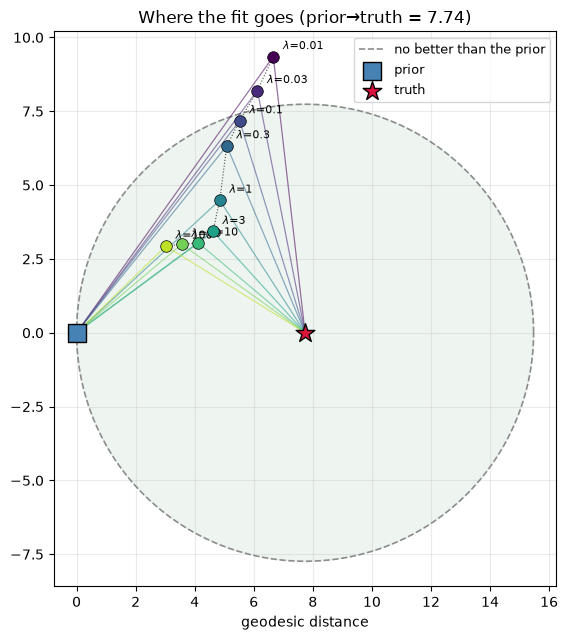

  lambda  prior→fit  truth→fit  improved?  off-axis
    0.01     11.481      9.413         NO     9.351
    0.03     10.234      8.358         NO     8.200
     0.1      9.056      7.512        yes     7.178
     0.3      8.121      6.863        yes     6.331
       1      6.607      5.338        yes     4.489
       3      5.752      4.637        yes     3.430
      10      5.125      4.719        yes     3.039
      30      4.655      5.140        yes     2.997
     100      4.215      5.552        yes     2.935

'off-axis' is the component of the fit's displacement perpendicular to the
prior→truth direction: motion that is neither toward nor away from the
truth, purely along directions the data does not constrain.


In [25]:
# --- The prior / truth / fit triangle, as a function of lambda -------------
def _triangle_vertex(d_pt, d_pf, d_tf):
    """Place the fit given its distances to prior (origin) and truth (d_pt, 0)."""
    if d_pt < 1e-12: return np.nan, np.nan
    x = (d_pf**2 - d_tf**2 + d_pt**2)/(2*d_pt)
    y2 = d_pf**2 - x**2
    return x, np.sqrt(max(y2, 0.0))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
_th = np.linspace(0, 2*np.pi, 400)
ax.plot(REF_PT + REF_PT*np.cos(_th), REF_PT*np.sin(_th), color='0.55', ls='--',
        lw=1.2, label='no better than the prior')
ax.fill(REF_PT + REF_PT*np.cos(_th), REF_PT*np.sin(_th), color='seagreen', alpha=0.08)

_cols = plt.cm.viridis(np.linspace(0, 0.9, len(_scan)))
_pts = []
for (row, col) in zip(_scan, _cols):
    lam, d_pf, d_tf = row[0], row[5], row[6]
    xf, yf = _triangle_vertex(REF_PT, d_pf, d_tf)
    _pts.append((xf, yf))
    ax.plot([0, xf, REF_PT], [0, yf, 0], color=col, lw=0.9, alpha=0.55)
    ax.scatter([xf], [yf], s=70, color=col, zorder=5, edgecolor='k', linewidth=0.5)
    ax.annotate(f'$\\lambda$={lam:g}', (xf, yf), textcoords='offset points',
                xytext=(7, 5), fontsize=8)
_pts = np.array(_pts)
ax.plot(_pts[:,0], _pts[:,1], color='0.3', lw=0.8, ls=':', zorder=4)

ax.scatter([0], [0], s=160, marker='s', color='steelblue', zorder=6,
           edgecolor='k', label='prior')
ax.scatter([REF_PT], [0], s=200, marker='*', color='crimson', zorder=6,
           edgecolor='k', label='truth')
ax.set_aspect('equal'); ax.set_xlabel('geodesic distance'); ax.set_ylabel('')
ax.set_title(f'Where the fit goes (prior→truth = {REF_PT:.2f})')
ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=0.25)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'fit_triangles.png', dpi=150); plt.show()

print(f"{'lambda':>8s} {'prior→fit':>10s} {'truth→fit':>10s} {'improved?':>10s} "
      f"{'off-axis':>9s}")
for row, (xf, yf) in zip(_scan, _pts):
    print(f"{row[0]:8.3g} {row[5]:10.3f} {row[6]:10.3f} "
          f"{'yes' if row[6] < REF_PT else 'NO':>10s} {yf:9.3f}")
print("\n'off-axis' is the component of the fit's displacement perpendicular to the")
print("prior→truth direction: motion that is neither toward nor away from the")
print("truth, purely along directions the data does not constrain.")

### Refinement at the Selected $\lambda$

Everything below uses the `LAMBDA_PRIOR` chosen above: the fitted stiffnesses,
the distance diagnostics, the Gauss-Newton spectrum, the predicted ADPs, and the
mode animations.

In [26]:
if OPTIMIZER == 'lsq':
    print(f"Refining with trust-region least squares (stop when ||r||^2 changes by < {LSQ_FTOL:g} "
          f"of itself, at most {LSQ_MAX_NFEV} evaluations)")
else:
    print(f"Refining (segments of {BLOCK} iterations)")
    print(f"  stop when the loss improves by < {LOSS_TOL} over {LOSS_WIN} segments, "
          f"or K moves < {GEO_TOL:g} in one")
theta_fit, theta_history, NIT, NFEV, _rows, _why = refine(
    Lmap_to_theta(L_PRIOR), (q_train, G_train, I_train, w_train))
theta0 = theta_history[0]
_, K_LAB_FIT = build_K(theta_to_Lmap(theta_fit))

_step = _rows[-1][4]
_dl   = (_rows[-1-LOSS_WIN][1] - _rows[-1][1]) if len(_rows) > LOSS_WIN else float('nan')
_unit = 'iterations' if OPTIMIZER == 'lsq' else 'segments'
print(f"\nStopped after {NIT} iterations ({NFEV} evaluations) on: {_why}")
print(f"  loss improvement over the last {LOSS_WIN} {_unit}: {_dl:.4f} χ² units "
      f"({_dl/max(_rows[-1][1], 1e-300):.2e} of the loss)")
print(f"  K moved {_step:.3e} in the final segment "
      f"(no stiffness eigenvalue changed by more than a factor {np.exp(_step):.3f})")

chi2_dof = float(np.sum(w_train*(diffuse_intensity_batch(K_LAB_FIT, *q_train.T, G_arr=G_train) - I_train)**2)
                 / max(len(q_train) - N_PARAMS, 1))
print(f"  weighted χ²/dof (training) = {chi2_dof:.4f}")

if _why == "loss" and _step > 10*GEO_TOL:
    print("\nThe FIT is statistically converged but K is NOT: it was still moving")
    print(f"{_step:.2f} per {BLOCK} iterations when the loss stopped improving. The")
    print("reported K is therefore one point in a nearly flat region, not a point")
    print("estimate. That region is what the prior and the sloppiness spectrum")
    print("describe; a larger LAMBDA_PRIOR shrinks it (see the scan below).")
elif _why == "max_block":
    print("\nHit MAX_BLOCK without meeting either criterion -- raise it, or raise")
    print("LAMBDA_PRIOR if the geodesic step is not decaying.")

Refining with trust-region least squares (stop when ||r||^2 changes by < 1e-08 of itself, at most 300 evaluations)
   trust-region least squares: 17 iterations, 20 evaluations
   data loss 1498.29   penalty 650.0130   last step 8.174e-04

Stopped after 17 iterations (20 evaluations) on: lsq: `ftol` termination condition is satisfied.
  loss improvement over the last 5 iterations: 0.3649 χ² units (1.70e-04 of the loss)
  K moved 8.174e-04 in the final segment (no stiffness eigenvalue changed by more than a factor 1.001)
  weighted χ²/dof (training) = 1.0649


training set:  R = 0.0101   CC = 1.0000
held out:      R = 0.0126   CC = 0.9999


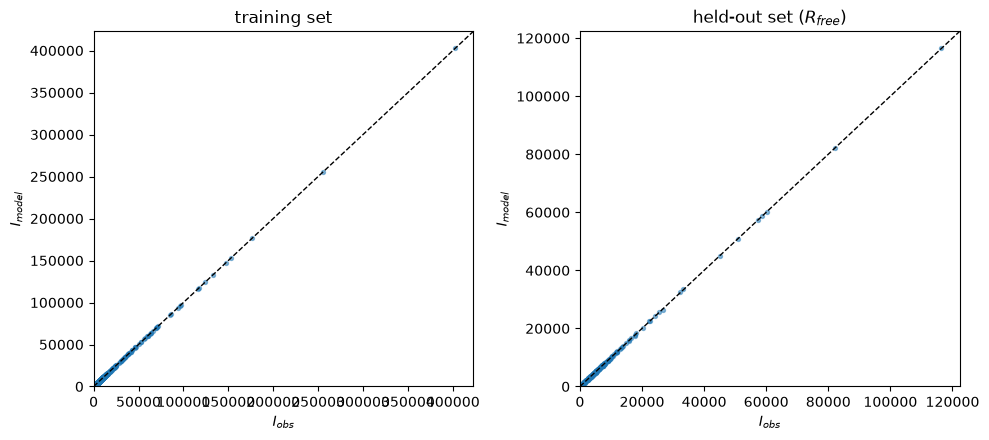

In [27]:
# R and CC on training and held-out data, at the selected lambda.
R_train, CC_train, I_model_train = fit_stats(K_LAB_FIT, q_train, G_train, I_train)
R_free,  CC_free,  I_model_test  = fit_stats(K_LAB_FIT, q_test,  G_test,  I_test)
print(f"training set:  R = {R_train:.4f}   CC = {CC_train:.4f}")
print(f"held out:      R = {R_free:.4f}   CC = {CC_free:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10,4.5))
for ax, Im, Io, title in [(axes[0], I_model_train, I_train, 'training set'),
                          (axes[1], I_model_test,  I_test,  'held-out set ($R_{free}$)')]:
    ax.scatter(Io, Im, s=8, alpha=0.5)
    lim = [min(0, Io.min()*1.05), max(Io.max(), Im.max())*1.05]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('$I_{obs}$'); ax.set_ylabel('$I_{model}$'); ax.set_title(title)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'refinement_fit_quality.png', dpi=150); plt.show()

### Distance Travelled, per Orbit

Three geodesic distances $d_o$ for each orbit: prior→truth,
prior→fit and truth→fit. A fit that recovered the truth would have truth→fit much
smaller than prior→truth. Two summary rows follow: the worst orbit
($\max_{\mathbf n}d_{\mathbf n}$) and the total $d=(\sum_{\mathbf n}d_{\mathbf n}^2)^{1/2}$,
which is the distance used everywhere else.

In [28]:
# --- How far did the fit travel, and did it land on the truth? -------------
# The decisive synthetic-test number, in the metric that respects the units of K.
# Three distances per contact: how far the truth sits from the prior, how far the
# fit went, and how close the fit landed to the truth. A fit that travels much
# further from the prior than the truth does is wandering along directions the
# data does not constrain -- the regularizer is too weak.

_d_pt = D_PRIOR_TRUTH                                # prior  -> truth
_d_pf = geodesic_per_contact(THETA_PRIOR, theta_fit) # prior  -> fit
_d_tf = geodesic_per_contact(theta_true, theta_fit)  # truth  -> fit

print(f"{'orbit':>20s} {'prior→truth':>12s} {'prior→fit':>11s} {'truth→fit':>11s}")
for c in shell_order:
    print(f"{unique[c]['label']:>20s} {_d_pt[c]:12.3f} {_d_pf[c]:11.3f} {_d_tf[c]:11.3f}")
_tot = lambda d: float(np.sqrt(sum(v**2 for v in d.values())))
print(f"{'worst orbit':>20s} {max(_d_pt.values()):12.3f} {max(_d_pf.values()):11.3f} "
      f"{max(_d_tf.values()):11.3f}")
print(f"{'total':>20s} {_tot(_d_pt):12.3f} {_tot(_d_pf):11.3f} {_tot(_d_tf):11.3f}"
      f"   (sqrt of the sum of squares)")
print()
print("A fit that recovered the truth would show truth→fit « prior→truth.")
print("prior→fit substantially larger than prior→truth means the fit has been")
print("pulled past the truth along poorly-constrained directions.")

               orbit  prior→truth   prior→fit   truth→fit
       A–A(0, 0, -1)        2.441       1.468       1.838
       A–B(0, 0, -1)        3.364       2.186       1.696
            A–A[s=3]        2.445       2.340       0.372
 A–B[s=2](0, -1, -1)        2.959       1.215       2.313
  A–B[s=2](0, -1, 0)        2.592       1.595       1.809
       B–B(0, 0, -1)        2.766       1.256       2.458
  B–B[s=1](-1, 0, 0)        3.673       1.913       2.315
         worst orbit        3.673       2.340       2.458
               total        7.737       4.655       5.140   (sqrt of the sum of squares)

A fit that recovered the truth would show truth→fit « prior→truth.
prior→fit substantially larger than prior→truth means the fit has been
pulled past the truth along poorly-constrained directions.


## How Many Parameters Does the Data Determine?

### The Jacobian

With $\chi^2=\sum_i w_i\,(I_i(\theta)-y_i)^2$ and $w_i=1/\sigma_i^2$, the
standardized residual is $r_i=(I_i-y_i)/\sigma_i$ and its Jacobian is

$$J_{i\alpha}=\frac{\partial r_i}{\partial\theta_\alpha}
=\sqrt{w_i}\,\frac{\partial I_i}{\partial\theta_\alpha}.$$

$J^{\mathsf T}J=\tfrac12\partial^2\chi^2/\partial\theta^2$ (Gauss-Newton) is the
Fisher information of the Gaussian likelihood. A displacement $\delta\theta$
costs $\Delta\chi^2\approx\delta\theta^{\mathsf T}(J^{\mathsf T}J)\,\delta\theta$.
$J$ depends on the model, the sampled $\mathbf q$ and the error bars, but not on
the observed values. `weighted_jacobian` computes it exactly (previous section).

### An invariant spectrum

The eigenvalues of $J^{\mathsf T}J$ change under a reparameterization
$\theta=A\phi$ ($J^{\mathsf T}J\to A^{\mathsf T}J^{\mathsf T}JA$). Here the
parameters mix units ($\sqrt{k_BT}/\mathrm{rad}$ and $\sqrt{k_BT}/\mathrm{Å}$),
so the raw spectrum is not a property of the problem. The generalized
eigenvalues of $(J^{\mathsf T}J,M)$ for a metric $M$ with the same
transformation law are invariant.

The metric is the affine-invariant metric on positive-definite matrices,
evaluated at the point $\theta$ where the spectrum is computed:

$$M(\theta)_{ab}=\sum_{\mathbf n}\mathrm{tr}\bigl(K_{\mathbf n}^{-1}\,\partial_aK_{\mathbf n}\,
K_{\mathbf n}^{-1}\,\partial_bK_{\mathbf n}\bigr),\qquad
\partial_aK=\partial_aL\,L^{\mathsf T}+L\,\partial_aL^{\mathsf T}.$$

`metric_at` computes it in closed form. It depends on where it is evaluated
(through $K(\theta)$) but not on $\lambda$ or the prior. `parameter_metric`, half
the Hessian of $\sum_{\mathbf n}d^2(K_{\mathbf n},K_{\mathbf n}^{\rm prior})$,
equals $M$ only at the prior. It is used for the curvature of the penalty in the
posterior.

$$g_i=\text{eigenvalues of }M^{-1}J^{\mathsf T}J$$

$g_i$ is the $\chi^2$ cost of moving one geodesic unit along direction $i$ (one
geodesic unit is a factor $e$ in one stiffness eigenvalue of one orbit).
Directions with $g>1$ are counted as measurable. Near the prior the posterior
precision is $J^{\mathsf T}J+\lambda M$, so $g_i/(g_i+\lambda)$ is the share of
the precision along direction $i$ that comes from the data.

`report_sloppiness` evaluates $J$ and $M$ at the fit, and plots the raw $J^{\mathsf T}J$ spectrum (for reference), the
$g$ spectrum with the $g=1$ and $g=\lambda$ lines, and the shrinkage
$g/(g+\lambda)$.

In [29]:
# --- Invariant sloppiness analysis -----------------------------------------
def reg_grad_theta(theta, lam=1.0):
    """dR/dtheta for the geodesic penalty, through K = L L^T."""
    Lmap = theta_to_Lmap(theta)
    K_local, _ = build_K(Lmap)
    dRdK = regularizer_prior_dK(K_local, lam=lam)
    return Lmap_to_theta({c: np.tril((dRdK[c] + dRdK[c].T) @ Lmap[c])
                          for c in shell_order})

def parameter_metric(theta, eps=1e-5):
    """(1/2) d^2/dtheta^2 of the summed squared geodesic distance to the prior,
    by finite differences of the analytic gradient. lambda times this is the
    curvature of the penalty, used for the posterior. At theta = THETA_PRIOR it
    equals the affine-invariant metric; elsewhere it also contains curvature
    terms, so the spectrum uses metric_at(theta) instead."""
    n = len(theta); H = np.zeros((n, n))
    for j in range(n):
        tp = theta.copy(); tp[j] += eps
        tm = theta.copy(); tm[j] -= eps
        H[:, j] = (reg_grad_theta(tp, lam=1.0) - reg_grad_theta(tm, lam=1.0))/(2*eps)
    return 0.25*(H + H.T)          # (1/2) * symmetrized Hessian

def metric_at(theta):
    """Affine-invariant metric on stiffness space, pulled back to theta and
    evaluated AT theta (closed form):
        M_ab = sum_n tr(K_n^-1 dK_n/dtheta_a  K_n^-1 dK_n/dtheta_b),
    with dK/dtheta_a = E_a L^T + L E_a^T for the Cholesky entry a. Each orbit's
    21 parameters only move that orbit's K, so M is block-diagonal by orbit.
    Independent of LAMBDA_PRIOR and of the prior; equals parameter_metric(theta)
    at theta = THETA_PRIOR."""
    Lmap = theta_to_Lmap(theta)
    K_local, _ = build_K(Lmap)
    M = np.zeros((N_PARAMS, N_PARAMS))
    for ci, c in enumerate(shell_order):
        L, Ki = Lmap[c], np.linalg.inv(K_local[c])
        Z = np.empty((N_TRIL, 6, 6))
        for a in range(N_TRIL):
            E = np.zeros((6, 6)); E[TRIL_I[a], TRIL_J[a]] = 1.0
            Z[a] = Ki @ (E @ L.T + L @ E.T)                 # K^-1 dK_a
        s = slice(ci*N_TRIL, (ci+1)*N_TRIL)
        M[s, s] = np.einsum('aij,bji->ab', Z, Z)
    return 0.5*(M + M.T)

def invariant_spectrum(theta, q_list, G_list, weights, scale=1.0):
    """g = eig(M^-1 J^T J): chi^2 cost per squared geodesic displacement.
    Dimensionless, reparameterization-invariant, independent of LAMBDA_PRIOR."""
    Jm = weighted_jacobian(theta, q_list, G_list, weights, scale)
    F  = Jm.T @ Jm
    M  = metric_at(theta)
    Mi = _sqrtm_inv_sym(M)
    A  = Mi @ F @ Mi
    return np.linalg.eigvalsh(0.5*(A + A.T))[::-1], F, M, Jm

def report_sloppiness(theta, q_list, G_list, weights, scale=1.0,
                      fname=OUT_PREFIX + 'sloppiness_spectrum.png'):
    g, F, M, Jm = invariant_spectrum(theta, q_list, G_list, weights, scale)
    g = np.maximum(g, 0.0)
    ev_raw = np.linalg.eigvalsh(F)[::-1]
    n_meas = int(np.sum(g > 1.0))
    shrink = g/(g + LAMBDA_PRIOR)

    print(f"invariant spectrum g = Δχ² per squared geodesic unit")
    print(f"   g_max {g[0]:.4e}   g_min {g[-1]:.4e}   range {g[0]/max(g[-1],1e-300):.2e}")
    print(f"   measurable (g > 1):            {n_meas:3d} / {len(g)}")
    print(f"   recovered >90% at λ={LAMBDA_PRIOR:g}:  "
          f"{int(np.sum(shrink>0.9)):3d};  >50%: {int(np.sum(shrink>0.5)):3d}")
    print(f"\n   for reference, the raw J^T J spectrum spans "
          f"{ev_raw[0]/max(ev_raw[-1],1e-300):.1e} -- but that number changes under")
    print( "   any reparameterization and should not be used for counting.")

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].semilogy(np.arange(1, len(ev_raw)+1),
                   np.maximum(ev_raw, 1e-300)/ev_raw[0], 'o-', ms=3, color='0.5')
    ax[0].set_xlabel('index'); ax[0].set_ylabel(r'$\lambda_i/\lambda_1$')
    ax[0].set_title('Raw $J^TJ$ (not invariant)')
    ax[1].semilogy(np.arange(1, len(g)+1), np.maximum(g, 1e-300), 'o-', ms=3)
    ax[1].axhline(1.0, color='r', ls='--', lw=1, label=r'$g=1$: measurable')
    ax[1].axhline(LAMBDA_PRIOR, color='g', ls=':', lw=1.4,
                  label=rf'$g=\lambda$ = {LAMBDA_PRIOR:g}')
    ax[1].axvline(n_meas+0.5, color='k', ls=':', lw=1)
    ax[1].set_xlabel('index'); ax[1].set_ylabel(r'$g$  ($\Delta\chi^2$ per geodesic unit$^2$)')
    ax[1].set_title(f'Invariant spectrum  ({n_meas} measurable)'); ax[1].legend(fontsize=8)
    ax[2].plot(np.arange(1, len(g)+1), shrink, 'o-', ms=3)
    ax[2].axhline(0.5, color='r', ls='--', lw=1)
    ax[2].set_ylim(-0.02, 1.02); ax[2].set_xlabel('index')
    ax[2].set_ylabel(r'recovered fraction $g/(g+\lambda)$')
    ax[2].set_title(rf'Shrinkage at $\lambda$ = {LAMBDA_PRIOR:g}')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()
    return g, n_meas

invariant spectrum g = Δχ² per squared geodesic unit
   g_max 2.2976e+06   g_min 6.0925e-04   range 3.77e+09
   measurable (g > 1):            120 / 147
   recovered >90% at λ=30:   70;  >50%:  95

   for reference, the raw J^T J spectrum spans 4.7e+09 -- but that number changes under
   any reparameterization and should not be used for counting.


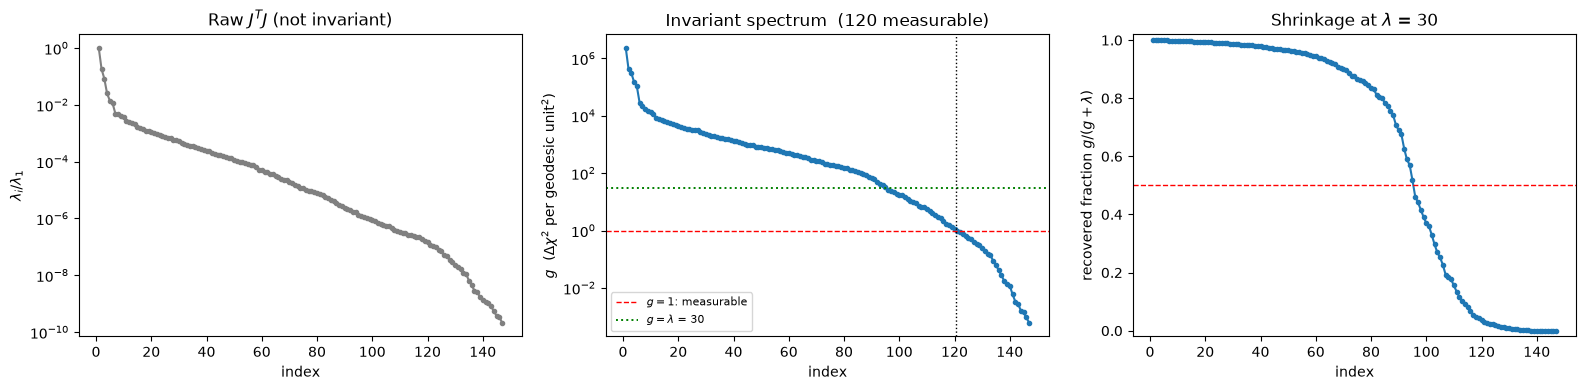


At the selected LAMBDA_PRIOR = 30, the data determines 120 of 147
parameter combinations more tightly than the prior does.


In [30]:
gen_spec, n_eff = report_sloppiness(theta_fit, q_train, G_train, w_train)
print(f"\nAt the selected LAMBDA_PRIOR = {LAMBDA_PRIOR:g}, the data determines "
      f"{n_eff} of {N_PARAMS}")
print(f"parameter combinations more tightly than the prior does.")

### Is Anything Exactly Invisible?

In $D(\mathbf q)$ each member bond enters with its own factor
$e^{i\mathbf q\cdot\mathbf R_{\mathbf n}}$ in its own block, so any change in any
orbit's $K$ changes $D$ somewhere. The
model therefore has no structural null space. The data sees $D$ only through the
scalar $G^\dagger D^{-1}G$ at the sampled points, so a direction can still be
invisible for a particular sampling.

The cell evaluates $J$ and $g$ at the true $K$ with unit weights for 0.5, 1, 2, 6 and
15 times `N_PARAMS` random $\mathbf q$-points, uniform in the resolution sphere and at
least 0.004 Å⁻¹ from any Bragg point. It reports $\mathrm{rank}(J)$, $g_{\max}$, the
90th-percentile $g$, and the number of directions with $g>1$. Below `N_PARAMS`
points the null space is forced by counting. Above that, the question is whether the number of measurable
directions keeps growing with $N$ or levels off.

N =    73:  rank(J) =  73/147   g_max 9.872e+09   g[90th pct] 0.000e+00   measurable (g>1)  73
N =   147:  rank(J) = 147/147   g_max 2.826e+08   g[90th pct] 2.070e+00   measurable (g>1) 134
N =   294:  rank(J) = 147/147   g_max 2.793e+09   g[90th pct] 5.292e+01   measurable (g>1) 143
N =   882:  rank(J) = 147/147   g_max 1.865e+09   g[90th pct] 3.228e+02   measurable (g>1) 145
N =  2205:  rank(J) = 147/147   g_max 7.031e+09   g[90th pct] 9.936e+02   measurable (g>1) 147

rank(J) saturates at min(N, 147); below that the null space is
forced by counting, not by physics.


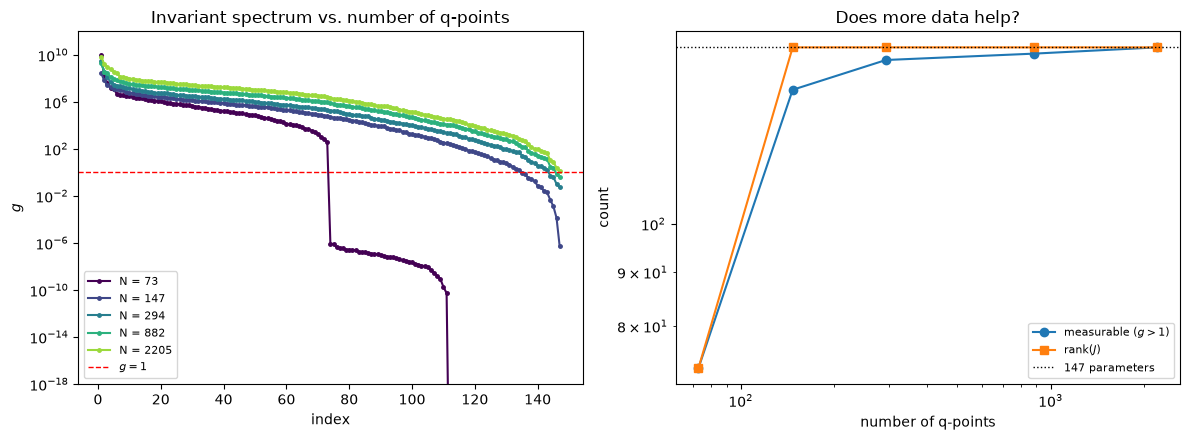


going from N = 294 to N = 2205 q-points (x7.5 more data):
   g_max        2.793e+09 -> 7.031e+09   (x2.5)
   g[90th pct]  5.292e+01 -> 9.936e+02   (x18.8)
   measurable   143 -> 147

g_max should grow roughly linearly in N: adding independent measurements
adds information to the well-determined directions. The question is what
happens at the sloppy end. If the measurable count grows in proportion to
N, those directions are merely under-sampled; if it creeps up far more
slowly than N does, the spectrum's shape is intrinsic to the 1/omega^2
weighting and more of the same kind of data buys little there.


In [31]:
# --- Does more data lift the sloppy directions? ----------------------------
# Evaluated at the TRUE K with uniform weights, so the result is a statement about
# the experimental design alone: no noise, no regularizer, no fitted values.
NULL_SIZES = [N_PARAMS//2, N_PARAMS, 2*N_PARAMS, 6*N_PARAMS, 15*N_PARAMS]
_rng_n = np.random.default_rng(17)
_hm_n = [int(np.ceil(L/D_MIN_DIFFUSE)) + 1 for L in (cell.a, cell.b, cell.c)]
_qcutn = 2*np.pi/D_MIN_DIFFUSE

def _sample_q(n):
    out = []
    while len(out) < n:
        h = np.array([_rng_n.uniform(-m, m) for m in _hm_n])
        if np.linalg.norm(B_recip @ h) < _qcutn and _bragg_distance(h[None])[0] > 0.004:
            out.append(h)
    return np.array(out)

_M_true = metric_at(theta_true)
_Mi_true = _sqrtm_inv_sym(_M_true)

_res = []
for _n in NULL_SIZES:
    _q = _sample_q(_n)
    _G = G_at_hkl_batch(_q[:,0], _q[:,1], _q[:,2])
    _J = weighted_jacobian(theta_true, _q, _G, np.ones(_n))
    _A = _Mi_true @ (_J.T @ _J) @ _Mi_true
    _g = np.maximum(np.linalg.eigvalsh(0.5*(_A + _A.T))[::-1], 0.0)
    _rank = int(np.linalg.matrix_rank(_J, tol=1e-10*np.linalg.norm(_J, 2)))
    _res.append((_n, _g, _rank))
    # g_min sits at the eigensolver's noise floor and carries no information;
    # a mid-spectrum quantile and the measurable count are the robust statistics.
    _g90 = _g[min(int(0.9*len(_g)), len(_g)-1)]
    print(f"N = {_n:5d}:  rank(J) = {_rank:3d}/{N_PARAMS}   g_max {_g[0]:.3e}   "
          f"g[90th pct] {_g90:.3e}   measurable (g>1) {int(np.sum(_g>1)):3d}")

print(f"\nrank(J) saturates at min(N, {N_PARAMS}); below that the null space is")
print("forced by counting, not by physics.")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for (_n, _g, _r), col in zip(_res, plt.cm.viridis(np.linspace(0, .85, len(_res)))):
    ax[0].semilogy(np.arange(1, len(_g)+1), np.maximum(_g, 1e-30), 'o-', ms=2.5,
                   color=col, label=f'N = {_n}')
ax[0].axhline(1.0, color='r', ls='--', lw=1, label=r'$g=1$')
ax[0].set_xlabel('index'); ax[0].set_ylabel(r'$g$')
ax[0].set_title('Invariant spectrum vs. number of q-points')
ax[0].legend(fontsize=8); ax[0].set_ylim(1e-18, None)

_ns = [r[0] for r in _res]
ax[1].loglog(_ns, [np.sum(r[1] > 1) for r in _res], 'o-', label=r'measurable ($g>1$)')
ax[1].loglog(_ns, [r[2] for r in _res], 's-', label='rank($J$)')
ax[1].axhline(N_PARAMS, color='k', ls=':', lw=1, label=f'{N_PARAMS} parameters')
ax[1].set_xlabel('number of q-points'); ax[1].set_ylabel('count')
ax[1].set_title('Does more data help?'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'null_space_test.png', dpi=150); plt.show()

_g0, _gN = _res[2][1], _res[-1][1]
_i90 = min(int(0.9*len(_g0)), len(_g0)-1)
print(f"\ngoing from N = {_res[2][0]} to N = {_res[-1][0]} q-points "
      f"(x{_res[-1][0]/_res[2][0]:.1f} more data):")
print(f"   g_max        {_g0[0]:.3e} -> {_gN[0]:.3e}   (x{_gN[0]/_g0[0]:.1f})")
print(f"   g[90th pct]  {_g0[_i90]:.3e} -> {_gN[_i90]:.3e}   "
      f"(x{_gN[_i90]/max(_g0[_i90],1e-300):.1f})")
print(f"   measurable   {int(np.sum(_g0>1))} -> {int(np.sum(_gN>1))}")
print("\ng_max should grow roughly linearly in N: adding independent measurements")
print("adds information to the well-determined directions. The question is what")
print("happens at the sloppy end. If the measurable count grows in proportion to")
print("N, those directions are merely under-sampled; if it creeps up far more")
print("slowly than N does, the spectrum's shape is intrinsic to the 1/omega^2")
print("weighting and more of the same kind of data buys little there.")

In [32]:
def bz_covariance(K_lab, n_grid=BZ_NGRID, offset=True, eig_floor=None, chunk=None):
    """Sigma = <u u^T> for all bodies of a cell (6 N_BODY x 6 N_BODY), from integrating
    D(q)^-1 over the Brillouin zone on an offset (Monkhorst-Pack) grid, with an
    absolute eigenvalue floor (see the P1 notebook). Block (b, b) is body b's 6x6
    covariance about its own centre of mass."""
    chunk = chunk or CHUNK_EVAL
    g = (np.arange(n_grid) + (0.5 if offset else 0.0))/n_grid
    Ig, Jg, Kg = np.meshgrid(g, g, g, indexing='ij')
    q_batch = np.column_stack([Ig.ravel(), Jg.ravel(), Kg.ravel()]) @ B_recip.T
    N = len(q_batch)
    if eig_floor is None:
        Dref = dynamical_matrix_batch(q_batch[:min(N, 2000)], unique, K_lab)
        eig_floor = 1e-9*mass_weighted_eigs(Dref).max()
    Sigma = np.zeros((N_DOF, N_DOF))
    for s0 in range(0, N, chunk):
        sl = slice(s0, min(s0 + chunk, N))
        Db = dynamical_matrix_batch(q_batch[sl], unique, K_lab)
        Dw = Msq_inv[None] @ Db @ Msq_inv.T[None]
        ev, evec = np.linalg.eigh(Dw)
        e_lab = Msq_inv.T[None] @ evec
        coeff = np.where(ev > eig_floor, 1.0/np.where(ev > eig_floor, ev, 1.0), 0.0)
        Sigma += np.real(np.tensordot(e_lab*coeff[:, None, :], e_lab.conj(), axes=([0, 2], [0, 2])))
    return Sigma/N

def rigid_jacobians(positions, com):
    """(m, 3, 6): maps a body's (Omega, v) about com to each atom's displacement."""
    d = np.asarray(positions) - com
    Jr = np.zeros((len(d), 3, 6))
    Jr[:, 0, 1] = d[:, 2]; Jr[:, 0, 2] = -d[:, 1]
    Jr[:, 1, 0] = -d[:, 2]; Jr[:, 1, 2] = d[:, 0]
    Jr[:, 2, 0] = d[:, 1]; Jr[:, 2, 1] = -d[:, 0]
    Jr[:, 0, 3] = Jr[:, 1, 4] = Jr[:, 2, 5] = 1.0
    return Jr

def body_block(Sigma, b, b2=None):
    b2 = b if b2 is None else b2
    return Sigma[6*b:6*b + 6, 6*b2:6*b2 + 6]

def atom_adp_tensors(Sigma6, positions, com):
    """Full anisotropic displacement tensor U (Å², 3x3) per atom of one body."""
    Jr = rigid_jacobians(positions, com)
    return Jr @ Sigma6[None] @ np.swapaxes(Jr, 1, 2)

def all_adp_tensors(Sigma):
    """U for every atom of the asymmetric-unit chains (concatenated in BODY_CHAINS order)."""
    return np.concatenate([atom_adp_tensors(body_block(Sigma, ASU_BODY[c]), CHAINS[c]['pos'], CHAINS[c]['com'])
                           for c in BODY_CHAINS])

def isotropic_B(U):
    return (8*np.pi**2/3)*np.trace(U, axis1=1, axis2=2)

def mean_predicted_B(K_lab, n_grid=BZ_NGRID):
    return isotropic_B(all_adp_tensors(bz_covariance(K_lab, n_grid=n_grid))).mean()

def check_bz_convergence(K_lab, grids=(8, 12, 16, BZ_NGRID, BZ_NGRID + 6)):
    """Sigma is the headline ADP prediction -- never report it without this."""
    print("BZ-grid convergence of the predicted mean B:")
    prev = None; Bs = []
    for n in grids:
        B = mean_predicted_B(K_lab, n_grid=n); Bs.append(B)
        delta = '' if prev is None else f'   Δ = {100*(B - prev)/prev:+.2f}%'
        print(f"  n_grid={n:3d}³ ({n**3:6d} q-points):  mean B = {B:8.3f} Å²{delta}")
        prev = B
    # The acoustic branches make the integrand ~1/q^2, so the offset-grid error falls as
    # 1/n. Extrapolating the last two grids in 1/n estimates the converged value.
    n1, n2 = grids[-2], grids[-1]
    B_inf = (n2*Bs[-1] - n1*Bs[-2])/(n2 - n1)
    print(f"  1/n extrapolation of the last two grids: mean B -> {B_inf:.3f} Å² "
          f"({100*(B_inf - Bs[-1])/Bs[-1]:+.1f}% from n_grid = {n2}; ratios between K are much better converged)")
    return B_inf

## What the Data Actually Determines

At each $\mathbf q$ the data measures

$$I(\mathbf q)=G^\dagger D^{-1}G=\sum_s\frac{|G^\dagger e_s|^2}{\omega_s^2}$$

(with $e_s$ the $M$-normalized eigenvectors), a single projection of $D^{-1}$
weighted by $1/\omega^2$. Stiff branches contribute little intensity, so the
stiff directions of $K$ are poorly constrained.

The displacement covariance
$\Sigma=\langle uu^{\mathsf T}\rangle=N^{-1}\sum_{\mathbf q}D(\mathbf q)^{-1}$
has the same $1/\omega^2$ weighting, integrated over the zone. It can therefore
be well determined even where $K$ is not.

A band structure compares 48 eigenvalues of $D(\mathbf q)$ at each $\mathbf q$,
out of 2304 real numbers. Matrices related by a unitary change of basis have the
same eigenvalues, so band structures can agree closely while the $K$ differ
substantially.

The cell below draws $\theta\sim\mathcal N(\hat\theta,\mathcal C)$ with
$\mathcal C=(J^{\mathsf T}J+\tfrac12\partial^2R/\partial\theta^2)^{-1}$
(inflated by $\chi^2/\mathrm{dof}$) and propagates the samples to three outputs:

1. The dispersion, with a 95% band. The band is centred on the fit, because
   sampling $\theta$ symmetrically makes $K=LL^{\mathsf T}$ biased stiff.
2. The predicted mean $B$.
3. The spread in $K$: the RMS geodesic distance of the samples from the fit, per
   orbit ($d_o$) and in total ($d$).

Cholesky sampling bias, removed by centring: median sample frequency is +0.5% off the fit


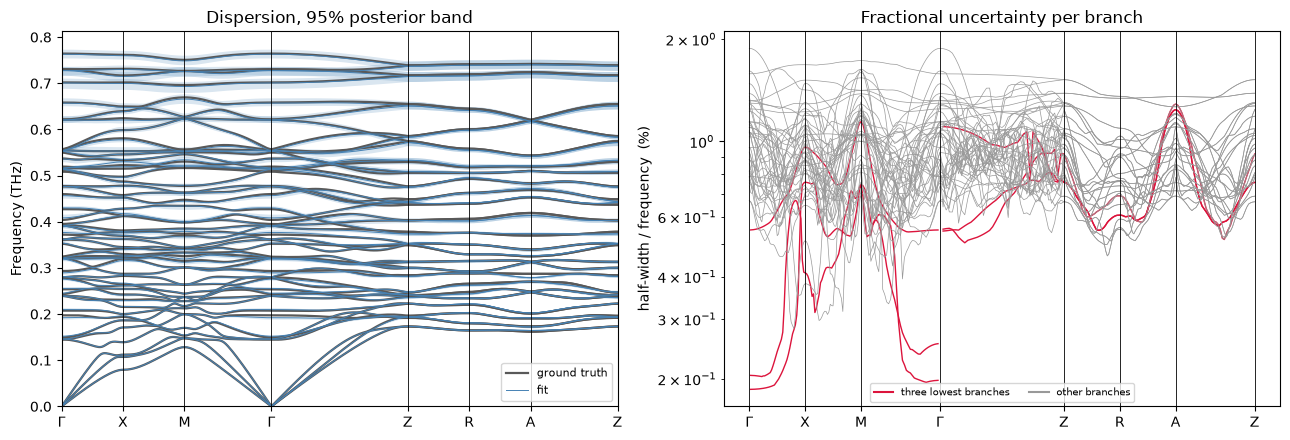

Ground-truth dispersion inside the 95% posterior band: 87.1% of (q, branch) pairs
Median fractional uncertainty, acoustic branches 0-2: 0.62%
Median fractional uncertainty, optic branches 3-47: 0.88%

Mean B: fit 0.831 Å²   truth 0.831 Å²
   posterior spread ±0.003 Å² (0.3% of the fit)
   sample median 0.820 Å² -- the offset from the fit is the
   Cholesky sampling bias described above, not an uncertainty.

RMS geodesic distance of posterior samples from the fit:
               orbit  RMS distance  factor e^d
       A–A(0, 0, -1)         0.742        2.10
       A–B(0, 0, -1)         0.332        1.39
            A–A[s=3]         0.219        1.25
 A–B[s=2](0, -1, -1)         0.669        1.95
  A–B[s=2](0, -1, 0)         0.384        1.47
       B–B(0, 0, -1)         0.668        1.95
  B–B[s=1](-1, 0, 0)         0.343        1.41
               total         1.367        3.92

Read the three together. The comparison that matters is the fractional
uncertainty on the dispersion and on 

In [33]:
# --- Propagate the posterior to physical observables -----------------------
# Covariance from the Gauss-Newton Hessian of the data term plus the prior's
# curvature. With chi^2 = sum w r^2 the Fisher information is J^T J, and treating
# the penalty R as -2 ln(prior) contributes R''/2, so C = (J^T J + H_R/2)^-1.
# Inflating by chi2/dof allows for model error on top of the quoted sigmas.

N_POST = 60          # posterior samples
INFLATE_BY_CHI2 = True

def posterior_cov_sqrt(theta, q_list, G_list, weights, scale=1.0, chi2_dof=1.0):
    Jm = weighted_jacobian(theta, q_list, G_list, weights, scale)
    H  = Jm.T @ Jm + LAMBDA_PRIOR*parameter_metric(theta)
    H  = 0.5*(H + H.T)
    w, V = np.linalg.eigh(H)
    w = np.maximum(w, 1e-12*w.max())
    f = np.sqrt(chi2_dof) if INFLATE_BY_CHI2 else 1.0
    return f*(V*w**-0.5)          # C^(1/2): samples = theta + Csqrt @ randn

_Csq = posterior_cov_sqrt(theta_fit, q_train, G_train, w_train, chi2_dof=chi2_dof)
_rng_p = np.random.default_rng(3)
_samples = theta_fit[None, :] + (_Csq @ _rng_p.standard_normal((N_PARAMS, N_POST))).T

# --- 1. dispersion ---------------------------------------------------------
_bands = np.stack([bandstructure_freqs(build_K(theta_to_Lmap(t))[1]) for t in _samples])
# Centre the band on the fit. Sampling theta symmetrically does NOT give samples
# of K centred on K_fit: with K = L L^T, E[K] = K_fit + E[dL dL^T] > K_fit, so the
# ensemble is systematically stiffer than the fit and every nonlinear observable
# is biased. Quoting raw percentiles would report a band offset from the value it
# is supposed to bracket. The width is taken from the samples, the centre from
# the fit.
_med = np.median(_bands, axis=0)
_lo, _hi = np.percentile(_bands, [2.5, 97.5], axis=0)
_fit_b   = bandstructure_freqs(K_LAB_FIT)
_lo, _hi = _lo - _med + _fit_b, _hi - _med + _fit_b
print(f"Cholesky sampling bias, removed by centring: median sample frequency is "
      f"{100*np.nanmedian((_med - _fit_b)/np.maximum(_fit_b,1e-12)):+.1f}% off the fit")
_true_b  = bandstructure_freqs(K_LAB_TRUE)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for s in range(N_DOF):
    ax[0].fill_between(x, _lo[:, s], _hi[:, s], color='steelblue', alpha=0.2, lw=0)
ax[0].plot(x, _true_b, color='0.35', lw=1.6)
ax[0].plot(x, _fit_b,  color='steelblue', lw=0.7)
ax[0].plot([], [], color='0.35', lw=1.6, label='ground truth'); ax[0].plot([], [], color='steelblue', lw=0.7, label='fit')
for ti in tick_idx: ax[0].axvline(x[ti], color='k', lw=0.6)
ax[0].set_xticks([x[ti] for ti in tick_idx]); ax[0].set_xticklabels(path_labels)
ax[0].set_ylabel('Frequency (THz)'); ax[0].set_xlim(x[0], x[-1]); ax[0].set_ylim(0)
ax[0].set_title('Dispersion, 95% posterior band'); ax[0].legend(fontsize=8)

# at Γ the acoustic frequencies are zero, so the ratio is undefined there; mask those points
_rel = np.where(_fit_b > 1e-3*_fit_b.max(), 0.5*(_hi - _lo)/np.maximum(_fit_b, 1e-12), np.nan)
for s in range(N_DOF):
    ax[1].plot(x, 100*_rel[:, s], lw=1.0 if s < 3 else 0.5, color='crimson' if s < 3 else '0.6')
ax[1].plot([], [], color='crimson', label='three lowest branches'); ax[1].plot([], [], color='0.6', label='other branches')
for ti in tick_idx: ax[1].axvline(x[ti], color='k', lw=0.6)
ax[1].set_xticks([x[ti] for ti in tick_idx]); ax[1].set_xticklabels(path_labels)
ax[1].set_ylabel('half-width / frequency  (%)'); ax[1].set_yscale('log')
ax[1].set_title('Fractional uncertainty per branch'); ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'posterior_bands.png', dpi=150); plt.show()

_inside = np.mean((_true_b >= _lo) & (_true_b <= _hi))
print(f"Ground-truth dispersion inside the 95% posterior band: {_inside:.1%} of "
      f"(q, branch) pairs")
if _inside < 0.8:
    print("  Coverage well below 95%. The band is a WIDTH, not a coverage")
    print("  guarantee: a regularized estimator is biased toward the prior, and")
    print("  the posterior covariance describes scatter about the biased mean, not")
    print("  the distance to the truth. Expect this whenever lambda is chosen by")
    print("  cross-validation, which optimises prediction rather than coverage.")
print(f"Median fractional uncertainty, acoustic branches 0-2: "
      f"{100*np.nanmedian(_rel[:, :3]):.2f}%")
print(f"Median fractional uncertainty, optic branches 3-{N_DOF - 1}: "
      f"{100*np.nanmedian(_rel[:, 3:]):.2f}%")

# --- 2. displacement parameters -------------------------------------------
_B = np.array([mean_predicted_B(build_K(theta_to_Lmap(t))[1], n_grid=12)
               for t in _samples[:min(N_POST, 25)]])
_B_true = mean_predicted_B(K_LAB_TRUE, n_grid=12)
_B_fit = mean_predicted_B(K_LAB_FIT, n_grid=12)
print(f"\nMean B: fit {_B_fit:.3f} Å²   truth {_B_true:.3f} Å²")
print(f"   posterior spread ±{np.std(_B):.3f} Å² ({100*np.std(_B)/max(_B_fit,1e-12):.1f}% of the fit)")
print(f"   sample median {np.median(_B):.3f} Å² -- the offset from the fit is the")
print( "   Cholesky sampling bias described above, not an uncertainty.")

# --- 3. the stiffnesses themselves ----------------------------------------
_dsamp = [geodesic_per_contact(theta_fit, t) for t in _samples[:30]]
_spread = {c: float(np.sqrt(np.mean([d[c]**2 for d in _dsamp]))) for c in shell_order}
_spread_tot = float(np.sqrt(np.mean([sum(v**2 for v in d.values()) for d in _dsamp])))
print(f"\nRMS geodesic distance of posterior samples from the fit:")
print(f"{'orbit':>20s} {'RMS distance':>13s} {'factor e^d':>11s}")
for c in shell_order:
    print(f"{unique[c]['label']:>20s} {_spread[c]:13.3f} {np.exp(_spread[c]):11.2f}")
print(f"{'total':>20s} {_spread_tot:13.3f} {np.exp(_spread_tot):11.2f}")
print("\nRead the three together. The comparison that matters is the fractional")
print("uncertainty on the dispersion and on the mean B against the per-orbit")
print("spread in K: where the observables are much better pinned than the")
print("stiffnesses, the data is measuring the soft dynamics rather than the springs.")

### Which Directions Are Recoverable

The generalized eigenvectors of (data curvature, prior curvature) at the prior
split parameter space into $n_{\rm eff}$ data-dominated directions ($f>1$) and
the rest. The cell builds two alternative ground truths, one displaced from the
prior along the sum of the data-dominated directions and one along the sum of
the others, both scaled to a distance $d$ = `RECOVERY_D` from the prior. The
original `L_TRUE` is included for comparison. For each truth the cell generates
synthetic data at all sampled points twice, noiseless and with the notebook's
noise model, and refits from the prior each time. It reports:

* prior→truth, and truth→fit for both refits;
* the **recovered fraction along the displacement**,
  $\langle\theta_{\rm fit}-\theta_{\rm prior},\delta\rangle_M/\langle\delta,\delta\rangle_M$
  with $\delta=\theta_{\rm true}-\theta_{\rm prior}$ and $M$ the metric at the prior,
  next to its linear-Gaussian prediction $\sum_ic_i^2\frac{f_i}{1+f_i}\big/\sum_ic_i^2$
  ($c_i$ the components of $\delta$ along the eigendirections);
* $R$ and $CC$ of the noisy refit.

The noiseless refit isolates the regularization bias. The noisy refit adds the
motion driven by noise, which is not confined to the direction of $\delta$. Its
size is shown by a **noise-floor** refit with the truth equal to the prior. That
distance has the linear expectation
$\bigl(\sum_i f_i/[(1+f_i)^2\lambda]\bigr)^{1/2}$, dominated by directions with
$f\approx1$. When the noise floor is comparable to `RECOVERY_D`, the noisy
truth→fit, and hence $1-d_{tf}/d_{pt}$, measures the noise rather than
recoverability.

In [34]:
# --- Stiff vs. sloppy: which displacements from the prior are recoverable? --
Jm_p    = weighted_jacobian(THETA_PRIOR, q_train, G_train, w_train)
Hd_p    = Jm_p.T @ Jm_p
Hr_p    = LAMBDA_PRIOR*parameter_metric(THETA_PRIOR)   # prior precision
_Binv   = _sqrtm_inv_sym(Hr_p)
_M      = 0.5*((_Binv @ Hd_p @ _Binv) + (_Binv @ Hd_p @ _Binv).T)
_gv, _U = np.linalg.eigh(_M)
_ord    = np.argsort(_gv)[::-1]
_gv, _U = _gv[_ord], _U[:, _ord]
_dirs   = _Binv @ _U                      # back to theta coordinates
_n_eff  = int(np.sum(_gv > 1.0))
print(f"data-dominated directions at the PRIOR (f = g/λ > 1): "
      f"{_n_eff} / {N_PARAMS}")
print("  (evaluated at the prior; report_sloppiness evaluates at the fit,\n"
      "   and the model is nonlinear, so the two need not agree exactly)")

def _unit(v): return v/np.linalg.norm(v)
_stiff_dir  = _unit(_dirs[:, :max(_n_eff, 1)].sum(axis=1))
_sloppy_dir = _unit(_dirs[:, _n_eff:].sum(axis=1)) if _n_eff < N_PARAMS else None

RECOVERY_D = 1.5            # geodesic size d of each test displacement from the prior
_M_pr = Hr_p/LAMBDA_PRIOR   # geodesic metric at the prior (parameter_metric)

def _make_truth(direction, target_d=RECOVERY_D, tol=0.02):
    """Displace the prior along `direction`, scaled to a target geodesic distance."""
    lo, hi = 1e-4, 50.0
    for _ in range(60):
        a = 0.5*(lo + hi)
        th = THETA_PRIOR + a*direction
        try:
            d = geodesic_total(THETA_PRIOR, th)
        except np.linalg.LinAlgError:
            hi = a; continue
        if abs(d - target_d) < tol: break
        lo, hi = (a, hi) if d < target_d else (lo, a)
    return th, d

def _refit(theta_t, noisy, seed=5):
    """Synthetic data from theta_t at all sampled points (noisy or noiseless, same
    sigma either way), refit from the prior. Returns the fit and its R, CC."""
    _, Klab_t = build_K(theta_to_Lmap(theta_t))
    I_t = diffuse_intensity_batch(Klab_t, q_all[:,0], q_all[:,1], q_all[:,2], G_arr=G_all)
    sg  = NOISE_FLOOR + NOISE_SCALE*np.sqrt(np.clip(I_t, 0, None))
    I_o = I_t + np.random.default_rng(seed).normal(0, sg) if noisy else I_t.copy()
    th, _, _, _, _, _ = refine(THETA_PRIOR, (q_all, G_all, I_o, 1.0/sg**2),
                               max_block=30, verbose=False)
    _, Klab_f = build_K(theta_to_Lmap(th))
    R, CC, _ = fit_stats(Klab_f, q_all, G_all, I_o)
    return th, R, CC

def _along(theta_f, theta_t):
    """Recovered fraction along the displacement: <fit - prior, truth - prior>_M /
    <truth - prior, truth - prior>_M, with M the metric at the prior. Motion of the
    fit in directions orthogonal to the displacement does not count."""
    dt, df = theta_t - THETA_PRIOR, theta_f - THETA_PRIOR
    return float(df @ _M_pr @ dt)/float(dt @ _M_pr @ dt)

# Linear-Gaussian predictions, from the curvatures on the points actually refit
# (all sampled points, sigma from the prior's intensities).
_sg_p = NOISE_FLOOR + NOISE_SCALE*np.sqrt(np.clip(
    diffuse_intensity_batch(K_LAB_PRIOR, q_all[:,0], q_all[:,1], q_all[:,2], G_arr=G_all), 0, None))
_Ja   = weighted_jacobian(THETA_PRIOR, q_all, G_all, 1.0/_sg_p**2)
_fa, _Ua = np.linalg.eigh(0.5*((_Binv @ _Ja.T @ _Ja @ _Binv) + (_Binv @ _Ja.T @ _Ja @ _Binv).T))
_fa   = np.maximum(_fa, 0.0); _Va = _Binv @ _Ua          # Hr_p-orthonormal directions
def _predicted(theta_t):
    """Noiseless recovered fraction along the displacement, sum c^2 f/(1+f) / sum c^2."""
    c = _Va.T @ Hr_p @ (theta_t - THETA_PRIOR)
    return float(np.sum(c**2*_fa/(1 + _fa))/np.sum(c**2))
# Noise alone moves the fit by (F+P)^-1 J^T eps, whose squared geodesic size has
# expectation sum_i f_i/((1+f_i)^2 lambda).
_noise_pred = float(np.sqrt(np.sum(_fa/((1 + _fa)**2*LAMBDA_PRIOR))))

_th0n, _, _ = _refit(THETA_PRIOR, noisy=True)
_noise_obs  = geodesic_total(THETA_PRIOR, _th0n)
print(f"\nnoise floor: truth = prior, noisy data -> fit lands {_noise_obs:.3f} from the truth "
      f"(linear prediction {_noise_pred:.3f})")

print(f"\n{'':22s} {'prior→':>7s} {'truth→fit':>19s}   {'recovered along the displacement':>34s}")
print(f"{'perturbation':22s} {'truth':>7s} {'noiseless':>9s} {'noisy':>9s}   "
      f"{'predicted':>10s} {'noiseless':>10s} {'noisy':>9s}   {'R (noisy)':>9s} {'CC (noisy)':>10s}")
_rows_rec = []
for _lab, _th_t in ([('stiff subspace',  _make_truth(_stiff_dir)[0])] +
                    ([('sloppy subspace', _make_truth(_sloppy_dir)[0])] if _sloppy_dir is not None else []) +
                    [('isotropic (L_TRUE)', theta_true)]):
    _f0, _, _        = _refit(_th_t, noisy=False)
    _f1, _R1, _CC1   = _refit(_th_t, noisy=True)
    _row = (geodesic_total(THETA_PRIOR, _th_t), geodesic_total(_th_t, _f0), geodesic_total(_th_t, _f1),
            _predicted(_th_t), _along(_f0, _th_t), _along(_f1, _th_t), _R1, _CC1)
    _rows_rec.append((_lab,) + _row)
    print(f"{_lab:22s} {_row[0]:7.3f} {_row[1]:9.3f} {_row[2]:9.3f}   "
          f"{_row[3]:10.1%} {_row[4]:10.1%} {_row[5]:9.1%}   {_row[6]:9.4f} {_row[7]:10.5f}")

print("\nThe noiseless columns isolate the regularization bias: 'recovered along the")
print("displacement' should follow the linear prediction, near 100% for the stiff")
print("subspace and near 0% for the sloppy one. The noisy truth→fit adds the")
print("noise-driven motion, whose size is the noise-floor line. When that is")
print("comparable to prior→truth, truth→fit measures the noise, not recoverability.")

data-dominated directions at the PRIOR (f = g/λ > 1): 98 / 147
  (evaluated at the prior; report_sloppiness evaluates at the fit,
   and the model is nonlinear, so the two need not agree exactly)

noise floor: truth = prior, noisy data -> fit lands 0.500 from the truth (linear prediction 0.545)

                        prior→           truth→fit     recovered along the displacement
perturbation             truth noiseless     noisy    predicted  noiseless     noisy   R (noisy) CC (noisy)
stiff subspace           1.491     0.174     0.538        93.8%      93.7%     93.1%      0.0082    0.99999
sloppy subspace          1.489     1.304     1.335        12.5%      13.8%     21.2%      0.0085    0.99999
isotropic (L_TRUE)       7.737     5.010     5.043        68.7%      55.6%     55.9%      0.0102    0.99998

The noiseless columns isolate the regularization bias: 'recovered along the
displacement' should follow the linear prediction, near 100% for the stiff
subspace and near 0% for the sl

### Reading the Stiff and Sloppy Directions

The next cell computes two sets of eigendirections.

**At the prior: shrinkage.** These are the generalized eigendirections of data
curvature $F=J^{\mathsf T}J$ and prior curvature $P=\lambda M$, both at the
prior. For a linear-Gaussian model the MAP displacement from the prior along a
direction with eigenvalue $f$ is $f/(1+f)$ of the true displacement, and
$n_{\rm eff}$ counts $f>1$. The refit test further down displaces the prior along
single directions of this set. `synthetic_7tx0_stiff_sloppy_anatomy.png` shows $f$
and $f/(1+f)$.

**At the fit: which directions the data constrains.** The cell solves the
generalized eigenproblem $(F,M)$ with $F=J^{\mathsf T}J$ and
$M=$ `metric_at(theta_fit)`, both evaluated at the fit. This gives the invariant
spectrum $g$ ($\Delta\chi^2$ per squared geodesic step) and directions that are
orthonormal in the metric at the fit. For each direction it reports $g$, the data
share of the local precision $g/(g+\lambda)$, the composition, and the effect.
The stacked bar chart (`synthetic_7tx0_direction_block_composition.png`) shows the $g$
spectrum, with the $g=1$ and $g=\lambda$ lines, above the $RR/TR/TT$ split of
every direction sorted by $g$.

**Composition** (`direction_anatomy(direction, theta0)`). For each orbit,
$\delta K=\delta L\,L_0^{\mathsf T}+L_0\,\delta L^{\mathsf T}$ at the base point
$\theta_0$. Then $X=W\,\delta K\,W^{\mathsf T}$, where $W$ comes from the
translation-first block factorization of $K_0=K(\theta_0)$:

$$K_0=UDU^{\mathsf T},\quad
U=\begin{pmatrix}I&K_{RT}K_{TT}^{-1}\\0&I\end{pmatrix},\quad
D=\mathrm{diag}(S_R,K_{TT}),\quad S_R=K_{RR}-K_{RT}K_{TT}^{-1}K_{TR},\quad
W=D^{-1/2}U^{-1}.$$

With this $W$, $\sum_{\mathbf n}\|X_{\mathbf n}\|_F^2=\delta\theta^{\mathsf T}M(\theta_0)\,\delta\theta$
(the squared geodesic length at $\theta_0$), and
$\|X\|_F^2=\|X_{RR}\|_F^2+2\|X_{TR}\|_F^2+\|X_{TT}\|_F^2$ exactly. The blocks
mean:

* $X_{TT}=K_{TT}^{-1/2}\,\delta K_{TT}\,K_{TT}^{-1/2}$: the relative change in the
  translational stiffness;
* $X_{RR}$ and $X_{TR}$: the rotational and coupling changes, measured against
  $S_R$ (the rotational stiffness with translations relaxed), after removing the
  part explained by $\delta K_{TT}$.

The split is unchanged by moving the reference point, rotating the axes, or
changing units. Putting translations first is what makes it independent of the
reference point. A pure translation is the same motion whatever point it is
referred to, but what counts as a pure rotation changes with that point. At the
prior ($K_{TR}=0$) the split reduces to $X=K_{\rm prior}^{-1/2}\delta K\,K_{\rm prior}^{-1/2}$.

The fractions are computed in $K$, not in $\theta$, because the Cholesky entries
do not separate by block. The three blocks have 6, 9 and 6 independent components
per orbit, so a direction spread evenly gives $RR:TR:TT=6:9:6$ (out of 21).
The directions form a complete orthonormal basis in the metric, so the average
over all `N_PARAMS` reproduces that split exactly. The cell prints the average as a
check.

**Effect** (`direction_effect(direction, theta0=theta_fit)`). Each direction is
rescaled to a geodesic displacement of `EFFECT_D` about the fit, and the cell
reports the fractional change in:

* the acoustic frequencies near Γ;
* the optic frequencies at Γ;
* all 48 branches at $(\tfrac12,\tfrac12,\tfrac12)$;
* the mean predicted $B$.

**Expected pattern.** The well-determined directions should be mostly
translational and the poorly determined ones mostly rotational, for three
reasons:

1. $I\propto1/\omega^2$, and the librational branches are the stiff ones.
2. Near any reciprocal-lattice point the acoustic eigenvectors are nearly pure
   translations, so the halos couple mainly through the translational part of
   $G$.
3. The rotational coupling $\mathbf q\times L$ is weak at low $|\mathbf q|$,
   because the contrast centroid lies close to the centre of mass.

The $TR$ block should appear in both groups.

recovered fraction f/(1+f):  >90% for  77 directions, >50% for  98, <10% for  32
n_eff = #(f > 1) = 98 / 147   at LAMBDA_PRIOR = 30
  f = g/λ is prior-relative; the prior-free count is #(g > 1),
  reported by report_sloppiness. They coincide only when λ = 1.


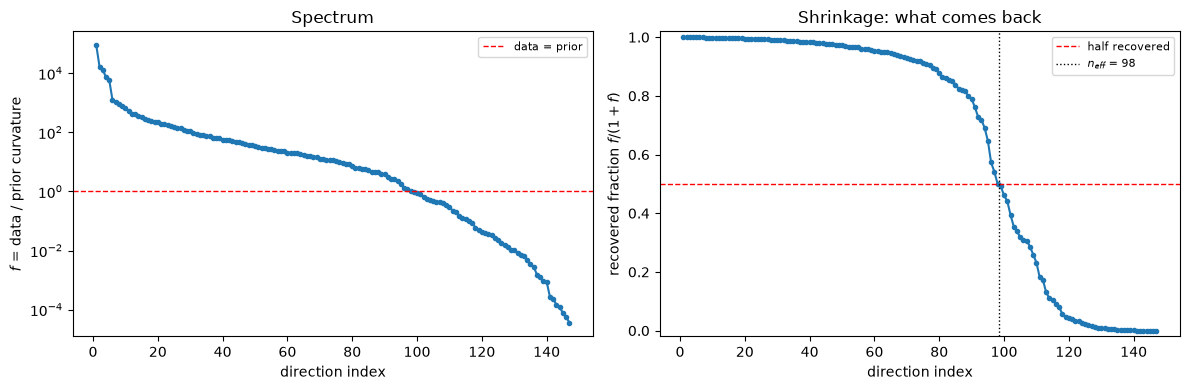


AT THE FIT: 120 of 147 directions measurable (g > 1); data share g/(g+λ) > 50% for 95, > 90% for 70  (λ = 30)

Composition at the fit, and the effect of a displacement of geodesic size 0.2 about the fit:
 dir         g  data %    RR    TR    TT  iso(TT)          top orbit   Δν_ac  Δν_opt   Δν_zb      ΔB
   0  2.30e+06  100.0%  0.01  0.04  0.95     0.75           A–A[s=3]    4.5%    2.8%    3.0%    7.0%
   1  4.24e+05  100.0%  0.02  0.10  0.88     0.18           A–A[s=3]    3.0%    2.0%    1.5%    2.5%
   2  3.10e+05  100.0%  0.00  0.01  0.98     0.22      B–B(0, 0, -1)    3.0%    0.7%    0.5%    0.1%
 119  1.13e+00    3.6%  0.15  0.84  0.00     0.15      A–A(0, 0, -1)    0.0%    0.0%    0.0%    0.0%
 120  9.34e-01    3.0%  0.06  0.94  0.00     0.21 A–B[s=2](0, -1, -1)    0.0%    0.0%    0.0%    0.0%
 144  1.39e-03    0.0%  1.00  0.00  0.00     0.09      A–A(0, 0, -1)    0.0%    0.0%    0.0%    0.0%
 145  9.30e-04    0.0%  1.00  0.00  0.00     0.19      A–A(0, 0, -1)    0.0%    0.0%   

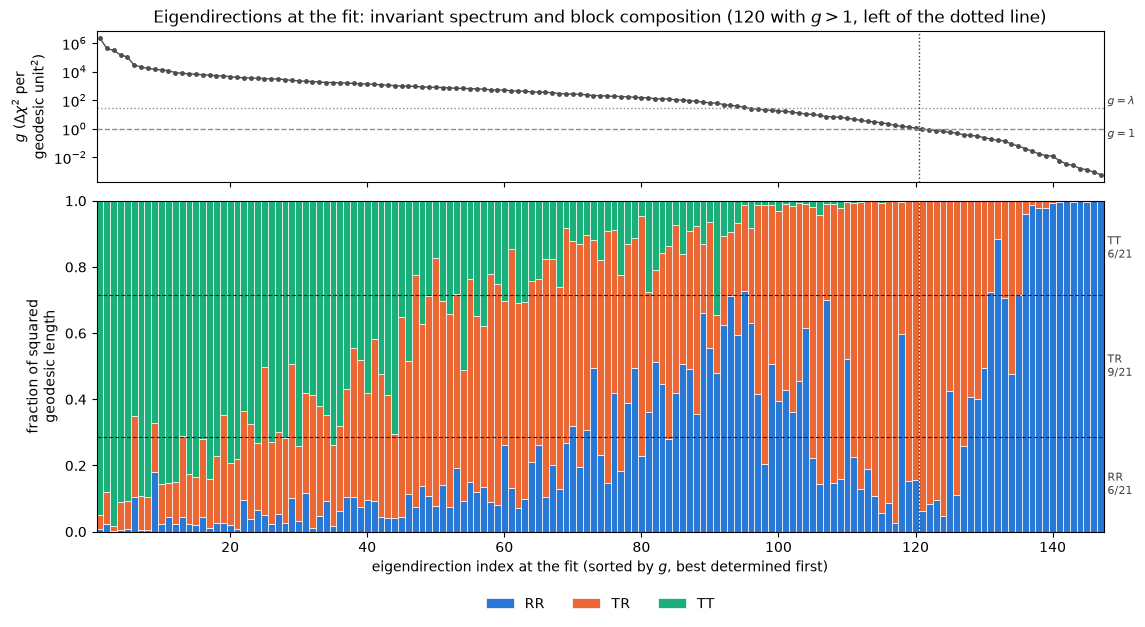

In [35]:
# ============================================================================
# Directions at the PRIOR: the shrinkage relative to the prior, f/(1+f),
# which the refit test below checks. f = g/lambda with both at the prior.
# ============================================================================
_Fm = Jm_p.T @ Jm_p                      # data curvature at the prior
_Pm = LAMBDA_PRIOR*parameter_metric(THETA_PRIOR)   # prior precision = lambda * M
_Pi = _sqrtm_inv_sym(_Pm)
_A  = _Pi @ _Fm @ _Pi
_f, _V = np.linalg.eigh(0.5*(_A + _A.T))
_o  = np.argsort(_f)[::-1]
_f, _V = np.maximum(_f[_o], 0.0), _V[:, _o]
_DIRS = _Pi @ _V                          # back to theta coordinates
_shrink = _f/(1.0 + _f)

print(f"recovered fraction f/(1+f):  >90% for {np.sum(_shrink>0.9):3d} directions, "
      f">50% for {np.sum(_shrink>0.5):3d}, <10% for {np.sum(_shrink<0.1):3d}")
print(f"n_eff = #(f > 1) = {int(np.sum(_f>1))} / {N_PARAMS}   at LAMBDA_PRIOR = {LAMBDA_PRIOR:g}")
print("  f = g/λ is prior-relative; the prior-free count is #(g > 1),\n"
      "  reported by report_sloppiness. They coincide only when λ = 1.")

# --- composition of a direction -------------------------------------------
def _tfirst_whitener(K):
    """W_K such that X = W_K dK W_K^T has ||X||_F^2 = tr(K^-1 dK K^-1 dK).

    Uses the translation-first block factorization K = U D U^T with
    U = [[I, K_RT K_TT^-1], [0, I]] and D = diag(S_R, K_TT), where
    S_R = K_RR - K_RT K_TT^-1 K_TR is the rotational stiffness with translations
    relaxed. Then W_K = D^{-1/2} U^{-1}, and the blocks of X are:
      X_TT = K_TT^{-1/2} dK_TT K_TT^{-1/2}    (relative change of K_TT)
      X_RR, X_RT: the rotational and coupling changes measured against S_R,
      after the part explained by dK_TT is removed.
    When K_TR = 0 this reduces to X = K^{-1/2} dK K^{-1/2}. The split does not
    depend on the reference point, because moving the reference point leaves
    K_TT, S_R and these blocks unchanged."""
    K_RT, K_TT = K[:3, 3:], K[3:, 3:]
    C = K_RT @ np.linalg.inv(K_TT)
    Uinv = np.eye(6); Uinv[:3, 3:] = -C
    S_R = K[:3, :3] - C @ K_RT.T
    Dmh = np.zeros((6, 6))
    Dmh[:3, :3] = _sqrtm_inv_sym(S_R); Dmh[3:, 3:] = _sqrtm_inv_sym(K_TT)
    return Dmh @ Uinv

def direction_anatomy(direction, theta0=None):
    """Where a theta-direction lives in K, measured in the geodesic metric at the
    base point theta0 (default THETA_PRIOR).

    For each contact, dK = dL L0^T + L0 dL^T (local frame, exact) and
    X = W dK W^T with W from _tfirst_whitener(K(theta0)). sum_n ||X_n||_F^2 is the
    squared geodesic length of the step at theta0 (direction^T metric_at(theta0)
    direction), and ||X||^2 = ||X_RR||^2 + 2||X_TR||^2 + ||X_TT||^2 exactly.
    A direction spread evenly over the 21 independent components of each K gives
    RR : TR : TT = 6 : 9 : 6 (out of 21)."""
    theta0 = THETA_PRIOR if theta0 is None else theta0
    L0, dLm = theta_to_Lmap(theta0), theta_to_Lmap(direction)
    K0, _ = build_K(L0)
    X = {}
    for c in shell_order:
        W = _tfirst_whitener(K0[c])
        X[c] = W @ (dLm[c] @ L0[c].T + L0[c] @ dLm[c].T) @ W.T
    tot = sum(np.sum(X[c]**2) for c in shell_order) or 1.0
    per_contact = {c: np.sum(X[c]**2)/tot for c in shell_order}
    blocks, iso = {}, {}
    for name, sl in [('RR', slice(0,3)), ('TT', slice(3,6))]:
        b = sum(np.sum(X[c][sl, sl]**2) for c in shell_order)
        t = sum((np.trace(X[c][sl, sl])**2)/3 for c in shell_order)
        blocks[name] = b/tot; iso[name] = t/max(b, 1e-300)
    blocks['TR'] = sum(2*np.sum(X[c][0:3,3:6]**2) for c in shell_order)/tot
    return per_contact, blocks, iso

# --- what a direction does, physically ------------------------------------
# Every direction is rescaled to the SAME geodesic distance before the effect is
# measured, so the comparison is between physical perturbations of equal size.
_q_ac = np.array([[0.04,0,0],[0,0.04,0],[0,0,0.04]]) @ B_recip.T   # near Gamma
_q_zb = (B_recip @ np.array([0.5,0.5,0.5]))[None, :]
_EFF_AC, _EFF_G, _EFF_ZB = slice(0, 9), slice(9, 9 + N_DOF - 3), slice(9 + N_DOF - 3, 9 + 2*N_DOF - 3)
EFFECT_D = 0.20        # geodesic distance at which every direction is compared

def scale_to_geodesic(direction, target_d=EFFECT_D, tol=0.01, theta0=None):
    """Amplitude along `direction` giving a geodesic displacement (geodesic_total)
    of target_d from the base point theta0 (default THETA_PRIOR)."""
    theta0 = THETA_PRIOR if theta0 is None else theta0
    lo, hi = 1e-6, 1e4
    for _ in range(80):
        a = np.sqrt(lo*hi)
        try:
            d = geodesic_total(theta0, theta0 + a*direction)
        except np.linalg.LinAlgError:
            hi = a; continue
        if abs(d - target_d) < tol*target_d: return a
        lo, hi = (a, hi) if d < target_d else (lo, a)
    return a

def direction_effect(direction, target_d=EFFECT_D, theta0=None):
    """Fractional change in physical observables for a displacement of fixed
    geodesic size along `direction`, centred on theta0 (default THETA_PRIOR).
    Branches are sorted ascending, so [:3] are acoustic and [3:] optic."""
    theta0 = THETA_PRIOR if theta0 is None else theta0
    a = scale_to_geodesic(direction, target_d, theta0=theta0)
    def obs(th):
        _, Kl = build_K(theta_to_Lmap(th))
        f_ac = bandstructure_freqs(Kl, _q_ac)[:, :3].ravel()   # acoustic near Gamma
        f_G  = bandstructure_freqs(Kl, np.zeros((1,3)))[0][3:] # optic at Gamma
        f_zb = bandstructure_freqs(Kl, _q_zb)[0]               # zone boundary, all branches
        B    = mean_predicted_B(Kl, n_grid=8)
        return np.r_[f_ac, f_G, f_zb, B]
    p, m = obs(theta0 + a*direction), obs(theta0 - a*direction)
    return np.abs(p-m)/np.maximum(0.5*np.abs(p+m), 1e-30)

# --- prior-based spectrum and shrinkage ------------------------------------
_ne = max(int(np.sum(_f > 1)), 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(np.arange(1, N_PARAMS+1), np.maximum(_f, 1e-12), 'o-', ms=3)
ax[0].axhline(1.0, color='r', ls='--', lw=1, label='data = prior')
ax[0].set_xlabel('direction index'); ax[0].set_ylabel('$f$ = data / prior curvature')
ax[0].set_title('Spectrum'); ax[0].legend(fontsize=8)
ax[1].plot(np.arange(1, N_PARAMS+1), _shrink, 'o-', ms=3)
ax[1].axhline(0.5, color='r', ls='--', lw=1, label='half recovered')
ax[1].axvline(_ne+0.5, color='k', ls=':', lw=1, label=f'$n_{{eff}}$ = {_ne}')
ax[1].set_xlabel('direction index'); ax[1].set_ylabel('recovered fraction $f/(1+f)$')
ax[1].set_ylim(-0.02, 1.02); ax[1].set_title('Shrinkage: what comes back')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'stiff_sloppy_anatomy.png', dpi=150); plt.show()

# ============================================================================
# Directions at the FIT: which combinations of K does the data constrain there?
# ============================================================================
# Generalized eigenproblem (F, M) with both evaluated at theta_fit:
#   F = J^T J  (data curvature),  M = metric_at(theta_fit)  (geodesic metric).
# g_i = Delta chi^2 per squared geodesic step along direction i; g > 1 is
# measurable. g/(g + lambda) is the share of the local posterior precision along
# that direction that comes from the data rather than the prior.
_Jf  = weighted_jacobian(theta_fit, q_train, G_train, w_train)
_Ff  = _Jf.T @ _Jf
_Mf  = metric_at(theta_fit)
_Mfi = _sqrtm_inv_sym(_Mf)
_Af  = _Mfi @ _Ff @ _Mfi
_gF, _VF = np.linalg.eigh(0.5*(_Af + _Af.T))
_oF = np.argsort(_gF)[::-1]
_gF, _VF = np.maximum(_gF[_oF], 0.0), _VF[:, _oF]
_DIRS_FIT = _Mfi @ _VF                    # M_fit-orthonormal, in theta coordinates
_share = _gF/(_gF + LAMBDA_PRIOR)
_nm = max(int(np.sum(_gF > 1)), 1)
print(f"\nAT THE FIT: {int(np.sum(_gF > 1))} of {N_PARAMS} directions measurable (g > 1); "
      f"data share g/(g+λ) > 50% for {int(np.sum(_share > 0.5))}, > 90% for "
      f"{int(np.sum(_share > 0.9))}  (λ = {LAMBDA_PRIOR:g})")

_probe_fit = sorted(set([0, 1, 2, _nm-1, _nm, N_PARAMS-3, N_PARAMS-2, N_PARAMS-1]))
print(f"\nComposition at the fit, and the effect of a displacement of geodesic size "
      f"{EFFECT_D} about the fit:")
print(f"{'dir':>4s} {'g':>9s} {'data %':>7s} {'RR':>5s} {'TR':>5s} {'TT':>5s} "
      f"{'iso(TT)':>8s} {'top orbit':>18s} {'Δν_ac':>7s} {'Δν_opt':>7s} "
      f"{'Δν_zb':>7s} {'ΔB':>7s}")
for i in _probe_fit:
    d = _DIRS_FIT[:, i]/np.linalg.norm(_DIRS_FIT[:, i])
    pc, bl, iso = direction_anatomy(d, theta_fit)
    eff = direction_effect(d, theta0=theta_fit)
    top = max(pc, key=pc.get)
    print(f"{i:4d} {_gF[i]:9.2e} {_share[i]:7.1%} {bl['RR']:5.2f} {bl['TR']:5.2f} "
          f"{bl['TT']:5.2f} {iso['TT']:8.2f} {unique[top]['label']:>18s} "
          f"{np.mean(eff[_EFF_AC]):7.1%} {np.mean(eff[_EFF_G]):7.1%} "
          f"{np.mean(eff[_EFF_ZB]):7.1%} {eff[-1]:7.1%}")
print("   Δν_ac  acoustic branches near Γ (the sound speeds)")
print("   Δν_opt optic frequencies at Γ (librations and relative translations of the bodies)")
print("   Δν_zb  all branches at the zone boundary")

# --- Block composition of every eigendirection at the fit -------------------
_anat_fit = [direction_anatomy(_DIRS_FIT[:, i], theta_fit) for i in range(N_PARAMS)]
_comp = np.array([[a[1]['RR'], a[1]['TR'], a[1]['TT']] for a in _anat_fit])
_pcs_all = np.array([[a[0][c] for c in shell_order] for a in _anat_fit])
_isoTT = np.array([a[2]['TT'] for a in _anat_fit])

print(f"\naveraged composition at the fit ({_nm} with g > 1 vs {N_PARAMS-_nm} with g <= 1):")
for _lab, _sl in [('g > 1', slice(0, _nm)), ('g <= 1', slice(_nm, N_PARAMS))]:
    _cm = _comp[_sl].mean(0); _pm = _pcs_all[_sl].mean(0)
    print(f"   {_lab:7s} RR {_cm[0]:.2f}   TR {_cm[1]:.2f}   TT {_cm[2]:.2f}   "
          f"isotropic fraction of TT {_isoTT[_sl].mean():.2f}")
    _top3 = np.argsort(_pm)[::-1][:3]
    print(f"   {'':7s} orbits: " + "  ".join(f"{unique[shell_order[j]]['label']} {_pm[j]:.2f}" for j in _top3))
print(f"   even split (reference): RR {6/21:.2f}   TR {9/21:.2f}   TT {6/21:.2f}")
# The directions form a complete M_fit-orthonormal basis, so averaged over all
# N_PARAMS the fractions must reproduce the even split exactly -- a check on the split.
print(f"   mean over all directions: RR {_comp[:,0].mean():.3f}  TR {_comp[:,1].mean():.3f}  "
      f"TT {_comp[:,2].mean():.3f}  (must equal {6/21:.3f} / {9/21:.3f} / {6/21:.3f})")

_ix = np.arange(1, N_PARAMS + 1)
_block_cols = [('RR', '#2a78d6'), ('TR', '#eb6834'), ('TT', '#1baf7a')]
fig, ax = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True,
                       gridspec_kw={'height_ratios': [1, 2.2], 'hspace': 0.08})
ax[0].semilogy(_ix, np.maximum(_gF, 1e-12), 'o-', ms=2.5, lw=1.0, color='0.3')
ax[0].axhline(1.0, color='0.55', ls='--', lw=1)
ax[0].axhline(LAMBDA_PRIOR, color='0.55', ls=':', lw=1)
ax[0].text(N_PARAMS + 1, 1.0, '$g=1$', va=('bottom' if LAMBDA_PRIOR <= 1 else 'top'), fontsize=8, color='0.25')
ax[0].text(N_PARAMS + 1, LAMBDA_PRIOR, '$g=\\lambda$', va=('top' if LAMBDA_PRIOR <= 1 else 'bottom'), fontsize=8, color='0.25')
ax[0].axvline(_nm + 0.5, color='0.2', ls=':', lw=1)
ax[0].set_ylabel('$g$ ($\\Delta\\chi^2$ per\ngeodesic unit$^2$)')
ax[0].set_title(f'Eigendirections at the fit: invariant spectrum and block composition '
                f'({int(np.sum(_gF > 1))} with $g>1$, left of the dotted line)')
_bottom = np.zeros(N_PARAMS)
for j, (name, col) in enumerate(_block_cols):
    ax[1].bar(_ix, _comp[:, j], bottom=_bottom, width=1.0, color=col,
              edgecolor='white', linewidth=0.5, label=name)
    _bottom += _comp[:, j]
for y in (6/21, 15/21):
    ax[1].axhline(y, color='0.15', ls='--', lw=0.8)
ax[1].text(N_PARAMS + 1, 3/21, 'RR\n6/21', va='center', fontsize=8, color='0.25')
ax[1].text(N_PARAMS + 1, 10.5/21, 'TR\n9/21', va='center', fontsize=8, color='0.25')
ax[1].text(N_PARAMS + 1, 18/21, 'TT\n6/21', va='center', fontsize=8, color='0.25')
ax[1].axvline(_nm + 0.5, color='0.2', ls=':', lw=1)
ax[1].set_xlim(0.5, N_PARAMS + 0.5); ax[1].set_ylim(0, 1)
ax[1].set_xlabel('eigendirection index at the fit (sorted by $g$, best determined first)')
ax[1].set_ylabel('fraction of squared\ngeodesic length')
ax[1].legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.16), frameon=False)
plt.savefig(OUT_PREFIX + 'direction_block_composition.png', dpi=150, bbox_inches='tight'); plt.show()

### Which Blocks of $K$ the Data Constrains

This answers the question of whether couplings involving rotations are better or
worse determined than the rotation–rotation block. At the fit, each orbit's $K$
is expressed in the 21 whitened components of
$X=W\,\delta K\,W^{\mathsf T}$ used for the composition above (off-diagonal
entries scaled by $\sqrt2$). The matrix $A$ that maps a $\theta$ displacement to
these components satisfies $A^{\mathsf T}A=M(\theta_{\rm fit})$, and the cell
checks this. In these coordinates the geodesic prior has precision $\lambda I$,
and the data add the Fisher information $\tilde F=A^{-\mathsf T}J^{\mathsf T}JA^{-1}$.
The posterior-to-prior variance ratio of each component is therefore

$$\lambda\,\bigl[(\tilde F+\lambda I)^{-1}\bigr]_{cc},$$

which is 1 for a component the data does not touch and 0 for one it fixes
completely.

For each orbit and block the table and heat map give the **data share**
$1-{\rm ratio}$ in two forms:

* **mean:** averaged over the block's components;
* **best:** for the best-determined combination within the block (smallest
  eigenvalue of the block's marginal posterior covariance, in prior units).

Both are independent of the local axes, the reference point and the units.
Individual components are not, because the $x,y$ axes of the contact frame are
arbitrary.

check: max|A^T A - metric_at(theta_fit)| / max|M| = 1.9e-15

Data share of the prior variance, per orbit and block, at the fit (λ = 30); 'mean' over the block's components / 'best' combination:
               orbit               RR              TR              TT
       A–A(0, 0, -1)     0.00 /  0.00    0.04 /  0.11    0.90 /  0.98
       A–B(0, 0, -1)     0.66 /  0.90    0.92 /  0.98    0.99 /  1.00
            A–A[s=3]     0.86 /  0.97    0.95 /  0.98    0.99 /  1.00
 A–B[s=2](0, -1, -1)     0.01 /  0.03    0.23 /  0.47    0.94 /  0.97
  A–B[s=2](0, -1, 0)     0.53 /  0.87    0.88 /  0.96    0.99 /  1.00
       B–B(0, 0, -1)     0.01 /  0.02    0.19 /  0.42    0.95 /  0.99
  B–B[s=1](-1, 0, 0)     0.53 /  0.81    0.90 /  0.96    0.99 /  1.00
   average over orbits:  RR 0.37   TR 0.59   TT 0.96


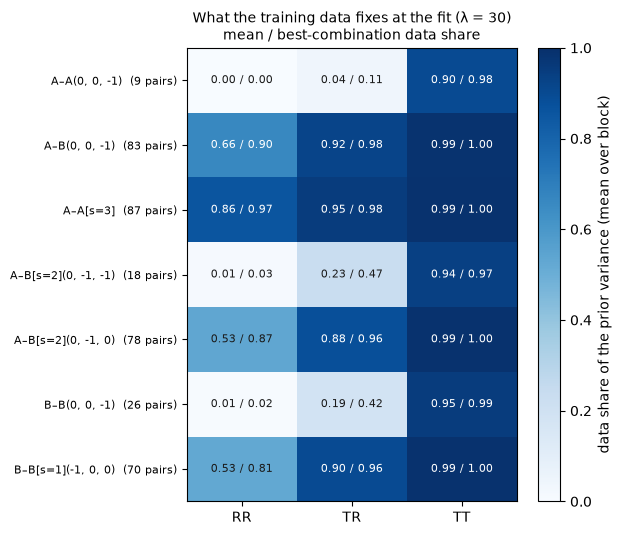

(array([[0.0003, 0.0391, 0.8971],
        [0.6625, 0.9185, 0.9869],
        [0.8559, 0.9528, 0.9895],
        [0.0103, 0.2317, 0.9373],
        [0.533 , 0.8806, 0.9901],
        [0.0061, 0.1863, 0.9509],
        [0.5266, 0.8984, 0.9902]]),
 array([[0.0009, 0.108 , 0.9842],
        [0.9016, 0.9785, 0.9972],
        [0.9691, 0.9805, 0.9967],
        [0.0294, 0.4654, 0.9747],
        [0.8746, 0.9603, 0.9962],
        [0.0178, 0.4157, 0.9899],
        [0.8116, 0.961 , 0.9969]]))

In [36]:
# --- Which blocks of K does the data constrain? (at the fit) ---------------------
# Whitened components of each contact's K at the base point: the 21 independent
# entries of X = W dK W^T (off-diagonal entries scaled by sqrt 2), so that the sum
# of squares of the components is the squared geodesic length of the step.
_COMP_LIST = ([('RR', ij) for ij in [(0,0),(1,1),(2,2),(0,1),(0,2),(1,2)]]
              + [('TR', (i, j)) for i in range(3) for j in range(3, 6)]
              + [('TT', ij) for ij in [(3,3),(4,4),(5,5),(3,4),(3,5),(4,5)]])
# weight 1 for diagonal entries, sqrt(2) for off-diagonal ones (each appears twice in X)
_COMP_W = np.array([1.0 if (b != 'TR' and ij[0] == ij[1]) else np.sqrt(2) for b, ij in _COMP_LIST])
_BLOCKS = ('RR', 'TR', 'TT')

def whitened_component_map(theta0):
    """A (N_PARAMS x N_PARAMS): theta displacement -> whitened K components at theta0.
    Block-diagonal by orbit, and A^T A = metric_at(theta0)."""
    L0 = theta_to_Lmap(theta0); K0, _ = build_K(L0)
    A = np.zeros((N_PARAMS, N_PARAMS))
    for ci, c in enumerate(shell_order):
        W = _tfirst_whitener(K0[c])
        for a in range(N_TRIL):
            E = np.zeros((6, 6)); E[TRIL_I[a], TRIL_J[a]] = 1.0
            X = W @ (E @ L0[c].T + L0[c] @ E.T) @ W.T
            A[ci*N_TRIL:(ci+1)*N_TRIL, ci*N_TRIL + a] = _COMP_W*np.array([X[i, j] for _, (i, j) in _COMP_LIST])
    return A

def block_constraint(fisher, theta0, lam, A=None):
    """Posterior / prior variance of each whitened K component at theta0.

    The prior precision in these coordinates is lam * I (the geodesic prior, locally),
    so ratio = lam * [(F~ + lam I)^-1] with F~ the Fisher information of the data in
    the same coordinates. ratio -> 0: fixed by the data; ratio -> 1: prior only.
    Returns the per-component ratios (n_contacts x 21) and, per contact and block,
    (mean ratio over the block's components, ratio of its best-determined combination)."""
    A = whitened_component_map(theta0) if A is None else A
    Ai = np.linalg.inv(A)
    Ft = Ai.T @ fisher @ Ai
    ratio = lam*np.linalg.inv(0.5*(Ft + Ft.T) + lam*np.eye(N_PARAMS))
    summary = {}
    for ci, c in enumerate(shell_order):
        for b in _BLOCKS:
            ix = [ci*N_TRIL + k for k, (bb, _) in enumerate(_COMP_LIST) if bb == b]
            sub = ratio[np.ix_(ix, ix)]
            summary[(c, b)] = (float(np.mean(np.diag(sub))),
                               float(np.linalg.eigvalsh(0.5*(sub + sub.T)).min()))
    return np.diag(ratio).reshape(N_SHELL, N_TRIL), summary

def plot_block_constraint(summary, title, fname):
    share = np.array([[1 - summary[(c, b)][0] for b in _BLOCKS] for c in shell_order])
    best  = np.array([[1 - summary[(c, b)][1] for b in _BLOCKS] for c in shell_order])
    fig, ax = plt.subplots(figsize=(6.2, 0.55*N_SHELL + 1.6))
    im = ax.imshow(share, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    for i in range(N_SHELL):
        for j in range(3):
            ax.text(j, i, f"{share[i, j]:.2f} / {best[i, j]:.2f}", ha='center', va='center',
                    fontsize=8, color='white' if share[i, j] > 0.6 else '0.1')
    ax.set_xticks(range(3)); ax.set_xticklabels(_BLOCKS)
    ax.set_yticks(range(N_SHELL))
    ax.set_yticklabels([f"{unique[c]['label']}  ({unique[c]['n_contacts']} pairs)" for c in shell_order], fontsize=8)
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, label='data share of the prior variance (mean over block)')
    plt.tight_layout(); plt.savefig(fname, dpi=150, bbox_inches='tight'); plt.show()
    return share, best

_A_fit = whitened_component_map(theta_fit)
_Mchk = metric_at(theta_fit)
print(f"check: max|A^T A - metric_at(theta_fit)| / max|M| = "
      f"{np.abs(_A_fit.T @ _A_fit - _Mchk).max()/np.abs(_Mchk).max():.1e}")
_ratio_fit, _blocks_fit = block_constraint(_Jf.T @ _Jf, theta_fit, LAMBDA_PRIOR, A=_A_fit)

print(f"\nData share of the prior variance, per orbit and block, at the fit "
      f"(λ = {LAMBDA_PRIOR:g}); 'mean' over the block's components / 'best' combination:")
print(f"{'orbit':>20s} " + "".join(f"{b:>16s}" for b in _BLOCKS))
for c in shell_order:
    print(f"{unique[c]['label']:>20s} " + "".join(f"{1-_blocks_fit[(c, b)][0]:8.2f} / {1-_blocks_fit[(c, b)][1]:5.2f}" for b in _BLOCKS))
_avg = {b: np.mean([1 - _blocks_fit[(c, b)][0] for c in shell_order]) for b in _BLOCKS}
print("   average over orbits:  " + "   ".join(f"{b} {_avg[b]:.2f}" for b in _BLOCKS))
plot_block_constraint(_blocks_fit, f'What the training data fixes at the fit (λ = {LAMBDA_PRIOR:g})\n'
                      'mean / best-combination data share',
                      OUT_PREFIX + 'block_constraint_fit.png')

### Halos vs. Mid-Zone: What Each Kind of Observation Constrains

This compares designs of equal size (`DESIGN_N` points), all evaluated at the
true $K$ with the synthetic noise model, so the comparison is about the sampling
alone:

* **halo:** points at $|\mathbf q-\mathbf G|$ uniform in 0.005–0.03 Å⁻¹ around
  random reciprocal-lattice points;
* **mid-zone:** points uniform in the resolution sphere, at least 0.03 Å⁻¹ from any
  reciprocal-lattice point;
* **halo + mid-zone:** half of each;
* **Meisburger-like:** the design of Meisburger et al. (2020). The `N_MEIS_HALOS`
  halos predicted to be brightest (largest $|\mathbf qF(\mathbf G)|^2$) with centres
  between 2.5 and 2.0 Å, each sampled uniformly over its whole reciprocal cell. Its
  points lie beyond `D_MIN_DIFFUSE`, which limits only the synthetic data set.

For each design the cell reports the invariant spectrum $g$ (and how many
directions have $g>1$) and the block data shares defined above, averaged over
orbits. A radius scan repeats the halo-only design with outer radii 0.01, 0.02,
0.03 and 0.05 Å⁻¹. The radii are half those used for 6o2h, because half a reciprocal
cell along $a^*$ is 0.035 Å⁻¹ here.

Close to $\mathbf G$ only the long-wavelength (elastic) limit of the acoustic
branches contributes, and that depends on $K$ through a fixed, small set of
combinations. The measurable count at small radius therefore shows how much of
$K$ the elastic limit alone determines. How the count grows with radius shows
what the dispersion further out adds.

The synthetic training set itself has only a few near-Bragg points, because of
the $1/P$ snapping described earlier, so these designs are generated separately.

                  design  points  median I/σ  g > 1   share RR  share TR  share TT
   halo (0.005–0.03 Å⁻¹)     588        85.5    103       0.23      0.44      0.94
   mid-zone (> 0.03 Å⁻¹)     588        43.5    104       0.21      0.40      0.88
         halo + mid-zone     588        52.8    107       0.24      0.44      0.93
Meisburger-like (400 halos, 2.5–2.0 Å, whole cells)     588        92.1    113       0.26      0.48      0.94

halo-only designs, measurable directions (g > 1) vs outer radius:
   |q - G| in 0.005–0.010 Å⁻¹:  101 of 147
   |q - G| in 0.005–0.020 Å⁻¹:  101 of 147
   |q - G| in 0.005–0.030 Å⁻¹:  102 of 147
   |q - G| in 0.005–0.050 Å⁻¹:  104 of 147


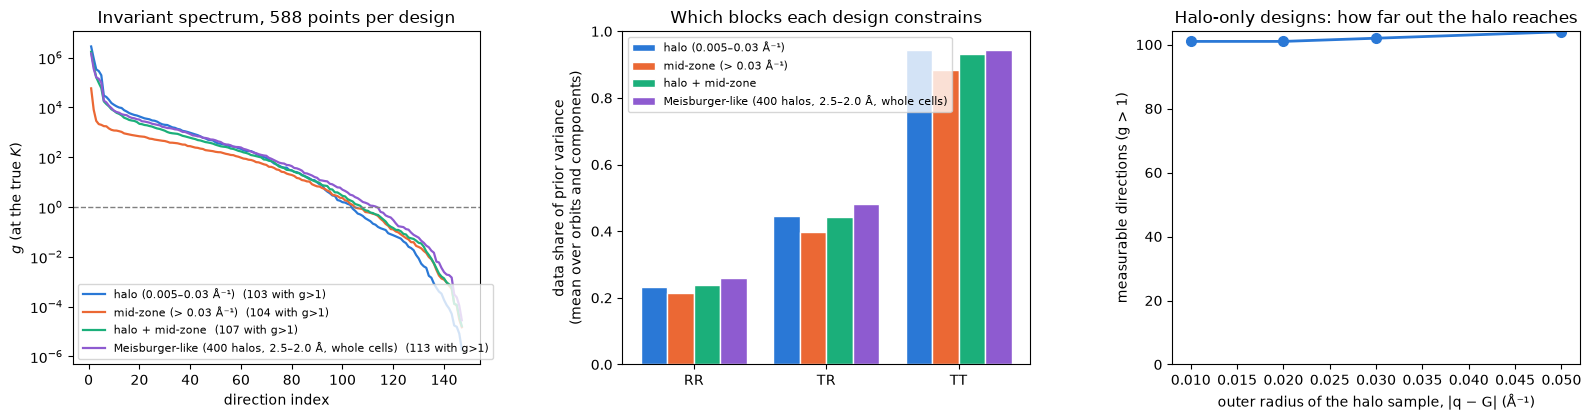

In [37]:
# --- Halos vs mid-zone: what each kind of observation constrains ----------------
# Designs of equal size, evaluated at the TRUE K with the synthetic noise model, so
# the comparison is about the experimental design only (no noise realization, no fit).
DESIGN_N     = max(400, 4*N_PARAMS)
DESIGN_SEED  = 21
HALO_BANDS   = [(0.005, 0.01), (0.005, 0.02), (0.005, 0.03), (0.005, 0.05)]   # Å⁻¹, radius scan
HALO_DESIGN  = (0.005, HALO_R_MAX)
_Binv = np.linalg.inv(B_recip)
_qcut_d = 2*np.pi/D_MIN_DIFFUSE
_hmax_d = [int(np.ceil(L/D_MIN_DIFFUSE)) for L in (cell.a, cell.b, cell.c)]

def _bragg_distance(hkl):
    return np.linalg.norm((hkl - np.round(hkl)) @ B_recip.T, axis=1)

def sample_halo_design(n, r_lo, r_hi, rng):
    """Points at |q - G| uniform in [r_lo, r_hi] Å⁻¹, random direction, around random
    reciprocal-lattice points G inside the resolution sphere."""
    out = []
    while len(out) < n:
        G = np.array([rng.integers(-m, m + 1) for m in _hmax_d], float)
        if not G.any(): continue
        u = rng.standard_normal(3); u /= np.linalg.norm(u)
        q = B_recip @ G + rng.uniform(r_lo, r_hi)*u
        if np.linalg.norm(q) < _qcut_d:
            out.append(_Binv @ q)
    return np.array(out)

def sample_mid_design(n, r_excl, rng):
    """Points uniform in the resolution sphere, at least r_excl Å⁻¹ from any Bragg point."""
    out = []
    while len(out) < n:
        hkl = np.array([rng.uniform(-m, m) for m in _hmax_d])
        if (np.linalg.norm(B_recip @ hkl) < _qcut_d
                and _bragg_distance(hkl[None])[0] >= r_excl):
            out.append(hkl)
    return np.array(out)

def design_fisher(hkl, theta):
    """J^T J at theta for points hkl, with the synthetic noise model."""
    G = G_at_hkl_batch(hkl[:, 0], hkl[:, 1], hkl[:, 2])
    _, Kl = build_K(theta_to_Lmap(theta))
    I = diffuse_intensity_batch(Kl, hkl[:, 0], hkl[:, 1], hkl[:, 2], G_arr=G)
    sig = NOISE_FLOOR + NOISE_SCALE*np.sqrt(np.clip(I, 0, None))
    J = weighted_jacobian(theta, hkl, G, 1.0/sig**2)
    return J.T @ J, I, sig

_rng_d = np.random.default_rng(DESIGN_SEED)
_Mi_t = _sqrtm_inv_sym(metric_at(theta_true))
_A_true = whitened_component_map(theta_true)
_halo = sample_halo_design(DESIGN_N, *HALO_DESIGN, _rng_d)
_mid  = sample_mid_design(DESIGN_N, HALO_DESIGN[1], _rng_d)
# Meisburger et al. (2020): the N_MEIS_HALOS brightest halos (largest |qF|^2 at G) with
# centres between MEIS_D_MAX and MEIS_D_MIN, each sampled over its whole reciprocal
# cell. The window lies beyond D_MIN_DIFFUSE, which only limits the synthetic data
# set; the transform extends to D_MIN_TRANSFORM.
N_MEIS_HALOS, MEIS_D_MIN, MEIS_D_MAX = 400, 2.0, 2.5

def sample_meisburger_design(n, rng, n_halos=N_MEIS_HALOS, d_lo=MEIS_D_MIN, d_hi=MEIS_D_MAX):
    hm = [int(np.floor(L/d_lo)) for L in (cell.a, cell.b, cell.c)]
    H = np.stack(np.meshgrid(*[np.arange(-m, m + 1) for m in hm], indexing='ij'), -1).reshape(-1, 3)
    d = 2*np.pi/np.maximum(np.linalg.norm(H @ B_recip.T, axis=1), 1e-12)
    H = H[(d >= d_lo) & (d <= d_hi)].astype(float)
    Gv = G_at_hkl_batch(H[:, 0], H[:, 1], H[:, 2])
    coupling = np.sum(np.abs(sum(Gv[:, 6*b + 3:6*b + 6] for b in range(N_BODY)))**2, axis=1)   # |q F_cell(G)|^2
    top = H[np.argsort(coupling)[::-1][:n_halos]]
    out = []
    while len(out) < n:
        p = top[rng.integers(len(top))] + rng.uniform(-0.5, 0.5, 3)   # anywhere in its cell
        if _bragg_distance(p[None])[0] >= HALO_DESIGN[0]:
            out.append(p)
    return np.array(out), len(top)

_meis, _n_meis = sample_meisburger_design(DESIGN_N, _rng_d)
DESIGNS = {f'halo ({HALO_DESIGN[0]}–{HALO_DESIGN[1]} Å⁻¹)': _halo,
           f'mid-zone (> {HALO_DESIGN[1]} Å⁻¹)': _mid,
           'halo + mid-zone': np.vstack([_halo[:DESIGN_N//2], _mid[:DESIGN_N//2]]),
           f'Meisburger-like ({_n_meis} halos, {MEIS_D_MAX}–{MEIS_D_MIN} Å, whole cells)': _meis}

_des = {}
print(f"{'design':>24s} {'points':>7s} {'median I/σ':>11s} {'g > 1':>6s} "
      + "".join(f"{'share ' + b:>10s}" for b in _BLOCKS))
for name, hkl in DESIGNS.items():
    F, I, sig = design_fisher(hkl, theta_true)
    g = np.maximum(np.linalg.eigvalsh(_Mi_t @ F @ _Mi_t)[::-1], 0.0)
    _, summ = block_constraint(F, theta_true, LAMBDA_PRIOR, A=_A_true)
    share = {b: np.mean([1 - summ[(c, b)][0] for c in shell_order]) for b in _BLOCKS}
    _des[name] = dict(g=g, summary=summ, share=share, F=F)
    print(f"{name:>24s} {len(hkl):7d} {np.median(I/sig):11.1f} {int(np.sum(g > 1)):6d} "
          + "".join(f"{share[b]:10.2f}" for b in _BLOCKS))

_scan_counts = []
for r_lo, r_hi in HALO_BANDS:
    F, _, _ = design_fisher(sample_halo_design(DESIGN_N, r_lo, r_hi, _rng_d), theta_true)
    g = np.linalg.eigvalsh(_Mi_t @ F @ _Mi_t)
    _scan_counts.append(int(np.sum(g > 1)))
print("\nhalo-only designs, measurable directions (g > 1) vs outer radius:")
for (r_lo, r_hi), n_ in zip(HALO_BANDS, _scan_counts):
    print(f"   |q - G| in {r_lo:.3f}–{r_hi:.3f} Å⁻¹:  {n_:3d} of {N_PARAMS}")

_dcols = ['#2a78d6', '#eb6834', '#1baf7a', '#8e5bd0']
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))
for (name, d), col in zip(_des.items(), _dcols):
    ax[0].semilogy(np.arange(1, N_PARAMS + 1), np.maximum(d['g'], 1e-12), '-', lw=1.6,
                   color=col, label=f"{name}  ({int(np.sum(d['g'] > 1))} with g>1)")
ax[0].axhline(1.0, color='0.5', ls='--', lw=1)
ax[0].set_xlabel('direction index'); ax[0].set_ylabel('$g$ (at the true $K$)')
ax[0].set_title(f'Invariant spectrum, {DESIGN_N} points per design'); ax[0].legend(fontsize=8)
_x = np.arange(3); _wb = 0.8/len(_des)
for k, ((name, d), col) in enumerate(zip(_des.items(), _dcols)):
    ax[1].bar(_x + (k - (len(_des) - 1)/2)*_wb, [d['share'][b] for b in _BLOCKS], width=_wb, color=col,
              edgecolor='white', linewidth=1, label=name)
ax[1].set_xticks(_x); ax[1].set_xticklabels(_BLOCKS); ax[1].set_ylim(0, 1)
ax[1].set_ylabel('data share of prior variance\n(mean over orbits and components)')
ax[1].set_title('Which blocks each design constrains'); ax[1].legend(fontsize=8)
ax[2].plot([b[1] for b in HALO_BANDS], _scan_counts, 'o-', color='#2a78d6', lw=2, ms=7)
ax[2].set_xlabel('outer radius of the halo sample, |q − G| (Å⁻¹)')
ax[2].set_ylabel('measurable directions (g > 1)'); ax[2].set_ylim(0, None)
ax[2].set_title('Halo-only designs: how far out the halo reaches')
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'design_comparison.png', dpi=150); plt.show()

### The Elastic Tensor: What Halos and Mid-Zone Constrain

$D(\mathbf q)$ is the Fourier series of the rigid-body force constants, so every halo
samples the same small-$\delta\mathbf q$ expansion of $D$. Its second-order
translational term, with all internal degrees of freedom relaxed, is the elastic
tensor.

**Computation** (`elastic_tensor`). Under a homogeneous strain $\varepsilon$ every
body's centre of mass moves affinely, $\mathbf v_b=\varepsilon\,\mathbf r_{{\rm cm},b}$ (and
$\varepsilon(\mathbf r_{{\rm cm},b}+\mathbf R_{\mathbf n})$ for its image in cell $\mathbf n$). On
top of that the internal coordinates $\xi$, the rotations $\boldsymbol\omega_b$ and
extra shifts $\delta\mathbf v_b$ of all eight bodies, are free. Member $m$ is deformed by
$\Delta_m=P_m\xi+Q_me$ (Voigt strain $e$), and minimizing
$\tfrac12\sum_m\Delta_m^{\mathsf T}K_m\Delta_m$ over $\xi$ gives

$$C=\frac1{V_{\rm cell}}\Bigl[\textstyle\sum Q^{\mathsf T}KQ-\bigl(\sum Q^{\mathsf T}KP\bigr)
\bigl(\sum P^{\mathsf T}KP\bigr)^{+}\bigl(\sum P^{\mathsf T}KQ\bigr)\Bigr].$$

The pseudo-inverse removes the uniform translation, which deforms nothing. With
eight bodies the relaxation includes the sublattice shifts as well as the
rotations, so it is a larger effect than in P1. The check is the same:
$m_{\rm cell}\,\omega^2=V_{\rm cell}\,\mathrm{eig}\,\Gamma(\mathbf q)$ for the three acoustic
branches of $D(\mathbf q)$ at small $\mathbf q$, with $m_{\rm cell}$ the mass of the cell.

**Reported quantities.** As for 6o2h: the 21 components $C_{IJ}$ in the lab frame,
the six Kelvin moduli, and the Voigt bulk and shear moduli. For P4₃ (Laue class
4/m) $C$ has 7 independent components, and the components that symmetry forces to
vanish or to be equal are reported as a check. Posterior and prior standard
deviations and data shares follow from $\partial C/\partial\theta$ as in the P1
notebook.

elastic tensor vs. small-q acoustic dispersion of D(q): max relative difference 1.1e-06 over 6 directions
tetragonal (4/m) form of C: largest violation 1.6e-15 of the largest component
Elastic tensor (GPa at 300 K; lab Cartesian frame; internal coordinates relaxed)
internal relaxation (rotations and sublattice shifts) softens the true tensor by 28.3% (norm of C_relaxed - C_clamped)
whole-tensor error ||C - C_true|| / ||C_true||:  prior 31.8%   fit 0.1%

                  truth    prior      fit  fit err  post. sd  |err|/sd
Kelvin 1         10.893    6.413   10.902     0.1%      0.2%      0.44
Kelvin 2          8.363    6.273    8.361    -0.0%      0.3%      0.09
Kelvin 3          6.232    6.086    6.233     0.0%      0.2%      0.12
Kelvin 4          4.665    3.993    4.667     0.0%      0.1%      0.45
Kelvin 5          4.665    3.993    4.667     0.0%      0.1%      0.45
Kelvin 6          3.714    3.050    3.709    -0.1%      0.1%      1.09
K_V (bulk)        2.635    1.751    2.632    

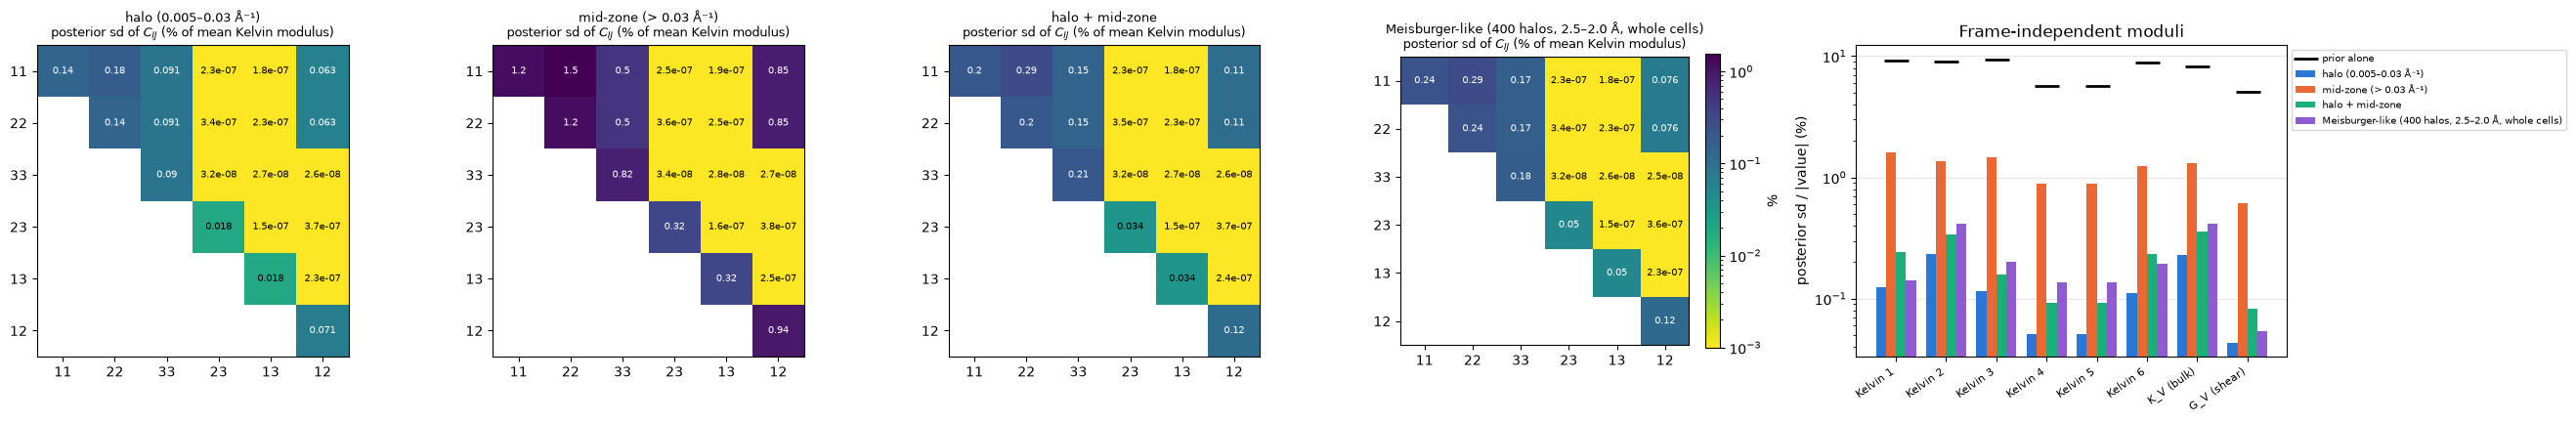

In [38]:
# --- Elastic tensor of the multi-body rigid lattice ------------------------------------
_V_CELL  = (2*np.pi)**3/abs(np.linalg.det(B_recip))          # Å^3
_KT_GPA  = 1.380649e-23*TEMPERATURE/1e-30/1e9                 # 1 k_BT/Å^3 in GPa
_VOIGT   = [(0, 0), (1, 1), (2, 2), (1, 2), (0, 2), (0, 1)]
_VIDX    = np.array([[0, 5, 4], [5, 1, 3], [4, 3, 2]])        # (i,j) -> Voigt index
_VLAB    = ['11', '22', '33', '23', '13', '12']
_MANDEL  = np.diag([1, 1, 1, np.sqrt(2), np.sqrt(2), np.sqrt(2)])

def _strain_from_voigt(e):
    E = np.zeros((3, 3))
    for a, (i, j) in enumerate(_VOIGT):
        if i == j: E[i, i] = e[a]
        else:      E[i, j] = E[j, i] = 0.5*e[a]
    return E

def _member_strain_maps():
    """Delta_m = P_m xi + Q_m e: xi the internal coordinates (6 per body), e the Voigt strain."""
    maps = []
    for M in MEMBERS:
        a, b = M['a'], M['b']
        P = np.zeros((6, N_DOF)); P[:, 6*a:6*a + 6] += M['Ta']; P[:, 6*b:6*b + 6] -= M['Tb']
        ra, rb = BODIES[a]['com'], BODIES[b]['com'] + M['Rn']
        Q = np.zeros((6, 6))
        for k in range(6):
            E = _strain_from_voigt(np.eye(6)[k])
            Q[:, k] = M['Ta'] @ np.r_[0, 0, 0, E @ ra] - M['Tb'] @ np.r_[0, 0, 0, E @ rb]
        maps.append((P, Q))
    return maps
_STRAIN_MAPS = _member_strain_maps()

def elastic_tensor(K_lab, relax=True):
    """6x6 Voigt stiffness in k_BT/Å^3 (x _KT_GPA for GPa), lab frame. relax=False clamps
    every internal coordinate (no rotations, no sublattice shifts)."""
    App = np.zeros((N_DOF, N_DOF)); Apq = np.zeros((N_DOF, 6)); Aqq = np.zeros((6, 6))
    for (P, Q), K in zip(_STRAIN_MAPS, K_lab):
        App += P.T @ K @ P; Apq += P.T @ K @ Q; Aqq += Q.T @ K @ Q
    C = Aqq - Apq.T @ np.linalg.lstsq(App, Apq, rcond=1e-12)[0] if relax else Aqq
    return 0.5*(C + C.T)/_V_CELL

def christoffel(Cv, q):
    G = np.zeros((3, 3))
    for i in range(3):
        for k in range(3):
            G[i, k] = sum(Cv[_VIDX[i, j], _VIDX[k, l]]*q[j]*q[l] for j in range(3) for l in range(3))
    return G

def elastic_summary(Cv):
    comps = np.array([Cv[i, j] for i in range(6) for j in range(i, 6)])
    kelvin = np.sort(np.linalg.eigvalsh(_MANDEL @ Cv @ _MANDEL))[::-1]
    KV = (Cv[0, 0] + Cv[1, 1] + Cv[2, 2] + 2*(Cv[0, 1] + Cv[0, 2] + Cv[1, 2]))/9
    GV = ((Cv[0, 0] + Cv[1, 1] + Cv[2, 2]) - (Cv[0, 1] + Cv[0, 2] + Cv[1, 2])
          + 3*(Cv[3, 3] + Cv[4, 4] + Cv[5, 5]))/15
    return np.r_[comps, kelvin, KV, GV]
_COMP_LAB = [f'C{_VLAB[i]},{_VLAB[j]}' for i in range(6) for j in range(i, 6)]
_SUMM_LAB = _COMP_LAB + [f'Kelvin {k + 1}' for k in range(6)] + ['K_V (bulk)', 'G_V (shear)']
_N_COMP   = len(_COMP_LAB)

def elastic_of_theta(theta):
    return elastic_summary(elastic_tensor(build_K(theta_to_Lmap(theta))[1]))

def elastic_jacobian(theta, rel_eps=1e-5):
    theta = np.asarray(theta, float)
    scale = max(np.abs(theta).mean(), 1e-12)
    Jc = np.zeros((len(elastic_of_theta(theta)), len(theta)))
    for j in range(len(theta)):
        h = rel_eps*max(abs(theta[j]), 1e-3*scale)
        tp = theta.copy(); tp[j] += h
        tm = theta.copy(); tm[j] -= h
        Jc[:, j] = (elastic_of_theta(tp) - elastic_of_theta(tm))/(2*h)
    return Jc

def elastic_constraint(Jc, F, P_prec):
    Cpost = np.linalg.inv(F + P_prec); Cpr = np.linalg.inv(P_prec)
    vpost = np.einsum('ij,jk,ik->i', Jc, Cpost, Jc)
    vpr   = np.einsum('ij,jk,ik->i', Jc, Cpr, Jc)
    return np.sqrt(np.maximum(vpost, 0)), np.sqrt(np.maximum(vpr, 0)), 1 - vpost/np.maximum(vpr, 1e-300)

# --- Check against the acoustic dispersion of D(q) itself --------------------------------
_K_chk = K_LAB_PRIOR
_C_chk = elastic_tensor(_K_chk)
_errs = []
for _qh in np.random.default_rng(0).standard_normal((6, 3)):
    _qh /= np.linalg.norm(_qh); _s = 1e-4
    _D = dynamical_matrix_batch((_s*_qh)[None], unique, _K_chk)[0]
    _w2 = np.sort(np.linalg.eigvalsh(Msq_inv @ _D @ Msq_inv.T))[:3]/_s**2
    _w2c = np.sort(np.linalg.eigvalsh(christoffel(_C_chk, _qh)))*_V_CELL/m_cell
    _errs.append(np.max(np.abs(_w2 - _w2c)/_w2c))
print(f"elastic tensor vs. small-q acoustic dispersion of D(q): max relative difference "
      f"{max(_errs):.1e} over 6 directions")
assert max(_errs) < 1e-3, "elastic tensor disagrees with the acoustic branches of D(q)"
# Laue class 4/m: C11 = C22, C44 = C55, C13 = C23, C16 = -C26, and C14 = C15 = C24 = C25
# = C34 = C35 = C36 = C46 = C56 = 0 (Voigt indices 1..6 = 11, 22, 33, 23, 13, 12).
_Cg = _C_chk/np.abs(_C_chk).max()
_tet = [abs(_Cg[0, 0] - _Cg[1, 1]), abs(_Cg[3, 3] - _Cg[4, 4]), abs(_Cg[0, 2] - _Cg[1, 2]),
        abs(_Cg[0, 5] + _Cg[1, 5])] + [abs(_Cg[i, j]) for i, j in
        [(0, 3), (0, 4), (1, 3), (1, 4), (2, 3), (2, 4), (2, 5), (3, 5), (4, 5)]]
if SG.number in range(75, 89):
    print(f"tetragonal (4/m) form of C: largest violation {max(_tet):.1e} of the largest component")
    assert max(_tet) < 1e-8, "the elastic tensor does not have the Laue symmetry"

def relaxation_effect(K_lab):
    Cr, Cc = elastic_tensor(K_lab), elastic_tensor(K_lab, relax=False)
    return np.linalg.norm(_MANDEL @ (Cr - Cc) @ _MANDEL)/np.linalg.norm(_MANDEL @ Cc @ _MANDEL)

from matplotlib.colors import LogNorm

# --- 1. The elastic tensor of the fit, against the truth and the prior ------------
_Cv = {lab: elastic_tensor(K)*_KT_GPA for lab, K in
       [('truth', K_LAB_TRUE), ('prior', K_LAB_PRIOR), ('fit', K_LAB_FIT)]}
_Es = {lab: elastic_summary(C) for lab, C in _Cv.items()}
_Jc_fit = elastic_jacobian(theta_fit)*_KT_GPA
_sd_fit, _, _ = elastic_constraint(_Jc_fit, _Jf.T @ _Jf, LAMBDA_PRIOR*parameter_metric(theta_fit))
_sd_fit *= np.sqrt(chi2_dof) if INFLATE_BY_CHI2 else 1.0
_nrm = lambda C: np.linalg.norm(_MANDEL @ C @ _MANDEL)
print(f"Elastic tensor (GPa at {TEMPERATURE:g} K; lab Cartesian frame; internal coordinates relaxed)")
print(f"internal relaxation (rotations and sublattice shifts) softens the true tensor by "
      f"{100*relaxation_effect(K_LAB_TRUE):.1f}% (norm of C_relaxed - C_clamped)")
print(f"whole-tensor error ||C - C_true|| / ||C_true||:  prior {_nrm(_Cv['prior'] - _Cv['truth'])/_nrm(_Cv['truth']):.1%}"
      f"   fit {_nrm(_Cv['fit'] - _Cv['truth'])/_nrm(_Cv['truth']):.1%}")
print(f"\n{'':14s} {'truth':>8s} {'prior':>8s} {'fit':>8s} {'fit err':>8s} {'post. sd':>9s} {'|err|/sd':>9s}")
for i in range(_N_COMP, len(_SUMM_LAB)):
    t, p, f, s = _Es['truth'][i], _Es['prior'][i], _Es['fit'][i], _sd_fit[i]
    print(f"{_SUMM_LAB[i]:14s} {t:8.3f} {p:8.3f} {f:8.3f} {100*(f-t)/abs(t):7.1f}% {100*s/abs(f):8.1f}% "
          f"{abs(f-t)/max(s, 1e-300):9.2f}")
print("   Kelvin moduli: eigenvalues of the Mandel form of C (frame-independent)")
print("   post. sd: posterior standard deviation from the training set, relative to the fit")

# --- 2. Which components does each design constrain? (at the true K) -------------
_Jc_true = elastic_jacobian(theta_true)*_KT_GPA
_P_true  = LAMBDA_PRIOR*metric_at(theta_true)          # same prior precision as the block shares
_el = {}
for name, hkl in DESIGNS.items():
    F = _des[name]['F'] if 'F' in _des.get(name, {}) else design_fisher(hkl, theta_true)[0]
    _el[name] = elastic_constraint(_Jc_true, F, _P_true)
_sd_prior = next(iter(_el.values()))[1]
_E_true = _Es['truth']

_scale = np.mean(np.abs(_E_true[_N_COMP:_N_COMP+6]))       # mean Kelvin modulus, a common scale
def _rel(i, sd):
    """Components: sd relative to the mean Kelvin modulus (they can be near zero).
    Moduli: sd relative to their own value."""
    return sd/(_scale if i < _N_COMP else abs(_E_true[i]))
print(f"\nPer design ({DESIGN_N} points each, at the true K, λ = {LAMBDA_PRIOR:g}): posterior sd, "
      f"and data share 1 - var_post/var_prior")
print(f"   components: sd relative to the mean Kelvin modulus ({_scale:.3g} GPa); moduli: relative to their value")
_hdr = "".join(f"{n.split(' (')[0][:16]:>19s}" for n in DESIGNS)
print(f"{'':14s} {'truth':>8s} {'prior sd':>9s}{_hdr}")
for i in range(len(_SUMM_LAB)):
    if i == _N_COMP: print()
    row = "".join(f"{100*_rel(i, _el[n][0][i]):10.2f}% {_el[n][2][i]:7.3f}" for n in DESIGNS)
    print(f"{_SUMM_LAB[i]:14s} {_E_true[i]:8.3f} {100*_rel(i, _sd_prior[i]):8.1f}%{row}")

_band_rows = []
for r_lo, r_hi in HALO_BANDS:
    F, _, _ = design_fisher(sample_halo_design(DESIGN_N, r_lo, r_hi, np.random.default_rng(DESIGN_SEED + 1)), theta_true)
    sd, _, sh = elastic_constraint(_Jc_true, F, _P_true)
    _band_rows.append((r_hi, sh[:_N_COMP].mean(), np.median(sd[_N_COMP:_N_COMP+6]/np.abs(_E_true[_N_COMP:_N_COMP+6]))))
print("\nhalo-only designs vs outer radius: mean data share over the 21 components, median Kelvin-modulus sd")
for r_hi, sh, sd in _band_rows:
    print(f"   |q - G| to {r_hi:.2f} Å⁻¹:  share {sh:.3f}   Kelvin sd {100*sd:.2f}%")

# --- figure ------------------------------------------------------------------------
_nd = len(DESIGNS)
fig, ax = plt.subplots(1, _nd + 1, figsize=(5*_nd + 6.5, 4.4), gridspec_kw={'width_ratios': [1]*_nd + [1.35]})
_iu = [(i, j) for i in range(6) for j in range(i, 6)]
_rel_maps = {}
for name in DESIGNS:
    Mh = np.full((6, 6), np.nan)
    for (i, j), v in zip(_iu, 100*_el[name][0][:_N_COMP]/_scale): Mh[i, j] = v
    _rel_maps[name] = Mh
_vals = np.concatenate([m[np.isfinite(m)] for m in _rel_maps.values()])
_norm = LogNorm(vmin=max(_vals.min(), 1e-3), vmax=_vals.max())
for k, name in enumerate(DESIGNS):
    Mh = _rel_maps[name]
    im = ax[k].imshow(Mh, norm=_norm, cmap='viridis_r')
    for (i, j) in _iu:
        ax[k].text(j, i, f'{Mh[i, j]:.2g}', ha='center', va='center', fontsize=7,
                   color='black' if _norm(Mh[i, j]) < 0.5 else 'white')
    ax[k].set_xticks(range(6)); ax[k].set_xticklabels(_VLAB)
    ax[k].set_yticks(range(6)); ax[k].set_yticklabels(_VLAB)
    ax[k].set_title(f'{name}\nposterior sd of $C_{{IJ}}$ (% of mean Kelvin modulus)', fontsize=9)
plt.colorbar(im, ax=ax[_nd - 1], fraction=0.046, label='%')
ax[-1].set_axisbelow(True); ax[-1].grid(axis='y', which='major', color='0.9')
_labs = _SUMM_LAB[_N_COMP:]; _x = np.arange(len(_labs)); _wb = 0.8/_nd
for k, (name, col) in enumerate(zip(DESIGNS, ['#2a78d6', '#eb6834', '#1baf7a', '#8e5bd0'])):
    ax[-1].bar(_x + (k - (_nd - 1)/2)*_wb, 100*_el[name][0][_N_COMP:]/np.abs(_E_true[_N_COMP:]), width=_wb,
               color=col, label=name)
ax[-1].plot(_x, 100*_sd_prior[_N_COMP:]/np.abs(_E_true[_N_COMP:]), 'k_', ms=18, mew=2, label='prior alone')
ax[-1].set_yscale('log'); ax[-1].set_xticks(_x); ax[-1].set_xticklabels(_labs, rotation=35, ha='right', fontsize=8)
ax[-1].set_ylabel('posterior sd / |value| (%)'); ax[-1].set_title('Frame-independent moduli')
ax[-1].legend(fontsize=7, loc='upper left', bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'elastic_constraint.png', dpi=150); plt.show()

### What "Recovered Fraction" Means

In the linear-Gaussian approximation, with data precision $F=J^{\mathsf T}J$ and
prior precision $P=\lambda M$ centred at $\theta_{\rm prior}$, the MAP estimate
is

$$\hat\theta=(F+P)^{-1}\bigl(F\theta_{\rm true}+P\theta_{\rm prior}\bigr)
\;\Longrightarrow\;
\hat\theta-\theta_{\rm prior}=(F+P)^{-1}F\,\delta,
\qquad \delta=\theta_{\rm true}-\theta_{\rm prior}.$$

Along a generalized eigendirection ($Fv=fPv$) this is $\frac{f}{1+f}\delta$, and
the remaining error is $\frac{1}{1+f}\delta$. So $f=1$ lands halfway, $f=9$
recovers 90%, and $f\to0$ stays at the prior. This is the bias of the regularized
estimator and is present with noiseless data. Noise adds scatter on top of it.

The cell tests the relation directly. It displaces the prior along single
eigendirections with $f$ near $10^4,10^2,10,1,10^{-1},10^{-2}$ (geodesic size
`SHRINK_D`), generates noiseless data, refits, and compares the recovered
projection $\langle\delta_{\rm fit},\delta\rangle_M/\langle\delta,\delta\rangle_M$
(inner product in $M$ at the prior, $\langle a,b\rangle_M=a^{\mathsf T}Mb$) with $f/(1+f)$.
The geodesic recovery $1-d_{\rm truth\to fit}/d_{\rm prior\to truth}$ is shown alongside. It differs from the projection where
the fit leaves the line from prior to truth.

 dir          f  predicted   observed   geodesic        R
   2   1.32e+04     100.0%     100.0%      99.8%   0.0000
  30   9.58e+01      99.0%      99.0%      98.6%   0.0000
  75   9.75e+00      90.7%      90.6%      90.4%   0.0001
  97   1.00e+00      50.1%      48.5%      48.0%   0.0002
 115   1.01e-01       9.2%       9.3%       9.2%   0.0001
 129   1.02e-02       1.0%       1.0%       1.1%   0.0000


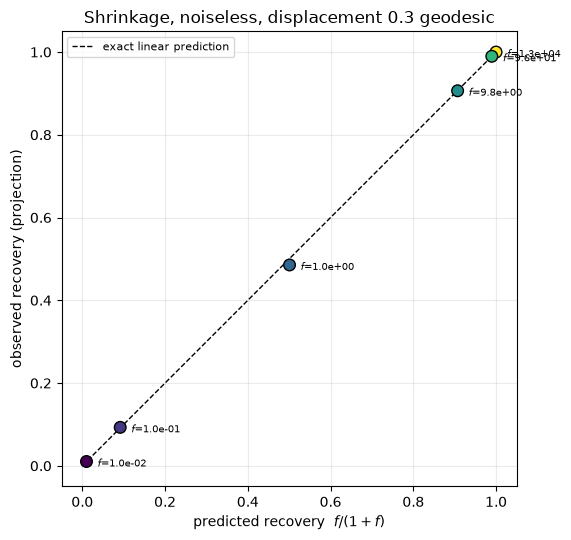


max |observed - predicted| = 0.015
Agreement confirms the linearization holds over a displacement of this
size. Departures grow with SHRINK_D, since f is a property of the
curvature at the prior and the model is not globally quadratic.
The geodesic column is the same quantity measured the way the distance
tables measure it; it differs from the projection wherever the fit leaves
the line joining prior to truth.


In [39]:
# --- Does the model actually shrink by f/(1+f)? ---------------------------
# One perturbation per eigendirection, spanning the spectrum. Noiseless data, so
# what is measured is the shrinkage alone with no variance mixed in.
SHRINK_D = 0.30      # geodesic size of each test displacement

_probe = []
for _target in [1e4, 1e2, 1e1, 1.0, 1e-1, 1e-2]:
    _j = int(np.argmin(np.abs(np.log10(np.maximum(_f, 1e-300)) - np.log10(_target))))
    if _j not in _probe:
        _probe.append(_j)

print(f"{'dir':>4s} {'f':>10s} {'predicted':>10s} {'observed':>10s} "
      f"{'geodesic':>10s} {'R':>8s}")
_pred, _obs = [], []
_M_prior = metric_at(THETA_PRIOR)
for _j in _probe:
    _v = _DIRS[:, _j]/np.linalg.norm(_DIRS[:, _j])
    _a = scale_to_geodesic(_v, SHRINK_D)
    _th_t = THETA_PRIOR + _a*_v
    _, _Kt = build_K(theta_to_Lmap(_th_t))
    _I = diffuse_intensity_batch(_Kt, q_train[:,0], q_train[:,1], q_train[:,2],
                                 G_arr=G_train)            # noiseless
    _th_f, _, _, _, _, _ = refine(THETA_PRIOR, (q_train, G_train, _I, w_train),
                                  max_block=30, verbose=False)
    _d_t, _d_f = _th_t - THETA_PRIOR, _th_f - THETA_PRIOR
    # projection of the recovered step onto the displacement, in the metric M at
    # the prior (the inner product in which f was defined): the exact linear
    # analogue of f/(1+f)
    _proj = float((_d_f @ _M_prior @ _d_t)/(_d_t @ _M_prior @ _d_t))
    # and the same thing with geodesic distances, which differs once the model
    # is nonlinear or the fit leaves the line from prior to truth
    _dpt = geodesic_total(THETA_PRIOR, _th_t)
    _dtf = geodesic_total(_th_t, _th_f)
    _geo = 1.0 - _dtf/max(_dpt, 1e-300)
    _R, _, _ = fit_stats(build_K(theta_to_Lmap(_th_f))[1], q_train, G_train, _I)
    _pred.append(_f[_j]/(1+_f[_j])); _obs.append(_proj)
    print(f"{_j:4d} {_f[_j]:10.2e} {_pred[-1]:10.1%} {_proj:10.1%} {_geo:10.1%} {_R:8.4f}")

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='exact linear prediction')
ax.scatter(_pred, _obs, s=70, c=np.log10(np.maximum([_f[j] for j in _probe], 1e-300)),
           cmap='viridis', edgecolor='k', zorder=5)
for p, o, j in zip(_pred, _obs, _probe):
    ax.annotate(f'$f$={_f[j]:.1e}', (p, o), textcoords='offset points',
                xytext=(8, -4), fontsize=7)
ax.set_xlabel(r'predicted recovery  $f/(1+f)$')
ax.set_ylabel('observed recovery (projection)')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05); ax.set_aspect('equal')
ax.grid(alpha=0.25); ax.legend(fontsize=8)
ax.set_title(f'Shrinkage, noiseless, displacement {SHRINK_D} geodesic')
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'shrinkage_check.png', dpi=150); plt.show()

print(f"\nmax |observed - predicted| = {np.max(np.abs(np.array(_obs)-np.array(_pred))):.3f}")
print("Agreement confirms the linearization holds over a displacement of this")
print("size. Departures grow with SHRINK_D, since f is a property of the")
print("curvature at the prior and the model is not globally quadratic.")
print("The geodesic column is the same quantity measured the way the distance")
print("tables measure it; it differs from the projection wherever the fit leaves")
print("the line joining prior to truth.")

## Watching the Band Structure Converge

The true band structure (thick grey) and the band structure at up to 60 evenly
spaced iterates of the main refinement (blue), along the same Γ–X–M–Γ–Z–R–A–Z path.
Each frame is rasterized and discarded as it is made. The acoustic branches, which
dominate the intensity, are expected to settle before the optic branches.

In [40]:
freqs_true_bs = bandstructure_freqs(K_LAB_TRUE)
ymax = max(freqs_true_bs.max(), bandstructure_freqs(K_LAB_FIT).max())*1.15

frame_idx = np.unique(np.linspace(0, len(theta_history)-1,
                                  min(60, len(theta_history))).astype(int))

legend_handles = [Line2D([0],[0], color='0.6', lw=3.5, label='Ground truth'),
                  Line2D([0],[0], color='steelblue', lw=1.3, label='Current fit')]

images_bs = []
for fi in frame_idx:
    _, K_lab_fi = build_K(theta_to_Lmap(theta_history[fi]))
    freqs_fi = bandstructure_freqs(K_lab_fi)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, freqs_true_bs, color='0.6', lw=2.5, zorder=1)
    ax.plot(x, freqs_fi, color='steelblue', lw=0.8, zorder=2)
    for ti in tick_idx: ax.axvline(x[ti], color='k', lw=0.7)
    ax.set_xticks([x[ti] for ti in tick_idx]); ax.set_xticklabels(path_labels)
    ax.set_ylabel('Frequency (THz)'); ax.set_xlim(x[0], x[-1]); ax.set_ylim(0, ymax)
    ax.set_title(f'Band-structure convergence — iteration {fi}/{len(theta_history)-1}')
    ax.legend(handles=legend_handles, loc='upper right', fontsize=8)
    plt.tight_layout()
    images_bs.append(fig_to_image(fig))
    plt.close(fig)

imageio.mimsave(OUT_PREFIX + 'band_structure_convergence.gif', images_bs, fps=8, loop=0)
del images_bs; gc.collect()
print(f"Saved {OUT_PREFIX}band_structure_convergence.gif ({len(frame_idx)} frames from "
      f"{len(theta_history)} iterations)")

Saved synthetic_7tx0_band_structure_convergence.gif (17 frames from 17 iterations)


### Prior, Fit, and Truth Side by Side

The same $(h,k)$ plane (at $l$ = `L_PANEL`) from the prior, fitted and true
stiffnesses, on a shared colour scale. $G$ does not depend on $K$, so it is
computed once for the plane and reused for all three panels.

Because the log maps are dominated by $|G|^2$, which is common to all three, the
cell also shows:

* the ratio maps $I/I_{\rm truth}-1$ on a linear scale, with their histograms;
* $CC$ on $I$ and on $\log I$ (the latter weights the plane more evenly than the
  halo peaks).

Setting `L_PANEL = 0.5` shows a plane with no Bragg positions.

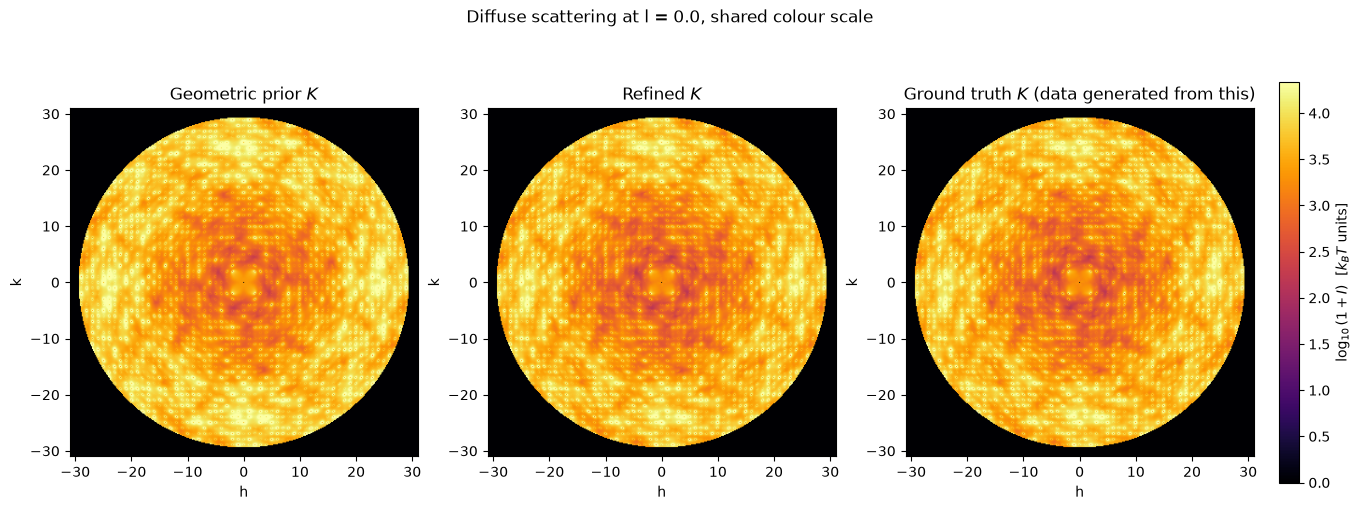


pairwise correlation over 98292 plane pixels:
   prior  vs truth :  CC = 0.987204
   fit    vs truth :  CC = 0.999985
   prior  vs fit   :  CC = 0.987435

If prior-vs-truth is already very high, the refinement had little room to
move the pattern -- which is the sloppiness of the model seen from the
observable side rather than from the parameter side.


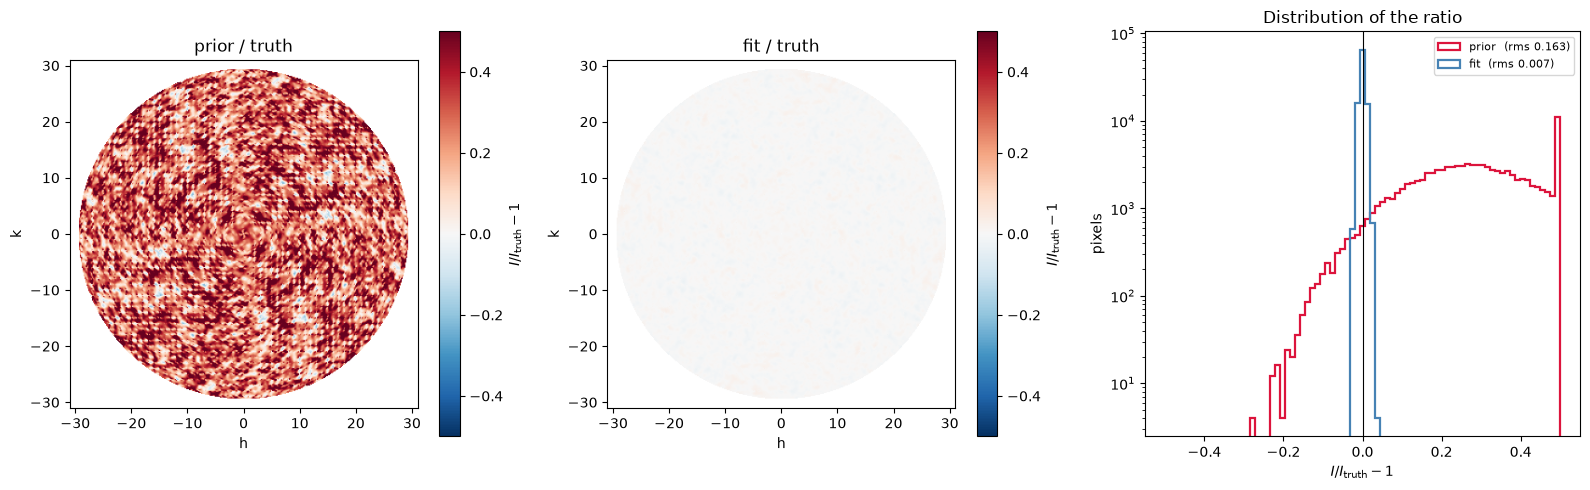

prior /truth: rms deviation  0.1629, 90th percentile |dev|  0.4984
fit   /truth: rms deviation  0.0070, 90th percentile |dev|  0.0116

This is the comparison to read, not the log maps: the log maps are
dominated by |G(q)|^2, which is the same for all three K, so they look
alike however far apart the stiffnesses are.

CC on log I over 98292 pixels (halo dominance removed):
   prior  vs truth : 0.990640
   fit    vs truth : 0.999972


In [41]:
# --- Prior / fit / truth on one colour scale -------------------------------
L_PANEL = 0.0

_G_panel = G_PLANE0 if L_PANEL == 0.0 else (G_PLANE5 if L_PANEL == 0.5 else None)
_maps = {}
for lab, K in [('prior', K_LAB_PRIOR), ('fit', K_LAB_FIT), ('truth', K_LAB_TRUE)]:
    _hp, _kp, _maps[lab], _hmax, _kmax, _G_panel = compute_diffuse_map(K, L_PANEL, G_all=_G_panel)

_pos = np.concatenate([m[m > 0] for m in _maps.values()])
_vmax = np.percentile(_pos, 97)
_ext = [_hp[0], _hp[-1], _kp[0], _kp[-1]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))
for ax, lab, title in zip(axes, ['prior', 'fit', 'truth'],
                          ['Geometric prior $K$', 'Refined $K$',
                           'Ground truth $K$ (data generated from this)']):
    im = ax.imshow((np.log1p(np.clip(_maps[lab], 0, _vmax))/np.log(10)).T,
                   origin='lower', cmap='inferno', extent=_ext, aspect='equal',
                   vmin=0, vmax=np.log1p(_vmax)/np.log(10))
    ax.set_xlabel('h'); ax.set_ylabel('k'); ax.set_title(title)
fig.colorbar(im, ax=axes, label=r'$\log_{10}(1+I)$  [$k_BT$ units]',
             fraction=0.025, pad=0.02)
fig.suptitle(f'Diffuse scattering at l = {L_PANEL}, shared colour scale', y=1.02)
plt.savefig(OUT_PREFIX + 'map_prior_fit_truth.png', dpi=150, bbox_inches='tight'); plt.show()

_m = _maps['truth'] > 0
print(f"\npairwise correlation over {_m.sum()} plane pixels:")
for a, b in [('prior','truth'), ('fit','truth'), ('prior','fit')]:
    print(f"   {a:6s} vs {b:6s}:  CC = {np.corrcoef(_maps[a][_m], _maps[b][_m])[0,1]:.6f}")
print("\nIf prior-vs-truth is already very high, the refinement had little room to")
print("move the pattern -- which is the sloppiness of the model seen from the")
print("observable side rather than from the parameter side.")


# --- Ratio maps: where the fit actually changed anything --------------------
# On a log scale spanning five decades a 10% change is invisible, and the pattern
# is dominated by |G(q)|^2, which is identical for all three K. Dividing by the
# truth removes that common factor and leaves only what K controls.
_rt = {lab: np.where(_maps['truth'] > 0, _maps[lab]/np.maximum(_maps['truth'], 1e-300), np.nan)
       for lab in ('prior', 'fit')}
_lim = 0.5     # +-50%

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, lab, title in zip(axes[:2], ['prior', 'fit'],
                          ['prior / truth', 'fit / truth']):
    im = ax.imshow(np.clip(_rt[lab]-1, -_lim, _lim).T, origin='lower', cmap='RdBu_r',
                   extent=_ext, aspect='equal', vmin=-_lim, vmax=_lim)
    ax.set_xlabel('h'); ax.set_ylabel('k'); ax.set_title(title)
    plt.colorbar(im, ax=ax, label=r'$I/I_{\rm truth}-1$')
_b = np.linspace(-_lim, _lim, 80)
for lab, col in [('prior', 'crimson'), ('fit', 'steelblue')]:
    v = (_rt[lab]-1).ravel(); v = v[np.isfinite(v)]
    axes[2].hist(np.clip(v, -_lim, _lim), bins=_b, histtype='step', lw=1.6,
                 color=col, label=f'{lab}  (rms {np.std(v):.3f})')
axes[2].axvline(0, color='k', lw=0.8); axes[2].set_yscale('log')
axes[2].set_xlabel(r'$I/I_{\rm truth}-1$'); axes[2].set_ylabel('pixels')
axes[2].set_title('Distribution of the ratio'); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'map_ratio_to_truth.png', dpi=150); plt.show()

for lab in ('prior', 'fit'):
    v = (_rt[lab]-1).ravel(); v = v[np.isfinite(v)]
    print(f"{lab:6s}/truth: rms deviation {np.std(v):7.4f}, "
          f"90th percentile |dev| {np.percentile(np.abs(v), 90):7.4f}")
print("\nThis is the comparison to read, not the log maps: the log maps are")
print("dominated by |G(q)|^2, which is the same for all three K, so they look")
print("alike however far apart the stiffnesses are.")

# --- CC on log intensity, which de-weights the halo peaks ------------------
_m2 = (_maps['truth'] > 0) & (_maps['prior'] > 0) & (_maps['fit'] > 0)
print(f"\nCC on log I over {_m2.sum()} pixels (halo dominance removed):")
for a, b in [('prior','truth'), ('fit','truth')]:
    print(f"   {a:6s} vs {b:6s}: {np.corrcoef(np.log(_maps[a][_m2]), np.log(_maps[b][_m2]))[0,1]:.6f}")

## Synthetic vs. Fitted Diffuse Scattering

The $l=0$ map from the true and fitted stiffnesses, with the absolute residual
$I_{\rm fit}-I_{\rm true}$ (linear intensity units) and the relative residual
$(I_{\rm fit}-I_{\rm true})/\max(I_{\rm true},\,0.02\,v_{\max})$, clipped to
±3%. The absolute residual is dominated by the brightest halo pixels, and the
relative residual shows the agreement in the weaker mid-zone.

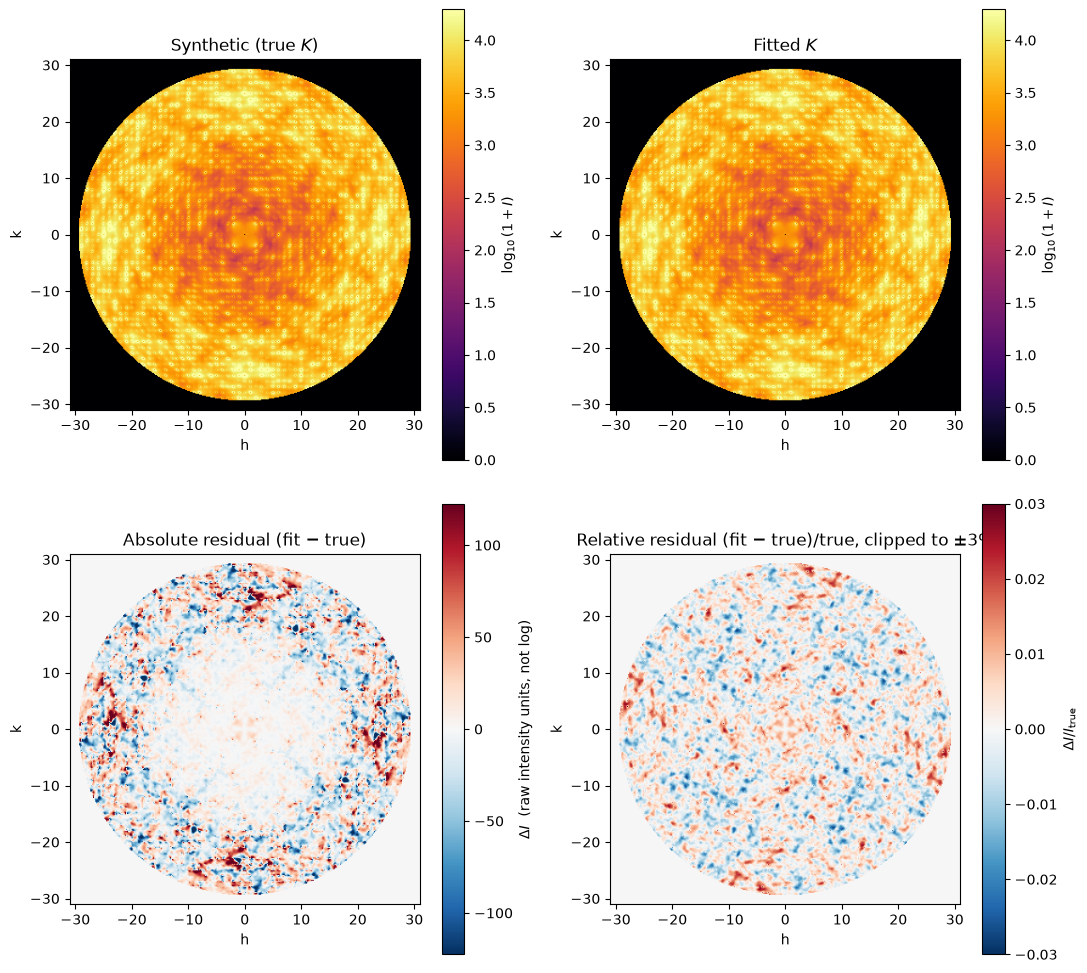

Saved synthetic_7tx0_diffuse_map_true_vs_fit_hk0.png
Absolute residual RMS: 31.75  (I_true RMS: 7242)
Relative residual, unclipped — median |·|: 0.00235, 90th pct |·|: 0.0101


In [42]:
h_pts_cmp, k_pts_cmp, I_true_map, h_max_cmp, k_max_cmp = h_pts_bg0, k_pts_bg0, I_bg0, h_max_bg0, k_max_bg0
I_fit_map = _maps['fit'] if L_PANEL == 0.0 else compute_diffuse_map(K_LAB_FIT, 0.0, G_all=G_PLANE0)[2]

def plot_diffuse_comparison(h_pts, k_pts, I_true, I_fit, h_max, k_max, fname, rel_clip=1.0):
    pos_vals = np.concatenate([I_true[I_true > 0], I_fit[I_fit > 0]])
    vmax = np.percentile(pos_vals, 97) if len(pos_vals) else 1.0
    resid = I_fit - I_true
    rmax = np.percentile(np.abs(resid), 99) if np.any(resid) else 1.0

    # Relative residual: divides out the intensity scale so the (very bright)
    # near-Bragg acoustic halos don't dominate the comparison the way they do
    # in the absolute residual. A small floor avoids dividing by ~0 near the
    # dark Bragg spots themselves.
    floor = 0.02 * vmax
    rel = resid / np.maximum(I_true, floor)
    rel_disp = np.clip(rel, -rel_clip, rel_clip)

    extent = [h_pts[0], h_pts[-1], k_pts[0], k_pts[-1]]
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))

    im0 = axes[0,0].imshow((np.log1p(np.clip(I_true, 0, vmax)) / np.log(10)).T, origin='lower',
                           cmap='inferno', extent=extent, aspect='equal')
    axes[0,0].set_title('Synthetic (true $K$)')
    plt.colorbar(im0, ax=axes[0,0], label=r'$\log_{10}(1+I)$')

    im1 = axes[0,1].imshow((np.log1p(np.clip(I_fit, 0, vmax)) / np.log(10)).T, origin='lower',
                           cmap='inferno', extent=extent, aspect='equal')
    axes[0,1].set_title('Fitted $K$')
    plt.colorbar(im1, ax=axes[0,1], label=r'$\log_{10}(1+I)$')

    im2 = axes[1,0].imshow(resid.T, origin='lower', cmap='RdBu_r',
                           extent=extent, aspect='equal', vmin=-rmax, vmax=rmax)
    axes[1,0].set_title('Absolute residual (fit − true)')
    plt.colorbar(im2, ax=axes[1,0], label='$\\Delta I$  (raw intensity units, not log)')

    im3 = axes[1,1].imshow(rel_disp.T, origin='lower', cmap='RdBu_r',
                           extent=extent, aspect='equal', vmin=-rel_clip, vmax=rel_clip)
    axes[1,1].set_title(f'Relative residual (fit − true)/true, clipped to ±{100*rel_clip:.0f}%')
    plt.colorbar(im3, ax=axes[1,1], label='$\\Delta I / I_{\\rm true}$')

    for ax in axes.flat:
        ax.set_xlabel('h'); ax.set_ylabel('k')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

    rms_resid = np.sqrt(np.mean(resid**2))
    rms_true  = np.sqrt(np.mean(I_true**2))
    print(f"Saved {fname}")
    print(f"Absolute residual RMS: {rms_resid:.4g}  (I_true RMS: {rms_true:.4g})")
    print(f"Relative residual, unclipped — median |·|: {np.median(np.abs(rel)):.3g}, "
          f"90th pct |·|: {np.percentile(np.abs(rel), 90):.3g}")

plot_diffuse_comparison(h_pts_cmp, k_pts_cmp, I_true_map, I_fit_map, h_max_cmp, k_max_cmp,
                        OUT_PREFIX + 'diffuse_map_true_vs_fit_hk0.png', 0.03)

### Model Accuracy by Resolution Shell

The correlation coefficient between model and data, computed separately in
thin shells of resolution and plotted against $1/d$. Within a thin shell an
isotropic term is nearly constant, and a CC is unchanged by adding a constant.
The shell CC therefore measures how well the model reproduces the anisotropic
structure of the scattering, whatever isotropic background either one carries.

The **noise ceiling** is the CC that a perfect model would reach against data with
independent noise $\sigma$: $\sqrt{1-\langle\sigma^2\rangle/\mathrm{var}(I_{\rm obs})}$ in each
shell. Where the model curve sits well below it, the shortfall is model error;
where the ceiling itself is low, the data carry little anisotropic signal. Shells
with fewer than `CC_MIN_VOX` points are left out, and points within the
Bragg-exclusion radius of a reciprocal-lattice point are skipped.

Here the "data" are a synthetic map: the true $K$ on `N_CC_PLANES` planes of
constant $l$ (spread over $0\le l\le l_{\max}$ at non-integer $l$, on a grid of
`CC_P` points per index in $h$ and $k$), with the notebook's noise model added. The
shells run to `D_CC_MIN` (1.5 Å, or `D_MIN_TRANSFORM` if coarser), past the fitted
range (`D_MIN_DIFFUSE`, shaded), so the curve also shows how the fit extrapolates. The cell compares the fit and
the prior with these noisy data, the fit with the noiseless truth (model error
alone), and the noise ceiling. These data are pure one-phonon TDS, so the shape of
the curve reflects the noise model and the fit, not the other contributions
that lower the experimental CC at low resolution.

220272 points on 8 planes of constant l (grid 1/2 in h and k), 30–1.5 Å; synthetic data = true K + the notebook's noise model

      shell (Å)   points  fit/data  prior/data  ceiling  fit/truth
 30.00– 18.37        97       nan         nan      nan        nan
 18.37– 13.24       276     0.802       0.754    0.782     0.9997
 13.24– 10.34       352     0.978       0.950    0.978     0.9999
 10.34–  8.49       452     0.988       0.974    0.987     0.9999
  8.49–  7.20       701     0.948       0.890    0.949     0.9998
  7.20–  6.25      1236     0.969       0.928    0.969     0.9998
  6.25–  5.52      1416     0.986       0.960    0.986     0.9999
  5.52–  4.95      1600     0.997       0.980    0.997     0.9999
  4.95–  4.48      1905     0.998       0.975    0.999     0.9999
  4.48–  4.09      2928     0.998       0.962    0.998     0.9998
  4.09–  3.77      3168     0.998       0.968    0.999     0.9998
  3.77–  3.49      3416     0.999       0.974    0.999     0.9999
  3.49–  3.25 

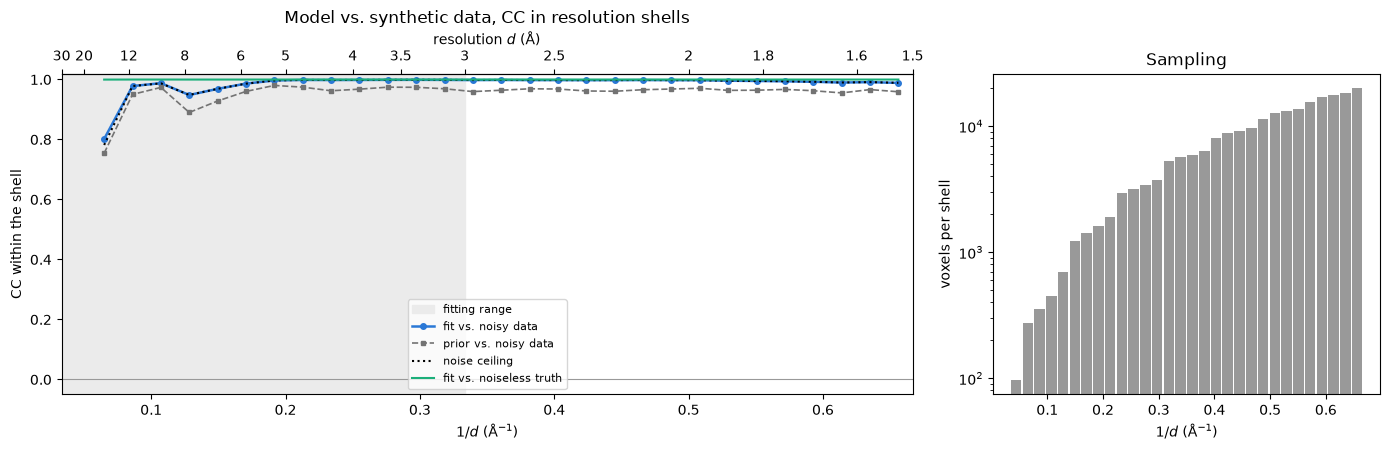

In [43]:
# --- CC between model and data in resolution shells ---------------------------------
N_CC_SHELLS  = 30      # shells equally spaced in 1/d
D_CC_MAX     = 30.0    # Å, low-resolution end
D_CC_MIN     = max(D_MIN_TRANSFORM, 1.5)   # beyond the fitted range (D_MIN_DIFFUSE); the
                                           # 88 Å cell makes finer shells expensive
CC_P         = 2       # grid points per Miller index along h and k
N_CC_PLANES  = 8       # planes of constant l, spread over 0 <= l <= l_max
CC_BRAGG_EXCL = 0.005  # Å⁻¹, points this close to a Bragg position are left out
CC_MIN_VOX   = 200

def _shell_cc(shell, x, y, n_shell, n_min):
    """Pearson CC between x and y within each shell (NaN for shells with < n_min points)."""
    out = np.full(n_shell, np.nan)
    for s in range(n_shell):
        m = shell == s
        if m.sum() >= n_min and np.std(x[m]) > 0 and np.std(y[m]) > 0:
            out[s] = np.corrcoef(x[m], y[m])[0, 1]
    return out

def _noise_ceiling(shell, I_obs, sig, n_shell, n_min):
    """CC a perfect model would reach against data with independent noise sigma:
    sqrt(1 - <sigma^2>/var(I_obs)) in each shell (0 where the noise exceeds the spread)."""
    out = np.full(n_shell, np.nan)
    for s in range(n_shell):
        m = shell == s
        if m.sum() >= n_min:
            v = np.var(I_obs[m])
            out[s] = np.sqrt(max(0.0, 1.0 - np.mean(sig[m]**2)/v)) if v > 0 else np.nan
    return out

def _plot_cc_shells(s_edges, curves, n_vox, fit_range, fname, title):
    """curves: list of (label, values, style dict). x axis 1/d with d on the top axis."""
    sc = 0.5*(s_edges[:-1] + s_edges[1:])
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={'width_ratios': [2.2, 1]})
    if fit_range is not None:
        ax[0].axvspan(1/fit_range[1], 1/fit_range[0], color='0.92', zorder=0, label='fitting range')
    for lab, v, kw in curves:
        ax[0].plot(sc, v, label=lab, **kw)
    ax[0].axhline(0, color='0.6', lw=0.8)
    _lo = np.array([np.nanmin(c[1]) if np.isfinite(c[1]).any() else 0.0 for c in curves])
    ax[0].set_xlim(s_edges[0], s_edges[-1]); ax[0].set_ylim(min(-0.05, _lo.min() - 0.05), 1.02)
    ax[0].set_xlabel(r'$1/d$ (Å$^{-1}$)'); ax[0].set_ylabel('CC within the shell')
    _dt = [d for d in (30, 20, 12, 8, 6, 5, 4, 3.5, 3, 2.5, 2, 1.8, 1.6, 1.5)
           if s_edges[0] <= 1/d <= s_edges[-1]]
    _sec = ax[0].secondary_xaxis('top', functions=(lambda s: 1/np.maximum(s, 1e-6), lambda d: 1/np.maximum(d, 1e-6)))
    _sec.set_xticks(_dt); _sec.set_xticklabels([f'{d:g}' for d in _dt]); _sec.set_xlabel('resolution $d$ (Å)')
    ax[0].set_title(title); ax[0].legend(fontsize=8, loc='lower center')
    ax[1].bar(sc, n_vox, width=0.9*(s_edges[1] - s_edges[0]), color='0.6')
    ax[1].set_yscale('log'); ax[1].set_xlabel(r'$1/d$ (Å$^{-1}$)'); ax[1].set_ylabel('voxels per shell')
    ax[1].set_title('Sampling')
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

_s_edges = np.linspace(1/D_CC_MAX, 1/D_CC_MIN, N_CC_SHELLS + 1)
_hm = int(np.ceil(cell.a/D_CC_MIN)) + 1; _km = int(np.ceil(cell.b/D_CC_MIN)) + 1
_lm = int(np.ceil(cell.c/D_CC_MIN)) + 1
_hp = np.arange(-_hm*CC_P, _hm*CC_P + 1)/CC_P; _kp = np.arange(-_km*CC_P, _km*CC_P + 1)/CC_P
# irrational offset, so no plane sits on an integer l
_l_planes = (np.arange(N_CC_PLANES) + 0.5)*_lm/N_CC_PLANES + 0.0137
_rng_cc = np.random.default_rng(31)
_acc = {k: [] for k in ('shell', 'obs', 'true', 'sig', 'fit', 'prior')}
for _lv in _l_planes:
    _HH, _KK = np.meshgrid(_hp, _kp, indexing='ij')
    _hkl = np.stack([_HH.ravel(), _KK.ravel(), np.full(_HH.size, _lv)], 1)
    _s = np.linalg.norm(_hkl @ B_recip.T, axis=1)/(2*np.pi)
    _bd = np.linalg.norm((_hkl - np.round(_hkl)) @ B_recip.T, axis=1)
    _m = (_s >= _s_edges[0]) & (_s < _s_edges[-1]) & (_bd >= CC_BRAGG_EXCL)
    if not _m.any():
        continue
    _h3 = _hkl[_m]
    _G = G_at_hkl_batch(*_h3.T)
    _I = {lab: diffuse_intensity_batch(K, _h3[:, 0], _h3[:, 1], _h3[:, 2], G_arr=_G)
          for lab, K in (('true', K_LAB_TRUE), ('fit', K_LAB_FIT), ('prior', K_LAB_PRIOR))}
    _sg = NOISE_FLOOR + NOISE_SCALE*np.sqrt(np.clip(_I['true'], 0, None))
    _acc['obs'].append(_I['true'] + _rng_cc.normal(0, _sg)); _acc['sig'].append(_sg)
    for lab in ('true', 'fit', 'prior'): _acc[lab].append(_I[lab])
    _acc['shell'].append(np.clip(np.digitize(_s[_m], _s_edges) - 1, 0, N_CC_SHELLS - 1))
_acc = {k: np.concatenate(v) for k, v in _acc.items()}
_nv = np.bincount(_acc['shell'], minlength=N_CC_SHELLS)
CC_SHELL_FIT   = _shell_cc(_acc['shell'], _acc['fit'],   _acc['obs'], N_CC_SHELLS, CC_MIN_VOX)
CC_SHELL_PRIOR = _shell_cc(_acc['shell'], _acc['prior'], _acc['obs'], N_CC_SHELLS, CC_MIN_VOX)
CC_SHELL_TRUE  = _shell_cc(_acc['shell'], _acc['fit'],   _acc['true'], N_CC_SHELLS, CC_MIN_VOX)
CC_SHELL_MAX   = _noise_ceiling(_acc['shell'], _acc['obs'], _acc['sig'], N_CC_SHELLS, CC_MIN_VOX)

print(f"{len(_acc['obs'])} points on {N_CC_PLANES} planes of constant l (grid 1/{CC_P} in h and k), "
      f"{D_CC_MAX:g}–{D_CC_MIN:g} Å; synthetic data = true K + the notebook's noise model")
print(f"\n{'shell (Å)':>15s} {'points':>8s} {'fit/data':>9s} {'prior/data':>11s} {'ceiling':>8s} {'fit/truth':>10s}")
for s in range(N_CC_SHELLS):
    print(f"{1/_s_edges[s]:6.2f}–{1/_s_edges[s+1]:6.2f}  {_nv[s]:8d} {CC_SHELL_FIT[s]:9.3f} "
          f"{CC_SHELL_PRIOR[s]:11.3f} {CC_SHELL_MAX[s]:8.3f} {CC_SHELL_TRUE[s]:10.4f}")
print("ceiling: sqrt(1 - <σ²>/var(I)), the CC the true model reaches against the noisy data")
print("fit/truth: CC against the noiseless truth, the model error without the noise")

_plot_cc_shells(_s_edges,
                [('fit vs. noisy data', CC_SHELL_FIT, dict(color='#2a78d6', marker='o', ms=4, lw=1.8)),
                 ('prior vs. noisy data', CC_SHELL_PRIOR, dict(color='0.45', ls='--', marker='s', ms=3, lw=1.2)),
                 ('noise ceiling', CC_SHELL_MAX, dict(color='k', ls=':', lw=1.5)),
                 ('fit vs. noiseless truth', CC_SHELL_TRUE, dict(color='#1baf7a', lw=1.5))],
                _nv, (D_MIN_DIFFUSE, D_CC_MAX), OUT_PREFIX + 'cc_resolution_shells.png',
                'Model vs. synthetic data, CC in resolution shells')

## Predicted Atomic Displacement Parameters

`bz_covariance` computes the covariance of all 48 coordinates of a cell,
$\Sigma=\langle uu^{\mathsf T}\rangle=N^{-1}\sum_{\mathbf q}D(\mathbf q)^{-1}$, on an offset
(Monkhorst–Pack) grid of `BZ_NGRID`³ points. Each asymmetric-unit chain's ADPs come
from its own $6\times6$ diagonal block. The other bodies' blocks must be the rotated
copies, $\Sigma_{bb}=S_b\Sigma_{cc}S_b^{\mathsf T}$, which the cell checks.

The acoustic branches make the integrand behave as $1/q^2$ near Γ, so on an offset
grid the error in $\Sigma$ falls only as $1/n$ (about 1% at $n=20$ here). The
convergence table therefore ends with a $1/n$ extrapolation. Comparisons between
two stiffnesses on the same grid (truth vs. fit) are converged much better than the
absolute value. The grid never contains Γ, and eigenvalues below an absolute
floor are dropped. Projecting onto each atom with
$\delta\mathbf r=\mathbf v+\boldsymbol\Omega\times(\mathbf r-\mathbf r_{\rm cm})$
gives the full tensor $U=J_r\Sigma J_r^{\mathsf T}$, the quantity an ANISOU
record holds, and $B=\tfrac{8\pi^2}{3}\mathrm{Tr}\,U$.

True and fitted $U$ are in the same units and are compared directly: isotropic
$B$ per atom and per residue, each of the six tensor components, and the
anisotropy ratio. Convergence in the grid size is printed. The deposited ADPs are
plotted for reference only, since the synthetic $K$ has no connection to the real
crystal.

In [44]:
# Σ, the ADP projection, and the convergence check are evaluated here;
# their definitions sit with the other machinery further up, because the
# posterior propagation needs them too.
Sigma_true = bz_covariance(K_LAB_TRUE)
Sigma_fit  = bz_covariance(K_LAB_FIT)
U_true, U_fit = all_adp_tensors(Sigma_true), all_adp_tensors(Sigma_fit)
B_true, B_fit = isotropic_B(U_true), isotropic_B(U_fit)
ATOM_CHAIN = np.concatenate([[c]*len(CHAINS[c]['pos']) for c in BODY_CHAINS])
b_exp = np.concatenate([CHAINS[c]['b'] for c in BODY_CHAINS])
u_exp = np.concatenate([CHAINS[c]['U'] for c in BODY_CHAINS])
has_aniso = np.concatenate([CHAINS[c]['aniso'] for c in BODY_CHAINS])

_sym = max(np.abs(body_block(Sigma_true, b) - S_of(BODIES[b]['R']) @ body_block(Sigma_true, ASU_BODY[BODIES[b]['chain']])
                  @ S_of(BODIES[b]['R']).T).max()/np.abs(body_block(Sigma_true, b)).max() for b in range(N_BODY))
print(f"symmetry of the covariance: max |Σ_bb - S_b Σ_cc S_b^T| / |Σ_bb| = {_sym:.1e}")
assert _sym < 1e-6, "images of a chain do not have the rotated covariance of the chain"
check_bz_convergence(K_LAB_TRUE)
print()
for c in BODY_CHAINS:
    m = ATOM_CHAIN == c
    print(f"chain {c}: mean predicted B  true K {B_true[m].mean():.3f} Å²,  fit K {B_fit[m].mean():.3f} Å² "
          f"({100*(B_fit[m].mean() - B_true[m].mean())/B_true[m].mean():+.2f}%);  deposited {b_exp[m].mean():.2f} Å²")
print(f"(the deposited B is not comparable on an absolute scale to an arbitrary synthetic K)")

symmetry of the covariance: max |Σ_bb - S_b Σ_cc S_b^T| / |Σ_bb| = 7.1e-15
BZ-grid convergence of the predicted mean B:
  n_grid=  8³ (   512 q-points):  mean B =    0.820 Å²
  n_grid= 12³ (  1728 q-points):  mean B =    0.831 Å²   Δ = +1.25%
  n_grid= 16³ (  4096 q-points):  mean B =    0.836 Å²   Δ = +0.62%
  n_grid= 20³ (  8000 q-points):  mean B =    0.839 Å²   Δ = +0.37%
  n_grid= 26³ ( 17576 q-points):  mean B =    0.842 Å²   Δ = +0.34%
  1/n extrapolation of the last two grids: mean B -> 0.851 Å² (+1.1% from n_grid = 26; ratios between K are much better converged)

chain A: mean predicted B  true K 0.886 Å²,  fit K 0.885 Å² (-0.14%);  deposited 7.51 Å²
chain B: mean predicted B  true K 0.793 Å²,  fit K 0.794 Å² (+0.13%);  deposited 8.06 Å²
(the deposited B is not comparable on an absolute scale to an arbitrary synthetic K)


 comp   mean true    mean fit      bias       r
  U₁₁      0.0094      0.0094     +0.1%  0.9995
  U₂₂      0.0096      0.0096     -0.0%  0.9998
  U₃₃      0.0129      0.0129     -0.0%  0.9996
  U₁₂      0.0010      0.0010     +0.5%  0.9978
  U₁₃     -0.0002     -0.0002     +1.6%  0.9990
  U₂₃     -0.0002     -0.0003     -1.8%  0.9997


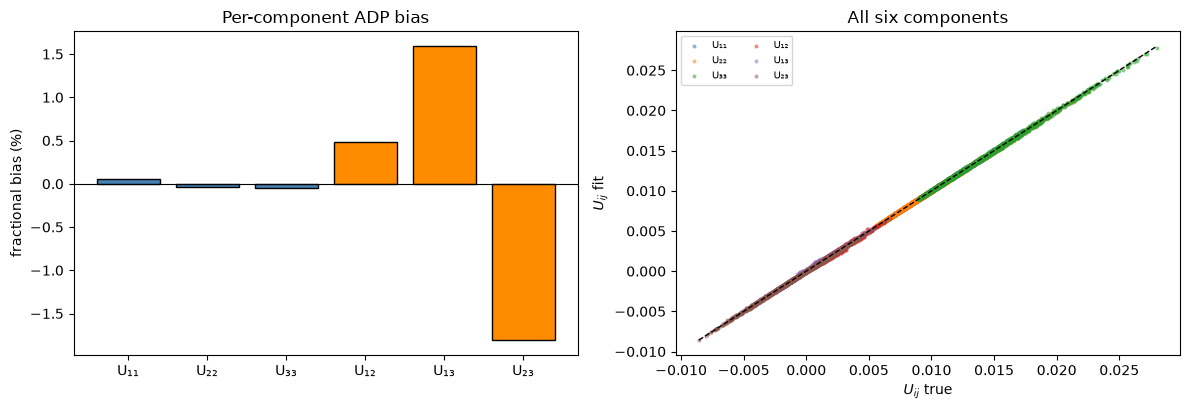


largest bias: U₂₃ at -1.8%
Components carrying an index along a poorly-sampled reciprocal axis are
the ones to expect trouble in; compare against the BZ-coverage panels.


In [45]:
# --- Per-component ADP bias ------------------------------------------------
# The isotropic trace hides direction-dependent error. Each of the six
# independent components of U is compared separately: a component that is
# systematically over- or under-predicted points at a gap in the q-sampling
# along the corresponding axis, not at a failure of the refinement.
_pairs = [(0,0,'U₁₁'), (1,1,'U₂₂'), (2,2,'U₃₃'),
          (0,1,'U₁₂'), (0,2,'U₁₃'), (1,2,'U₂₃')]
print(f"{'comp':>5s} {'mean true':>11s} {'mean fit':>11s} {'bias':>9s} {'r':>7s}")
_bias = {}
for i, j, lab in _pairs:
    t, f = U_true[:, i, j], U_fit[:, i, j]
    b = float(np.mean(f - t)/max(np.mean(np.abs(t)), 1e-30))
    _bias[lab] = b
    print(f"{lab:>5s} {np.mean(t):11.4f} {np.mean(f):11.4f} {b:+9.1%} "
          f"{np.corrcoef(t, f)[0,1]:7.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].bar(list(_bias), [100*v for v in _bias.values()],
          color=['steelblue']*3 + ['darkorange']*3, edgecolor='k')
ax[0].axhline(0, color='k', lw=0.8)
ax[0].set_ylabel('fractional bias (%)'); ax[0].set_title('Per-component ADP bias')
for i, j, lab in _pairs:
    ax[1].scatter(U_true[:, i, j], U_fit[:, i, j], s=4, alpha=0.4, label=lab)
_l = [min(U_true.min(), U_fit.min()), max(U_true.max(), U_fit.max())]
ax[1].plot(_l, _l, 'k--', lw=1); ax[1].set_xlabel(r'$U_{ij}$ true')
ax[1].set_ylabel(r'$U_{ij}$ fit'); ax[1].legend(fontsize=7, ncol=2)
ax[1].set_title('All six components')
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'adp_component_bias.png', dpi=150); plt.show()

_worst = max(_bias, key=lambda k_: abs(_bias[k_]))
print(f"\nlargest bias: {_worst} at {_bias[_worst]:+.1%}")
print("Components carrying an index along a poorly-sampled reciprocal axis are")
print("the ones to expect trouble in; compare against the BZ-coverage panels.")

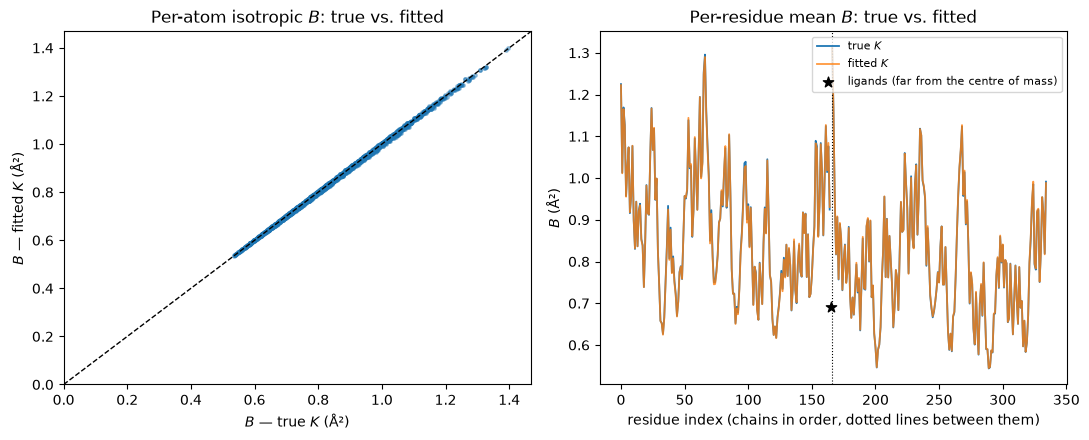

In [46]:
# Per-residue means, compared directly (true vs. fitted, same units)
res_ids = [r for c in BODY_CHAINS for r in CHAINS[c]['res']]
res_index = {}
res_inverse = np.empty(len(res_ids), dtype=int)
for i, key in enumerate(res_ids):
    res_inverse[i] = res_index.setdefault(key, len(res_index))
n_res = len(res_index)
def per_residue_mean(x):
    return np.bincount(res_inverse, weights=x, minlength=n_res)/np.maximum(np.bincount(res_inverse, minlength=n_res), 1)
_res_chain = np.array([k[0] for k in res_index])

B_true_res, B_fit_res = per_residue_mean(B_true), per_residue_mean(B_fit)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ax = axes[0]
ax.scatter(B_true, B_fit, s=6, alpha=0.4)
lim = [0, max(B_true.max(), B_fit.max())*1.05]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('$B$ — true $K$ (Å²)'); ax.set_ylabel('$B$ — fitted $K$ (Å²)')
ax.set_title('Per-atom isotropic $B$: true vs. fitted')

ax = axes[1]
_lig_res = np.array([bool(np.any(np.concatenate([CHAINS[c]['lig'] for c in BODY_CHAINS])[res_inverse == r])) for r in range(n_res)])
_xr = np.arange(n_res)
ax.plot(np.where(_lig_res, np.nan, B_true_res), label='true $K$', lw=1.3)
ax.plot(np.where(_lig_res, np.nan, B_fit_res), label='fitted $K$', lw=1.3, alpha=0.8)
if _lig_res.any():
    ax.scatter(_xr[_lig_res], B_true_res[_lig_res], marker='*', s=60, color='k', zorder=5,
               label='ligands (far from the centre of mass)')
for c in BODY_CHAINS[1:]:
    ax.axvline(np.argmax(_res_chain == c) - 0.5, color='k', lw=0.8, ls=':')
ax.set_xlabel('residue index (chains in order, dotted lines between them)'); ax.set_ylabel('$B$ (Å²)')
ax.set_title('Per-residue mean $B$: true vs. fitted')
ax.legend(fontsize=8)

plt.tight_layout(); plt.savefig(OUT_PREFIX + 'adp_comparison.png', dpi=150); plt.show()

### Anisotropic Comparison

The six independent components of $U$ (true vs. fitted, pooled over atoms) and
each atom's anisotropy ratio (largest / smallest principal displacement). This
checks the shape of the displacement ellipsoids, which the isotropic $B$ does not
test.

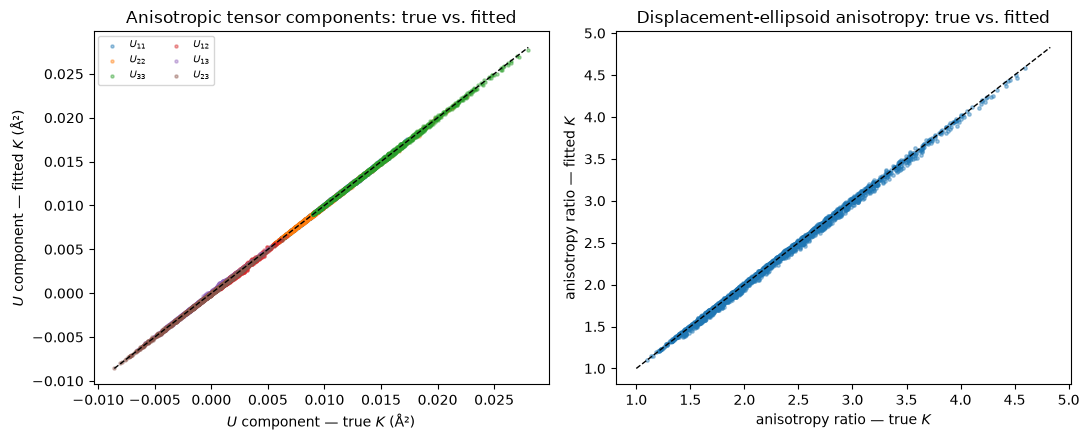

In [47]:
def anisotropy_ratio(U):
    ev = np.linalg.eigvalsh(U)
    return ev[:, -1] / np.clip(ev[:, 0], 1e-12, None)

comp_idx   = [(0,0),(1,1),(2,2),(0,1),(0,2),(1,2)]
comp_names = ['$U_{11}$','$U_{22}$','$U_{33}$','$U_{12}$','$U_{13}$','$U_{23}$']

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

ax = axes[0]
for (i,j), name in zip(comp_idx, comp_names):
    ax.scatter(U_true[:,i,j], U_fit[:,i,j], s=5, alpha=0.4, label=name)
lim = [min(U_true.min(), U_fit.min()), max(U_true.max(), U_fit.max())]
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlabel('$U$ component — true $K$ (Å²)'); ax.set_ylabel('$U$ component — fitted $K$ (Å²)')
ax.set_title('Anisotropic tensor components: true vs. fitted')
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
aniso_true, aniso_fit = anisotropy_ratio(U_true), anisotropy_ratio(U_fit)
ax.scatter(aniso_true, aniso_fit, s=6, alpha=0.4)
lim2 = [1, max(aniso_true.max(), aniso_fit.max())*1.05]
ax.plot(lim2, lim2, 'k--', lw=1)
ax.set_xlabel('anisotropy ratio — true $K$'); ax.set_ylabel('anisotropy ratio — fitted $K$')
ax.set_title('Displacement-ellipsoid anisotropy: true vs. fitted')

plt.tight_layout(); plt.savefig(OUT_PREFIX + 'adp_anisotropic_comparison.png', dpi=150); plt.show()

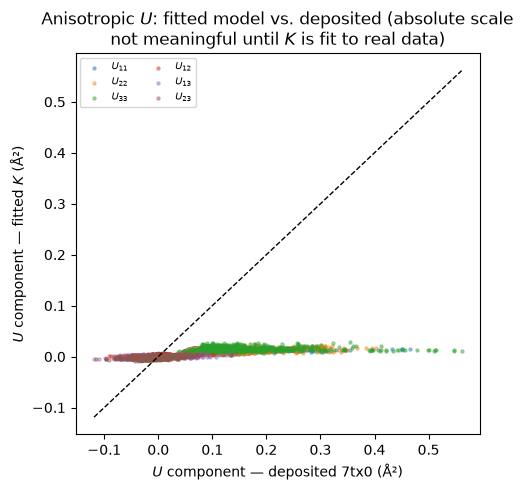

In [48]:
# Deposited ANISOU comparison, when present: this is the comparison that
# becomes meaningful once K is fit to real (not synthetic) diffuse data.
if has_aniso.mean() > 0.5:
    fig, ax = plt.subplots(figsize=(5,5))
    for (i,j), name in zip(comp_idx, comp_names):
        ax.scatter(u_exp[has_aniso,i,j], U_fit[has_aniso,i,j], s=5, alpha=0.4, label=name)
    lim = [min(u_exp[has_aniso].min(), U_fit[has_aniso].min()),
           max(u_exp[has_aniso].max(), U_fit[has_aniso].max())]
    ax.plot(lim, lim, 'k--', lw=1)
    ax.set_xlabel(f'$U$ component — deposited {PDB_ID} (Å²)')
    ax.set_ylabel('$U$ component — fitted $K$ (Å²)')
    ax.set_title('Anisotropic $U$: fitted model vs. deposited (absolute scale\n'
                 'not meaningful until $K$ is fit to real data)')
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout(); plt.savefig(OUT_PREFIX + 'adp_vs_deposited_anisotropic.png', dpi=150); plt.show()
else:
    print(f"Only {has_aniso.mean():.1%} of atoms in {PDB_ID} carry ANISOU records "
          f"(full anisotropic refinement typically needs atomic resolution); "
          f"skipping the deposited anisotropic comparison. Isotropic B-factors "
          f"are compared above regardless.")

## Two-Point Displacement Covariance Between Bodies

$$V_{ij}^{\alpha\beta}=\langle u_{i,\alpha}\,u_{j,\beta}\rangle$$

between atom $i$ of body $a$ in cell 0 and atom $j$ of body $b$ in cell $\mathbf n$ is the
real-space object the diffuse data measure. In the rigid-body model
$V_{ij}=J_i\,\Sigma_{ab}(\mathbf n)\,J_j^{\mathsf T}$, with $J_i$ the lever-arm map of atom
$i$ about its own body's centre of mass and

$$\Sigma_{ab}(\mathbf n)=\langle u_{a,\mathbf 0}u_{b,\mathbf n}^{\mathsf T}\rangle
=\frac1N\sum_{\mathbf q}\bigl[D(\mathbf q)^{+}\bigr]_{ab}\,e^{-i\mathbf q\cdot\mathbf R_{\mathbf n}}$$

(`lattice_covariance`, exact for a `V_NGRID`-periodic crystal; the supercell check
above tests the same Bloch algebra). The cell evaluates it for the Cα atoms of

* each asymmetric-unit chain with itself ($b=a$, $\mathbf n=0$): the ADPs and their
  correlations within one body;
* the representative bond of every orbit (the contacts);
* the nearest pairs of bodies that are **not** in contact.

It reports, for the truth, the fit, the prior and `V_SAMPLES` posterior samples, the
relative error $\|V_{\rm model}-V_{\rm true}\|_F/\|V_{\rm true}\|_F$ over all Cα pairs and
all $3\times3$ entries, and the posterior spread on the same scale (a fit error well
above the spread indicates bias rather than noise). The pair correlation
$\rho_{ij}=\mathrm{tr}\,V_{ij}/\sqrt{\mathrm{tr}\,U_i\,\mathrm{tr}\,U_j}$ is mapped for the
A–A self pair and for the contact with the most atom pairs.

V_ij for the Cα atoms (181 in chain A, 186 in chain B)

                      pair                   kind  mean ρ  prior err  fit err  posterior
                     A0–A0                   self   0.714      22.9%     1.6%       1.8%
                     B0–B0                   self   0.695      32.0%     1.3%       2.0%
           A0–A0(0, 0, -1)              contact 0   0.163      32.1%     2.7%       2.1%
           A0–B0(0, 0, -1)              contact 1   0.321      34.9%     2.1%       2.1%
                     A0–A3              contact 2   0.255      50.4%     1.9%       2.6%
          A0–B2(0, -1, -1)              contact 3   0.207      28.0%     3.5%       2.4%
           A0–B2(0, -1, 0)              contact 4   0.268      30.8%     1.7%       2.4%
           B0–B0(0, 0, -1)              contact 5   0.210      23.4%     2.4%       2.4%
           B0–B1(-1, 0, 0)              contact 6   0.342      22.6%     2.3%       2.6%
                     A0–A1      no contact (43 Å)   0.

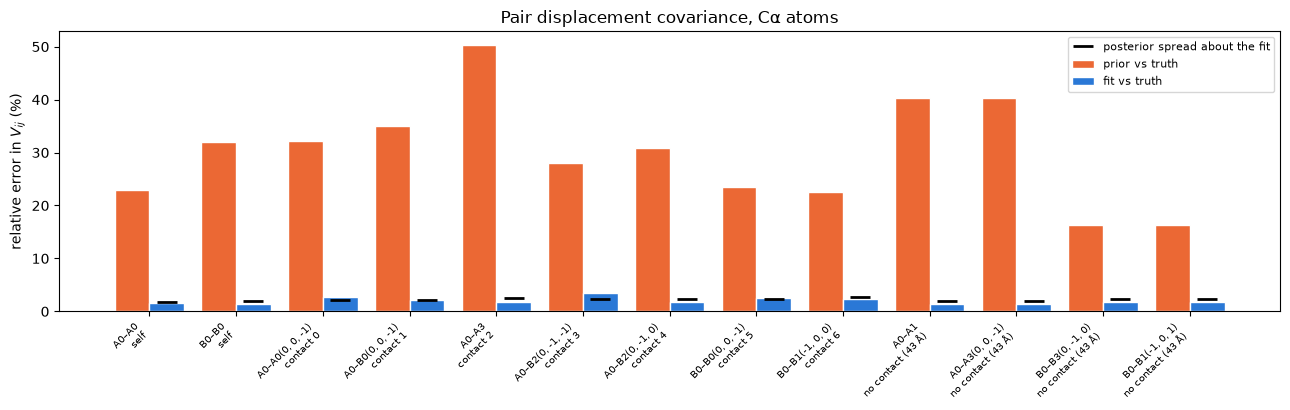

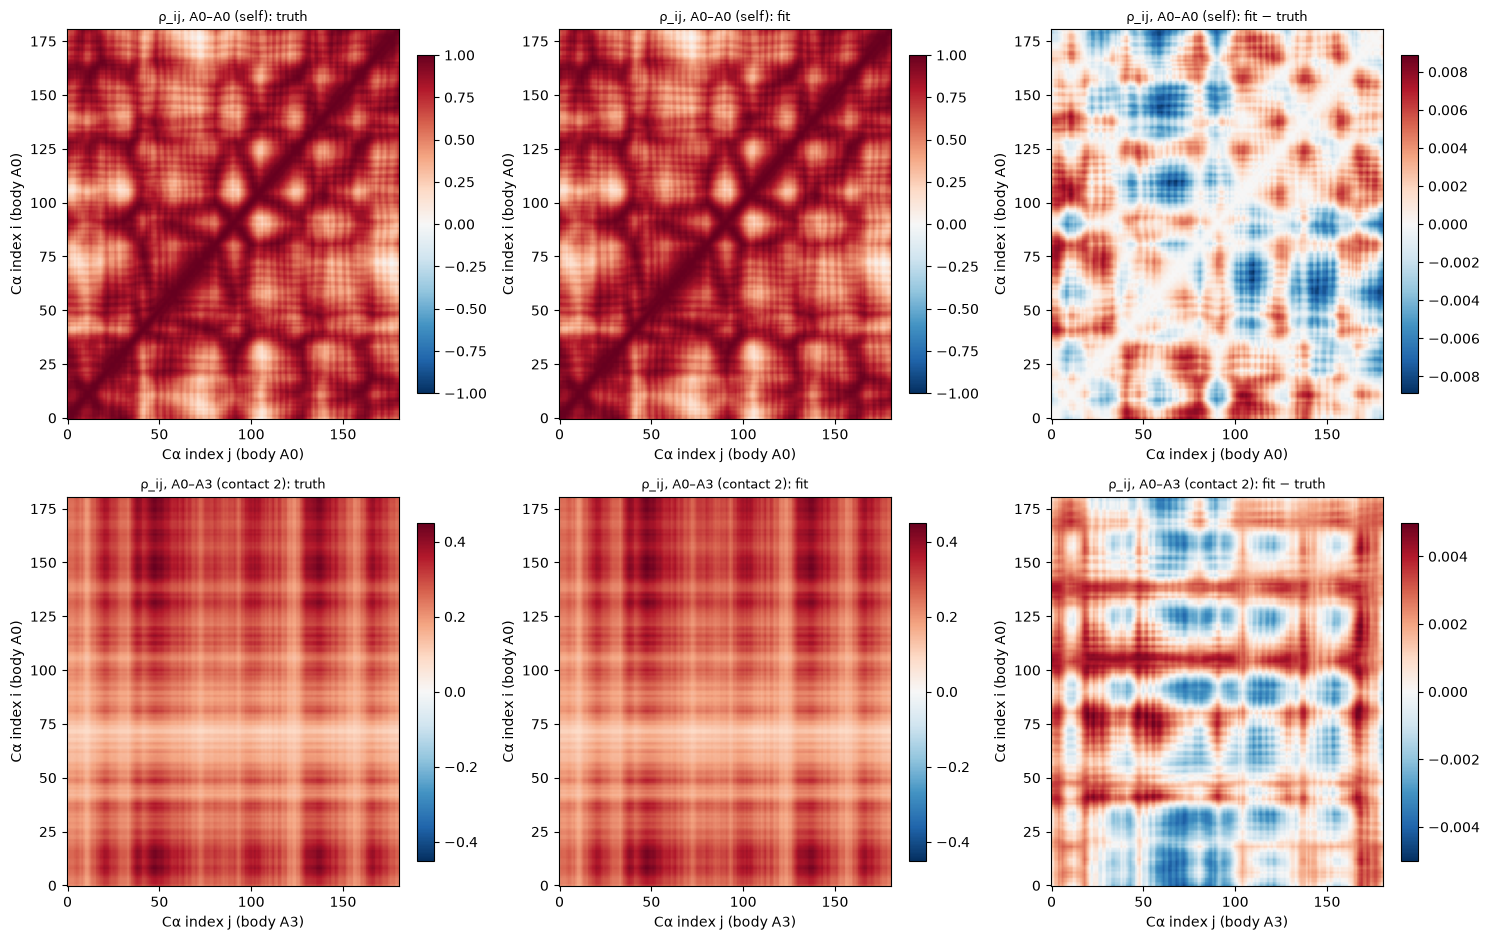

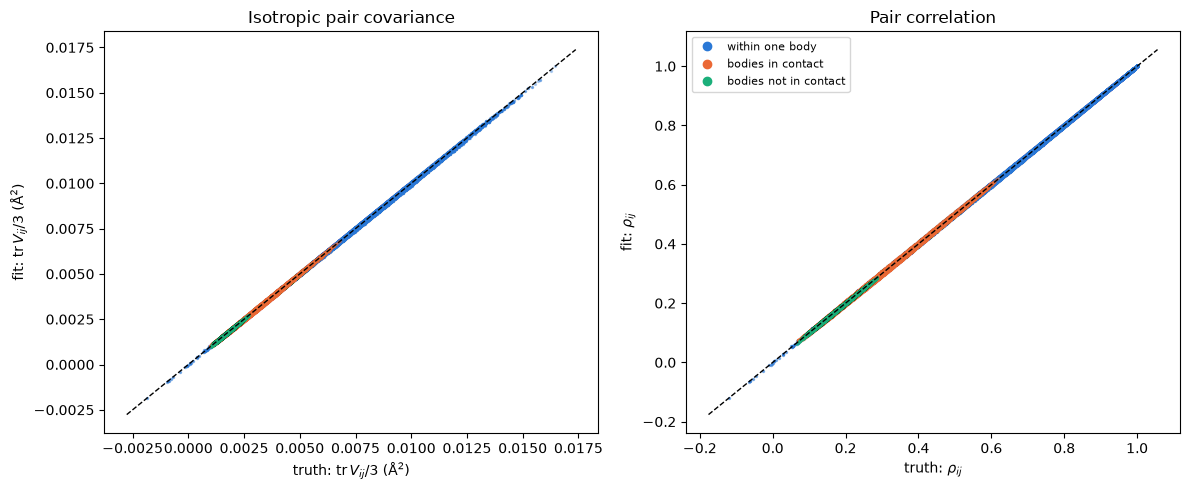

In [49]:
def lattice_covariance(K_lab, pairs, n_grid=16, offset=True, chunk=None):
    """Sigma_ab(n) (6x6) for every (a, b, n) in pairs, on an n_grid^3 offset BZ grid."""
    chunk = chunk or CHUNK_EVAL//4
    g = (np.arange(n_grid) + (0.5 if offset else 0.0))/n_grid
    Ig, Jg, Kg = np.meshgrid(g, g, g, indexing='ij')
    q_all = np.column_stack([Ig.ravel(), Jg.ravel(), Kg.ravel()]) @ B_recip.T
    Dref = dynamical_matrix_batch(q_all[:min(len(q_all), 2000)], unique, K_lab)
    floor = 1e-9*np.linalg.eigvalsh(Dref).max()
    R = np.array([A_orth @ np.array(n, float) for _, _, n in pairs])
    S = np.zeros((len(pairs), 6, 6), complex)
    for s0 in range(0, len(q_all), chunk):
        qb = q_all[s0:s0 + chunk]
        ev, U = np.linalg.eigh(dynamical_matrix_batch(qb, unique, K_lab))
        inv = np.where(ev > floor, 1.0/np.where(ev > floor, ev, 1.0), 0.0)
        ph = np.exp(-1j*(qb @ R.T))                                  # (nq, n_pairs)
        for k, (a, b, _) in enumerate(pairs):
            Ua, Ub = U[:, 6*a:6*a + 6, :], U[:, 6*b:6*b + 6, :]
            S[k] += np.tensordot(Ua*(inv*ph[:, k:k + 1])[:, None, :], Ub.conj(), axes=([0, 2], [0, 2]))
    return np.real(S)/len(q_all)

V_NGRID   = 12      # Brillouin-zone grid for Sigma(n); exact for a V_NGRID-periodic crystal
V_SAMPLES = 8       # posterior samples used for the uncertainty column
N_NONCONTACT = 4    # nearest non-contacting body pairs included for comparison

_CA = {c: np.array([i for i, (nm, lig) in enumerate(zip(CHAINS[c]['names'], CHAINS[c]['lig']))
                    if nm == 'CA' and not lig]) for c in BODY_CHAINS}
def _Jr_CA(b):
    c = BODIES[b]['chain']
    return rigid_jacobians(body_positions(b)[_CA[c]], BODIES[b]['com'])

V_PAIRS, V_KIND = [], []
for c in BODY_CHAINS:
    V_PAIRS.append((ASU_BODY[c], ASU_BODY[c], (0, 0, 0))); V_KIND.append('self')
for o in shell_order:
    V_PAIRS.append((unique[o]['a'], unique[o]['b'], unique[o]['n'])); V_KIND.append(f"contact {o}")
_cand = []
for a in [ASU_BODY[c] for c in BODY_CHAINS]:
    for b in range(N_BODY):
        for n in product(range(-1, 2), repeat=3):
            if (a == b and n == (0, 0, 0)) or bond_key(a, b, n) in BONDS:
                continue
            d = np.linalg.norm(BODIES[b]['com'] + A_orth @ np.array(n, float) - BODIES[a]['com'])
            _cand.append((d, a, b, n))
_seen = set()
for d, a, b, n in sorted(_cand):
    k = bond_key(a, b, n)
    if k in _seen: continue
    _seen.add(k); V_PAIRS.append((a, b, n)); V_KIND.append(f'no contact ({d:.0f} Å)')
    if len(_seen) >= N_NONCONTACT: break

def pair_covariances(K_lab):
    """V[k] (n_CA_a, n_CA_b, 3, 3) for each pair in V_PAIRS."""
    S = lattice_covariance(K_lab, V_PAIRS, V_NGRID)
    return [np.einsum('iab,jdb->ijad', _Jr_CA(a) @ S[k][None], _Jr_CA(b), optimize=True) for k, (a, b, _) in enumerate(V_PAIRS)]

def _self_trace(K_lab):
    """tr U of each Cα, per body (bodies of one chain agree by symmetry)."""
    S = lattice_covariance(K_lab, [(b, b, (0, 0, 0)) for b in range(N_BODY)], V_NGRID)
    return [np.trace(_Jr_CA(b) @ S[b][None] @ np.swapaxes(_Jr_CA(b), 1, 2), axis1=1, axis2=2) for b in range(N_BODY)]

_Vmods = {lab: pair_covariances(K) for lab, K in [('truth', K_LAB_TRUE), ('fit', K_LAB_FIT), ('prior', K_LAB_PRIOR)]}
_Vsamp = [pair_covariances(build_K(theta_to_Lmap(t))[1]) for t in _samples[:V_SAMPLES]]
_trU = {lab: _self_trace(K) for lab, K in [('truth', K_LAB_TRUE), ('fit', K_LAB_FIT)]}

def _relerr(Va, Vb):
    return np.array([np.linalg.norm(x - y)/np.linalg.norm(y) for x, y in zip(Va, Vb)])

def _rho(V, trU):
    return [np.trace(Vk, axis1=2, axis2=3)/np.sqrt(np.outer(trU[a], trU[b])) for Vk, (a, b, _) in zip(V, V_PAIRS)]

_e_fit, _e_prior = _relerr(_Vmods['fit'], _Vmods['truth']), _relerr(_Vmods['prior'], _Vmods['truth'])
_e_post = np.median([_relerr(Vs, _Vmods['fit']) for Vs in _Vsamp], axis=0)
_rho_t, _rho_f = _rho(_Vmods['truth'], _trU['truth']), _rho(_Vmods['fit'], _trU['fit'])
print(f"V_ij for the Cα atoms ({', '.join(f'{len(_CA[c])} in chain {c}' for c in BODY_CHAINS)})")
print(f"\n{'pair':>26s} {'kind':>22s} {'mean ρ':>7s} {'prior err':>10s} {'fit err':>8s} {'posterior':>10s}")
_lbl = []
for k, (a, b, n) in enumerate(V_PAIRS):
    lab = f"{BODIES[a]['chain']}{BODIES[a]['op']}–{BODIES[b]['chain']}{BODIES[b]['op']}{'' if n == (0, 0, 0) else str(n)}"
    _lbl.append(lab)
    print(f"{lab:>26s} {V_KIND[k]:>22s} {_rho_t[k].mean():7.3f} {_e_prior[k]:10.1%} {_e_fit[k]:8.1%} {_e_post[k]:10.1%}")
print("   err = ||V_model - V_true||_F / ||V_true||_F over all Cα pairs; posterior = median spread of the")
print("   posterior samples about the fit on the same scale (fit err well above it means bias)")

_x = np.arange(len(V_PAIRS))
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.bar(_x - 0.2, 100*_e_prior, width=0.4, color='#eb6834', edgecolor='white', label='prior vs truth')
ax.bar(_x + 0.2, 100*_e_fit, width=0.4, color='#2a78d6', edgecolor='white', label='fit vs truth')
ax.plot(_x + 0.2, 100*_e_post, 'k_', ms=14, mew=2, label='posterior spread about the fit')
ax.set_xticks(_x); ax.set_xticklabels([f"{l}\n{k}" for l, k in zip(_lbl, V_KIND)], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('relative error in $V_{ij}$ (%)'); ax.set_title('Pair displacement covariance, Cα atoms'); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'pair_covariance_error.png', dpi=150); plt.show()

_kc = N_CHAIN + int(np.argmax([unique[o]['n_contacts'] for o in shell_order]))
fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for r_, k in enumerate([0, _kc]):
    lim = np.abs(_rho_t[k]).max(); dlim = np.abs(_rho_f[k] - _rho_t[k]).max()
    for c_, (M, t_, lm) in enumerate([(_rho_t[k], 'truth', lim), (_rho_f[k], 'fit', lim),
                                      (_rho_f[k] - _rho_t[k], 'fit − truth', dlim)]):
        im = axes[r_, c_].imshow(M, cmap='RdBu_r', vmin=-lm, vmax=lm, origin='lower', aspect='auto')
        axes[r_, c_].set_title(f"ρ_ij, {_lbl[k]} ({V_KIND[k]}): {t_}", fontsize=9)
        axes[r_, c_].set_xlabel(f'Cα index j (body {_lbl[k].split("–")[1]})')
        axes[r_, c_].set_ylabel(f'Cα index i (body {_lbl[k].split("–")[0]})')
        fig.colorbar(im, ax=axes[r_, c_], fraction=0.046)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'pair_correlation_maps.png', dpi=150); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for k in range(len(V_PAIRS)):
    col = '#2a78d6' if V_KIND[k] == 'self' else ('#eb6834' if V_KIND[k].startswith('contact') else '#1baf7a')
    tt = np.trace(_Vmods['truth'][k], axis1=2, axis2=3).ravel()/3
    tf = np.trace(_Vmods['fit'][k], axis1=2, axis2=3).ravel()/3
    ax[0].scatter(tt, tf, s=2, alpha=0.3, color=col)
    ax[1].scatter(_rho_t[k].ravel(), _rho_f[k].ravel(), s=2, alpha=0.3, color=col)
for a_, lab in zip(ax, [r'$\mathrm{tr}\,V_{ij}/3$ (Å$^2$)', r'$\rho_{ij}$']):
    lo, hi = a_.get_xlim(); a_.plot([lo, hi], [lo, hi], 'k--', lw=1)
    a_.set_xlabel(f'truth: {lab}'); a_.set_ylabel(f'fit: {lab}')
ax[0].set_title('Isotropic pair covariance'); ax[1].set_title('Pair correlation')
ax[1].legend(handles=[Line2D([0], [0], marker='o', ls='', color=c_, label=l_) for c_, l_ in
                      [('#2a78d6', 'within one body'), ('#eb6834', 'bodies in contact'),
                       ('#1baf7a', 'bodies not in contact')]], fontsize=8)
plt.tight_layout(); plt.savefig(OUT_PREFIX + 'pair_covariance_scatter.png', dpi=150); plt.show()

## Phonon Mode Visualization

The lowest modes of the fitted model at `Q_VIZ` are rendered as looping GIFs of the
whole unit cell: all eight bodies, each moving rigidly by its own
$(\boldsymbol\Omega_b,\mathbf v_b)$ about its own centre of mass. With several bodies
per cell an eigenvector at a general $\mathbf q$ is genuinely complex: the bodies move
with different phases. Frame $t$ therefore shows $\mathrm{Re}(e\,e^{-2\pi it/T})$, the
exact motion of the cell over one period, rather than a standing wave. The table gives
each mode's frequency, its rotational share of the kinetic energy, how the energy is
shared between the chains, and the fraction of the eigenvector that is out of phase
(after removing the best global phase).

The surfaces are smooth envelopes of each chain (a Gaussian-blurred atom density,
largest connected component), shaded by chain; the asymmetric-unit bodies are
drawn darker. The animated displacement is scaled so the largest per-atom
displacement equals `AMPLITUDE`.

In [50]:
Q_VIZ      = np.array([0.5, 0.25, 0.0])   # fractional — zone boundary, off-axis
N_MODES_VIZ = 4
AMPLITUDE  = 3.0    # Å — maximum per-atom displacement
N_FRAMES   = 20
GIF_FPS    = 10
SURF_SPACING, SURF_SIGMA = 2.0, 2.2   # Å — envelope grid and blur (coarse: rendering cost)

q_viz  = B_recip @ Q_VIZ
D_viz  = dynamical_matrix(q_viz, unique, K_LAB_FIT)
Dw_viz = Msq_inv @ D_viz @ Msq_inv.T
ev_v, evec_v = np.linalg.eigh(Dw_viz)
freqs_viz = np.sqrt(np.maximum(ev_v, 0))*freq_unit
evecs_lab = Msq_inv.T @ evec_v                       # complex, one column per mode
_phase = np.exp(-1j*np.angle(evecs_lab[np.abs(evecs_lab).argmax(axis=0), np.arange(N_DOF)]))
evecs_lab = evecs_lab*_phase[None, :]
_im_frac = np.linalg.norm(evecs_lab.imag, axis=0)/np.linalg.norm(evecs_lab, axis=0)

print(f"Lowest modes at q = {Q_VIZ}:")
print(f"{'mode':>5s} {'freq (THz)':>11s} {'rot KE %':>9s} " + " ".join(f"{'KE '+c+' %':>8s}" for c in BODY_CHAINS)
      + f" {'out of phase':>13s}")
def _ke(e, b):
    """(rotational, translational) kinetic-energy weight of body b in complex mode e."""
    return (np.real(e[6*b:6*b + 3].conj() @ BODIES[b]['J'] @ e[6*b:6*b + 3]),
            BODIES[b]['m']*np.real(e[6*b + 3:6*b + 6].conj() @ e[6*b + 3:6*b + 6]))
for s in range(max(N_MODES_VIZ, 8)):
    e = evecs_lab[:, s]
    ke_rot = sum(_ke(e, b)[0] for b in range(N_BODY)); ke_tr = sum(_ke(e, b)[1] for b in range(N_BODY))
    ke_ch = {c: sum(sum(_ke(e, b)) for b in range(N_BODY) if BODIES[b]['chain'] == c) for c in BODY_CHAINS}
    tot = ke_rot + ke_tr
    print(f"{s:5d} {freqs_viz[s]:11.5f} {100*ke_rot/tot:9.1f} " + " ".join(f"{100*ke_ch[c]/tot:8.1f}" for c in BODY_CHAINS)
          + f" {_im_frac[s]:13.3f}")

# --- envelope surface of each chain (in its own frame) -----------------------------------
def _chain_surface(c):
    P = CHAINS[c]['pos']
    lo, hi = P.min(0) - 3*SURF_SIGMA, P.max(0) + 3*SURF_SIGMA
    axes_ = [np.arange(l, h + SURF_SPACING, SURF_SPACING) for l, h in zip(lo, hi)]
    G3 = np.stack(np.meshgrid(*axes_, indexing='ij'), -1).reshape(-1, 3)
    dens = np.zeros(len(G3))
    tree = cKDTree(P)
    for i, nb in enumerate(tree.query_ball_point(G3, 3*SURF_SIGMA)):
        if nb:
            dens[i] = np.exp(-((P[nb] - G3[i])**2).sum(1)/(2*SURF_SIGMA**2)).sum()
    dens = dens.reshape([len(a) for a in axes_])
    verts, faces, _, _ = marching_cubes(dens, level=0.35*dens.max())
    verts = verts*SURF_SPACING + lo
    n = len(verts)
    adj = csr_matrix((np.ones(3*len(faces), np.int8),
                      (np.r_[faces[:, 0], faces[:, 1], faces[:, 2]], np.r_[faces[:, 1], faces[:, 2], faces[:, 0]])), shape=(n, n))
    _, labels = sc_connected_components(adj, directed=False)
    keep = np.bincount(labels).argmax()
    remap = np.full(n, -1); idx = np.where(labels == keep)[0]; remap[idx] = np.arange(len(idx))
    faces = remap[faces[(labels[faces] == keep).all(1)]]
    return verts[idx], faces

SURF = {c: _chain_surface(c) for c in BODY_CHAINS}
print("\n" + ", ".join(f"chain {c}: {len(SURF[c][1])} triangles" for c in BODY_CHAINS))

_LIGHT = np.array([0.5, 0.8, 1.0]); _LIGHT /= np.linalg.norm(_LIGHT)
CHAIN_COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#8e5bd0']

def _shade(tri, hex_color, alpha, ambient=0.35):
    n = np.cross(tri[:, 1] - tri[:, 0], tri[:, 2] - tri[:, 0])
    n /= np.maximum(np.linalg.norm(n, axis=1, keepdims=True), 1e-12)
    inten = ambient + (1 - ambient)*np.abs(n @ _LIGHT)
    rgb = np.array([int(hex_color[k:k + 2], 16)/255 for k in (1, 3, 5)])
    return np.column_stack([inten[:, None]*rgb[None, :], np.full(len(tri), alpha)])

def _mode_scale(mode):
    """1 / (largest atom displacement amplitude) for the complex eigenvector."""
    e = evecs_lab[:, mode]
    dmax = max(np.linalg.norm(e[6*b + 3:6*b + 6][None] + np.cross(e[6*b:6*b + 3][None], body_positions(b) - BODIES[b]['com']),
                              axis=1).max() for b in range(N_BODY))
    return 1.0/max(dmax, 1e-12)

def body_vertices(b, mode, amp, phase=0.0):
    """Envelope vertices of body b displaced along Re(e exp(-i phase)), scaled so the
    largest atom displacement amplitude is amp (Å)."""
    B = BODIES[b]; V, _ = SURF[B['chain']]
    Vb = V @ B['R'].T + B['t']
    if mode is None or amp == 0:
        return Vb
    e = np.real(evecs_lab[:, mode]*np.exp(-1j*phase))*_mode_scale(mode)*amp
    om, v = e[6*b:6*b + 3], e[6*b + 3:6*b + 6]
    return Rot.from_rotvec(om).apply(Vb - B['com']) + B['com'] + v

_cell_edges = [(np.array(p), np.array(q)) for p in product((0, 1), repeat=3) for q in product((0, 1), repeat=3)
               if sum(abs(x - y) for x, y in zip(p, q)) == 1 and p < q]

def make_cell_mode_gif(mode, amplitude=AMPLITUDE, n_frames=N_FRAMES, fps=GIF_FPS, fname=None):
    fname = fname or f"{OUT_PREFIX}mode_{mode}_q{'_'.join(f'{x:.2f}' for x in Q_VIZ)}.gif"
    allv = np.vstack([body_vertices(b, None, 0) for b in range(N_BODY)])
    pad = 2.5*amplitude
    lims = [(allv[:, k].min() - pad, allv[:, k].max() + pad) for k in range(3)]
    e = evecs_lab[:, mode]
    ke_rot = sum(np.real(e[6*b:6*b + 3].conj() @ BODIES[b]['J'] @ e[6*b:6*b + 3]) for b in range(N_BODY))
    ke_tr = sum(BODIES[b]['m']*np.real(e[6*b + 3:6*b + 6].conj() @ e[6*b + 3:6*b + 6]) for b in range(N_BODY))
    rot_pct = 100*ke_rot/max(ke_rot + ke_tr, 1e-30)
    images = []
    for fi in range(n_frames):
        ph = 2*np.pi*fi/n_frames
        fig = plt.figure(figsize=(7, 6.5), facecolor='#0d1117')
        ax = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            for b in range(N_BODY):
                Vb = body_vertices(b, mode, amplitude, ph); tri = Vb[SURF[BODIES[b]['chain']][1]]
                col = CHAIN_COLORS[CHAIN_INDEX[BODIES[b]['chain']] % len(CHAIN_COLORS)]
                ax.add_collection3d(Poly3DCollection(tri, facecolors=_shade(tri, col, 0.85 if BODIES[b]['op'] == 0 else 0.45),
                                                     linewidths=0, edgecolor='none'))
            for p, q in _cell_edges:
                seg = np.array([A_orth @ p, A_orth @ q])
                ax.plot(*seg.T, color='0.6', lw=0.6)
            ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
            ax.set_box_aspect([l[1] - l[0] for l in lims])
            ax.set_axis_off(); ax.view_init(elev=22, azim=-58)
            ax.set_title(f'Mode {mode}   {freqs_viz[mode]:.4f} THz   q=({Q_VIZ[0]:g}, {Q_VIZ[1]:g}, {Q_VIZ[2]:g})\n'
                         f'rot {rot_pct:.0f}%  trans {100 - rot_pct:.0f}%   ' +
                         '  '.join(f'{nm}: chain {c}' for nm, c in zip(['blue', 'orange', 'green', 'purple'], BODY_CHAINS)),
                         color='white', fontsize=8.5, pad=3)
            plt.tight_layout(pad=0.2)
            images.append(fig_to_image(fig))
        finally:
            plt.close(fig)
    imageio.mimsave(fname, images, fps=fps, loop=0)
    del images; gc.collect()
    return fname

print(f"\nGenerating unit-cell GIFs of the {N_MODES_VIZ} lowest modes at q = {Q_VIZ} "
      f"(amplitude {AMPLITUDE} Å) ...")
for s in range(N_MODES_VIZ):
    try:
        print(f"   mode {s}: {freqs_viz[s]:.5f} THz -> {make_cell_mode_gif(s)}")
    except Exception as e:
        print(f"   mode {s}: FAILED ({e})")
print(f"Load a GIF with: display(IPImage(filename='{OUT_PREFIX}mode_0_q....gif'))")

Lowest modes at q = [0.5  0.25 0.  ]:
 mode  freq (THz)  rot KE %   KE A %   KE B %  out of phase
    0     0.09998      10.4     32.2     67.8         0.611
    1     0.12073      11.0     67.1     32.9         0.621
    2     0.13129       7.5     48.5     51.5         0.665
    3     0.16517      10.1     54.6     45.4         0.577
    4     0.17523      30.5     52.8     47.2         0.726
    5     0.17834      28.9     33.8     66.2         0.715
    6     0.19404       9.0     59.9     40.1         0.709
    7     0.20833      27.8     63.8     36.2         0.678

chain A: 3408 triangles, chain B: 3804 triangles

Generating unit-cell GIFs of the 4 lowest modes at q = [0.5  0.25 0.  ] (amplitude 3.0 Å) ...
   mode 0: 0.09998 THz -> synthetic_7tx0_mode_0_q0.50_0.25_0.00.gif
   mode 1: 0.12073 THz -> synthetic_7tx0_mode_1_q0.50_0.25_0.00.gif
   mode 2: 0.13129 THz -> synthetic_7tx0_mode_2_q0.50_0.25_0.00.gif
   mode 3: 0.16517 THz -> synthetic_7tx0_mode_3_q0.50_0.25_0.00.gif
Load 

### The Wave in a 3×3×1 Block of Cells

The same eigenvector seen across `SUPER_N1`×`SUPER_N2`×`SUPER_N3` unit cells, i.e.
72 rigid bodies for 3×3×1. A Bloch wave displaces body $b$ in cell $\mathbf n$ by

$$u_{b,\mathbf n}(t)=\mathrm{Re}\bigl[e_b\,e^{\,2\pi i\,\mathbf Q\cdot\mathbf n}\,e^{-2\pi it/T}\bigr],$$

so neighbouring cells repeat the motion of the central one with a phase lag set by
$\mathbf Q$ (`Q_VIZ`). At $\mathbf Q=(\tfrac12,\tfrac14,0)$ the pattern repeats every 2
cells along $a$ and every 4 along $b$. Bodies are coloured by chain (blue A, orange B);
the central cell is drawn opaque and outlined, the others translucent, as a fixed reference.
All bodies go into one depth-sorted surface per frame, so overlaps render correctly.
A full 3×3×3 block is possible but triples the rendering time.

In [51]:
SUPER_N1, SUPER_N2, SUPER_N3 = 3, 3, 1
SUPER_MODES  = [0]          # modes (indices into the table above) to render
SUPER_ALPHA, CENTER_ALPHA = 0.40, 0.95

def make_supercell_gif(mode, amplitude=AMPLITUDE, n_frames=N_FRAMES, fps=GIF_FPS,
                       n1=SUPER_N1, n2=SUPER_N2, n3=SUPER_N3, fname=None, figsize=(10.5, 9.5), dpi=90):
    fname = fname or (f"{OUT_PREFIX}supercell_{n1}x{n2}x{n3}_mode_{mode}_q"
                      f"{'_'.join(f'{x:.2f}' for x in Q_VIZ)}.gif")
    cells = [(i, j, k) for i in range(n1) for j in range(n2) for k in range(n3)]
    centre = (n1//2, n2//2, n3//2)
    rest = {b: body_vertices(b, None, 0) for b in range(N_BODY)}
    allv = np.vstack([rest[b] + A_orth @ np.array(n, float) for n in cells for b in range(N_BODY)])
    pad = 2.0*amplitude
    lims = [(allv[:, k].min() - pad, allv[:, k].max() + pad) for k in range(3)]
    # per-body static data: faces and colours (shading is redone per frame)
    faces = {b: SURF[BODIES[b]['chain']][1] for b in range(N_BODY)}
    cols = {b: CHAIN_COLORS[CHAIN_INDEX[BODIES[b]['chain']] % len(CHAIN_COLORS)] for b in range(N_BODY)}
    block = [np.array(p) for p in product((0, n1), (0, n2), (0, n3))]
    edges = [(p, q) for p in block for q in block if np.sum(np.abs(p - q) > 0) == 1 and tuple(p) < tuple(q)]
    cbox = [np.array(centre) + np.array(p) for p in product((0, 1), repeat=3)]
    cedges = [(p, q) for p in cbox for q in cbox if np.sum(np.abs(p - q) > 0) == 1 and tuple(p) < tuple(q)]
    images = []
    for fi in range(n_frames):
        ph = 2*np.pi*fi/n_frames
        tris, rgba = [], []
        for n in cells:
            Tn = A_orth @ np.array(n, float)
            bloch = 2*np.pi*float(np.dot(Q_VIZ, n))          # e^{i 2 pi Q.n} -> phase lag
            alpha = CENTER_ALPHA if n == centre else SUPER_ALPHA
            for b in range(N_BODY):
                tri = (body_vertices(b, mode, amplitude, ph - bloch) + Tn)[faces[b]]
                tris.append(tri); rgba.append(_shade(tri, cols[b], alpha))
        tris = np.concatenate(tris); rgba = np.concatenate(rgba)
        fig = plt.figure(figsize=figsize, facecolor='#0d1117')
        ax = fig.add_subplot(111, projection='3d', facecolor='#0d1117')
        try:
            ax.add_collection3d(Poly3DCollection(tris, facecolors=rgba, linewidths=0, edgecolor='none'))
            for p, q in edges:
                ax.plot(*np.array([A_orth @ p, A_orth @ q]).T, color='0.55', lw=0.6)
            for p, q in cedges:                                   # the central cell
                ax.plot(*np.array([A_orth @ p, A_orth @ q]).T, color='white', lw=1.0, alpha=0.8)
            ax.set_xlim(*lims[0]); ax.set_ylim(*lims[1]); ax.set_zlim(*lims[2])
            ax.set_box_aspect([l[1] - l[0] for l in lims], zoom=1.12)
            ax.set_axis_off(); ax.view_init(elev=38, azim=-60)
            ax.set_title(f'Mode {mode}   {freqs_viz[mode]:.4f} THz   Q = ({Q_VIZ[0]:g}, {Q_VIZ[1]:g}, {Q_VIZ[2]:g})   '
                         f'{n1}×{n2}×{n3} cells, {len(cells)*N_BODY} bodies\n'
                         + '  '.join(f'{nm}: chain {c}' for nm, c in zip(['blue', 'orange', 'green', 'purple'], BODY_CHAINS))
                         + '   (central cell opaque, outlined)', color='white', fontsize=9, pad=2)
            plt.tight_layout(pad=0.2)
            images.append(fig_to_image(fig, dpi=dpi))
        finally:
            plt.close(fig)
    imageio.mimsave(fname, images, fps=fps, loop=0)
    del images; gc.collect()
    return fname

for s in SUPER_MODES:
    print(f"Rendering the {SUPER_N1}×{SUPER_N2}×{SUPER_N3} block for mode {s} "
          f"({SUPER_N1*SUPER_N2*SUPER_N3*N_BODY} bodies) ...")
    try:
        print("   ->", make_supercell_gif(s))
    except Exception as e:
        print(f"   FAILED ({e})")

Rendering the 3×3×1 block for mode 0 (72 bodies) ...
   -> synthetic_7tx0_supercell_3x3x1_mode_0_q0.50_0.25_0.00.gif


## Summary

| Output | File | Description |
|--------|------|-------------|
| Solvent contrast | `synthetic_7tx0_solvent_contrast.png` | Density and contrast profiles; sharpness of the body partition |
| Contact network | `synthetic_7tx0_contact_network.png` | The eight bodies and every bond, coloured by symmetry orbit |
| Band structure | `synthetic_7tx0_band_structure.png` | 48 branches along Γ–X–M–Γ–Z–R–A–Z (geometric prior) |
| Diffuse maps | `synthetic_7tx0_diffuse_map_hk0.png`, `synthetic_7tx0_diffuse_map_hk05.png` | One-phonon intensity at $l=0$ and $l=0.5$ |
| BZ coverage, sampled points | `synthetic_7tx0_bz_coverage.png`, `synthetic_7tx0_sampled_q_points.png` | Where the synthetic data lie |
| λ scan | `synthetic_7tx0_lambda_scan.png`, `synthetic_7tx0_fit_triangles.png` | Cross-validated $R$ and geodesic distances vs. λ |
| Fit quality | `synthetic_7tx0_refinement_fit_quality.png` | $I_{\rm obs}$ vs $I_{\rm model}$ |
| Sloppiness | `synthetic_7tx0_sloppiness_spectrum.png`, `synthetic_7tx0_null_space_test.png` | Invariant spectrum; dependence on the number of points |
| Posterior | `synthetic_7tx0_posterior_bands.png` | Dispersion with the 95% posterior band |
| Stiff/sloppy directions | `synthetic_7tx0_stiff_sloppy_anatomy.png`, `synthetic_7tx0_direction_block_composition.png`, `synthetic_7tx0_shrinkage_check.png` | Spectra, block composition, shrinkage test |
| Block constraint | `synthetic_7tx0_block_constraint_fit.png` | Data share of the prior variance per orbit and block |
| Designs, elastic tensor | `synthetic_7tx0_design_comparison.png`, `synthetic_7tx0_elastic_constraint.png` | Halo / mid-zone / Meisburger-like designs |
| Convergence movie | `synthetic_7tx0_band_structure_convergence.gif` | Band structure over the iterations |
| Maps | `synthetic_7tx0_map_prior_fit_truth.png`, `synthetic_7tx0_map_ratio_to_truth.png`, `synthetic_7tx0_diffuse_map_true_vs_fit_hk0.png` | Prior / fit / truth, ratios and residuals |
| CC by resolution | `synthetic_7tx0_cc_resolution_shells.png` | Model–data CC in shells of $1/d$ |
| ADPs | `synthetic_7tx0_adp_component_bias.png`, `synthetic_7tx0_adp_comparison.png`, `synthetic_7tx0_adp_anisotropic_comparison.png`, `synthetic_7tx0_adp_vs_deposited_anisotropic.png` | Predicted vs true (and deposited) ADPs |
| Pair covariance | `synthetic_7tx0_pair_covariance_error.png`, `synthetic_7tx0_pair_correlation_maps.png`, `synthetic_7tx0_pair_covariance_scatter.png` | $V_{ij}$ within and between bodies |
| Mode GIFs | `synthetic_7tx0_mode_N_q*.gif` | The lowest modes at `Q_VIZ`, whole unit cell |

**Bodies and symmetry.** Each asymmetric-unit chain (with its ligand) is one rigid
body; the four P4₃ operations give eight per cell. Only the two chains carry atoms,
density and transforms of their own. Everything about the other six follows from
$R_b$, $\mathbf t_b$.

**Density.** The hybrid map (measured amplitudes expanded over the Laue group, model
phases propagated exactly by symmetry) is partitioned voxel by voxel among the
bodies and their lattice images by nearest atom surface. Each chain's contrast
density $(\rho-\rho_{\rm sol})M$ is transformed with a type-2 NUFFT. Checks: NUFFT vs
direct summation; the sum of the eight bodies' transforms vs the FFT of the
whole-cell contrast at integer $hkl$.

**Springs.** Bonds between bodies (atom pairs within 4 Å) fall into orbits under the
space group. Each orbit has one $6\times6$ stiffness, parameterized at a
representative bond touching the asymmetric unit, and appears in $D(\mathbf q)$ once
per member, rotated by $S_g$. The prior and the geodesic regularizer are those of the
P1 notebook, per orbit.

**Dynamics.** $48\times48$ dynamical matrix. Checks: three zero modes at Γ, Laue
symmetry of $I(\mathbf q)$, the Bloch-wave intensity against the exact covariance of
a $3\times3\times3$ periodic supercell, the elastic tensor against the acoustic
branches and against the 4/m form.